  BOT FONDEO — BACKTEST CON MEJORAS INTEGRADAS

Mejoras activas:
  ✓ Filtro anti-consecutivo (mín 2 velas entre entradas)
  ✓ Techo diario de ganancias ($1,200 — protege consistencia)
  ✓ Filtro apertura US (15:30-15:45 excluido)
  ✓ Control intravela del drawdown
  ✓ Contratos dinámicos por DD intradía

Generando datos sintéticos de prueba...
✅ Datos preparados: 17507 velas, 884 señales

Ejecutando backtest...

              INFORME FINAL BACKTEST

------------------------RENDIMIENTO-------------------------
  Balance inicial:    $100,000.00
  Balance final:      $100,158.39
  Rentabilidad:       +0.16%
  Objetivo alcanzado: ❌

--------------------------DRAWDOWN--------------------------
  Equity máxima:      $100,914.03
  Floor actual:       $94,859.18
  Distancia:          $5,299.20
  Bloqueado:          ✅

------------------------OPERACIONES-------------------------
  Total:              818
  Ganadoras:          406
  Win rate:           49.6%

------------------------CONSISTENCIA

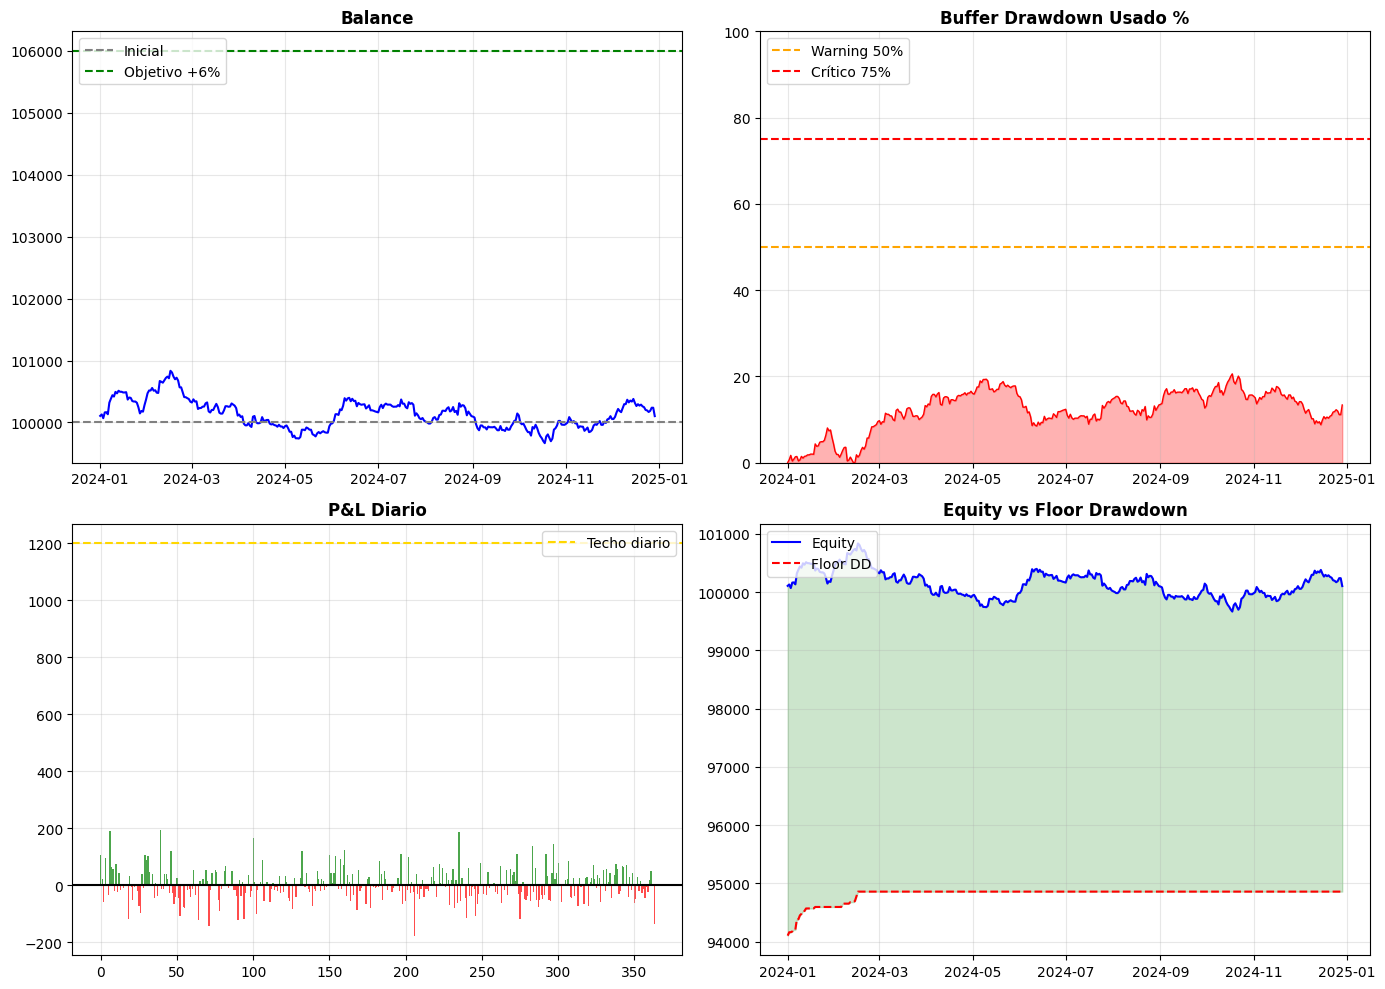

📊 Gráfico guardado: backtest_results.png

✅ Backtest completado


In [ ]:
# ============================================================
# TFM BOT TRADING ALGORÍTMICO
# MÓDULO DE RIESGO COMPLETO + BACKTEST
# GetLeveraged Turbo Trade | CFD US500 M15
# ============================================================
# MEJORAS INTEGRADAS:
# - Filtro anti-consecutivo (no entrar en velas consecutivas)
# - Techo diario de ganancias (protege regla consistencia 20%)
# - Filtro apertura americana (15:30-15:45 excluido)
# - Contratos dinámicos por drawdown intradía
# - Control intravela del drawdown
# ============================================================

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from typing import Dict, List, Tuple, Optional
from collections import defaultdict

# ============================================================
# 1. CONFIGURACIÓN
# ============================================================

CONFIG_RISK = {
    "initial_balance": 100000,

    # Reglas oficiales GetLeveraged
    "daily_loss_limit_pct": 0.03,
    "trailing_drawdown_pct": 0.06,
    "profit_target_pct": 0.06,
    "consistency_rule_pct": 0.20,
    "min_trade_duration_minutes": 2,
    "max_leverage": 30,

    # Reglas internas conservadoras
    "internal_daily_risk_max": 1000,
    "min_signal_score": 50,

    # Riesgo por operación
    "max_risk_per_trade": 150,
    "min_risk_per_trade": 25,

    # Horario operativo (hora local Madrid)
    "trading_start_hour": 9,
    "trading_end_hour": 21,

    # NUEVO: Filtro apertura americana (15:30-15:45 excluido)
    "us_open_start": 15.50,  # 15:30
    "us_open_end": 15.75,    # 15:45
    "filter_us_open": True,

    # NUEVO: Techo diario de ganancias (protege consistencia)
    "daily_profit_ceiling": 1200,
    "daily_profit_ceiling_enabled": True,

    # NUEVO: Filtro anti-consecutivo
    "min_bars_between_entries": 2,
    "anti_consecutive_enabled": True,

    # CFD US500
    "point_value_per_lot": 1,

    # Umbrales de alerta
    "alert_threshold_warning": 0.50,
    "alert_threshold_critical": 0.75,

    # Control de exposición
    "max_positions": 1,
    "max_total_exposure_pct": 0.02,

    # Modo de cuenta
    "account_mode": "EVALUACION"
}

CONFIG_TELEGRAM = {
    "enabled": False,
    "bot_token": "TU_BOT_TOKEN",
    "chat_id": "TU_CHAT_ID",
    "notify_trade_open": True,
    "notify_trade_close": True,
    "notify_daily_summary": True,
    "notify_drawdown_warning": True,
    "notify_drawdown_critical": True,
    "notify_daily_blocked": True,
    "notify_account_blocked": True,
    "notify_profit_target": True,
    "notify_good_day": True,
    "notify_ceiling_reached": True
}


# ============================================================
# 2. NOTIFICADOR TELEGRAM
# ============================================================

class TelegramNotifier:

    def __init__(self, config: dict):
        self.enabled = config.get("enabled", False)
        self.bot_token = config.get("bot_token", "")
        self.chat_id = config.get("chat_id", "")
        self.config = config

    def _send_message(self, message: str, parse_mode: str = "HTML") -> bool:
        if not self.enabled:
            return False

        url = f"[api.telegram.org](https://api.telegram.org/bot{self.bot_token}/sendMessage)"
        payload = {"chat_id": self.chat_id, "text": message, "parse_mode": parse_mode}

        try:
            response = requests.post(url, json=payload, timeout=10)
            return response.status_code == 200
        except:
            return False

    def notify_trade_open(self, info: dict) -> bool:
        if not self.config.get("notify_trade_open"):
            return False
        direction = "🟢 LONG" if info["signal"] == 1 else "🔴 SHORT"
        message = f"<b>📈 OPERACIÓN ABIERTA</b>\n\n{direction}\nPrecio: {info['entry_price']:.2f}\nRiesgo: ${info['risk_usd']:.2f}\nModo: {info['mode']}"
        return self._send_message(message)

    def notify_trade_close(self, info: dict) -> bool:
        if not self.config.get("notify_trade_close"):
            return False
        emoji = "✅" if info["pnl"] >= 0 else "❌"
        message = f"<b>{emoji} CIERRE</b>\n\nP&L: ${info['pnl']:.2f}\nBalance: ${info['balance']:.2f}"
        return self._send_message(message)

    def notify_daily_summary(self, summary: dict) -> bool:
        if not self.config.get("notify_daily_summary"):
            return False
        emoji = "🟢" if summary["pnl_dia"] >= 0 else "🔴"
        message = f"<b>📊 RESUMEN {summary['fecha']}</b>\n\n{emoji} P&L: ${summary['pnl_dia']:.2f}\nBalance: ${summary['balance']:.2f}"
        return self._send_message(message)

    def notify_drawdown_warning(self, info: dict) -> bool:
        if not self.config.get("notify_drawdown_warning"):
            return False
        message = f"<b>⚠️ ALERTA DD</b>\n\nBuffer: {info['buffer_usado_pct']:.1f}%\nModo: {info['modo']}"
        return self._send_message(message)

    def notify_drawdown_critical(self, info: dict) -> bool:
        if not self.config.get("notify_drawdown_critical"):
            return False
        message = f"<b>🚨 DD CRÍTICO</b>\n\nBuffer: {info['buffer_usado_pct']:.1f}%"
        return self._send_message(message)

    def notify_daily_blocked(self, info: dict) -> bool:
        if not self.config.get("notify_daily_blocked"):
            return False
        message = f"<b>🛑 PAUSADO</b>\n\n{info['reason']}"
        return self._send_message(message)

    def notify_account_blocked(self, info: dict) -> bool:
        if not self.config.get("notify_account_blocked"):
            return False
        message = f"<b>⛔ BLOQUEADO</b>\n\n{info['reason']}"
        return self._send_message(message)

    def notify_profit_target(self, info: dict) -> bool:
        if not self.config.get("notify_profit_target"):
            return False
        message = f"<b>🎯 OBJETIVO</b>\n\nRentabilidad: +{info['return_pct']:.2f}%"
        return self._send_message(message)

    def notify_good_day(self, info: dict) -> bool:
        if not self.config.get("notify_good_day"):
            return False
        message = f"<b>🎉 BUEN DÍA</b>\n\nP&L: +${info['pnl']:.2f}"
        return self._send_message(message)

    def notify_ceiling_reached(self, info: dict) -> bool:
        if not self.config.get("notify_ceiling_reached"):
            return False
        message = f"<b>🏆 TECHO DIARIO</b>\n\nP&L día: +${info['pnl_dia']:.2f}\nProtegiendo consistencia"
        return self._send_message(message)


# ============================================================
# 3. TRACKER DE CONSISTENCIA
# ============================================================

class ConsistencyTracker:

    def __init__(self, config: dict, notifier: TelegramNotifier = None):
        self.config = config
        self.notifier = notifier
        self.threshold = config.get("consistency_rule_pct", 0.20)
        self.account_mode = config.get("account_mode", "EVALUACION")
        self.daily_profits = {}
        self.payout_eligible = True

    def update_day(self, fecha, pnl: float) -> None:
        if pnl > 0:
            self.daily_profits[fecha] = pnl

    def get_score(self) -> dict:
        if not self.daily_profits:
            return {"best_day_pnl": 0, "total_profit": 0, "consistency_pct": 0, "is_compliant": True}

        total = sum(self.daily_profits.values())
        if total <= 0:
            return {"best_day_pnl": 0, "total_profit": 0, "consistency_pct": 0, "is_compliant": True}

        best_date = max(self.daily_profits, key=self.daily_profits.get)
        best_pnl = self.daily_profits[best_date]
        pct = (best_pnl / total) * 100

        return {
            "best_day_pnl": round(best_pnl, 2),
            "best_day_date": best_date,
            "total_profit": round(total, 2),
            "consistency_pct": round(pct, 2),
            "is_compliant": pct <= (self.threshold * 100)
        }

    def check(self, current_date) -> dict:
        score = self.get_score()
        if not score["is_compliant"] and self.account_mode == "FONDEADA":
            self.payout_eligible = False
        else:
            self.payout_eligible = True
        return {"score": score, "payout_eligible": self.payout_eligible}

    def get_max_allowed_today(self, current_total_profit: float) -> float:
        """
        Calcula el máximo P&L permitido hoy para no violar consistencia.
        Si el total acumulado es X, el mejor día no puede superar X * 0.20
        """
        if current_total_profit <= 0:
            return float('inf')

        # El mejor día actual
        best_current = max(self.daily_profits.values()) if self.daily_profits else 0

        # Para mantener consistencia: mejor_dia <= total * 0.20
        # Si hoy ganamos Y, el nuevo total sería current_total + Y
        # Y el mejor día sería max(best_current, Y)
        # Queremos: max(best_current, Y) <= (current_total + Y) * 0.20

        # Caso 1: Y <= best_current → best_current <= (current_total + Y) * 0.20
        # Caso 2: Y > best_current → Y <= (current_total + Y) * 0.20
        #         Y <= 0.20 * current_total + 0.20 * Y
        #         0.80 * Y <= 0.20 * current_total
        #         Y <= 0.25 * current_total

        max_if_new_best = current_total_profit * (self.threshold / (1 - self.threshold))
        return max(0, max_if_new_best)

    def get_summary(self) -> dict:
        score = self.get_score()
        return {
            "modo": self.account_mode,
            "score_pct": score["consistency_pct"],
            "limite_pct": self.threshold * 100,
            "cumple": score["is_compliant"],
            "elegible_payout": self.payout_eligible
        }


# ============================================================
# 4. TRACKER ANTI-CONSECUTIVO
# ============================================================

class AntiConsecutiveTracker:
    """
    Evita entradas en velas consecutivas.
    Replica el comportamiento del backtesting que nunca entra
    en dos velas seguidas (evita sobreoperar en momentum).
    """

    def __init__(self, config: dict):
        self.min_bars = config.get("min_bars_between_entries", 2)
        self.enabled = config.get("anti_consecutive_enabled", True)
        self.last_entry_bar_index = None
        self.last_entry_timestamp = None

    def register_entry(self, bar_index: int, timestamp: datetime) -> None:
        self.last_entry_bar_index = bar_index
        self.last_entry_timestamp = timestamp

    def can_enter(self, current_bar_index: int, current_timestamp: datetime) -> Tuple[bool, str]:
        if not self.enabled:
            return True, "Filtro desactivado"

        if self.last_entry_bar_index is None:
            return True, "Primera entrada"

        bars_since_last = current_bar_index - self.last_entry_bar_index

        if bars_since_last < self.min_bars:
            return False, f"Anti-consecutivo: {bars_since_last} velas desde última entrada (mín: {self.min_bars})"

        return True, "OK"

    def reset_day(self) -> None:
        """Resetear al inicio de cada día"""
        self.last_entry_bar_index = None
        self.last_entry_timestamp = None


# ============================================================
# 5. GESTOR DE RIESGO
# ============================================================

class RiskManager:

    def __init__(self, config: dict, telegram_config: dict = None):
        self.config = config

        self.initial_balance = config["initial_balance"]
        self.balance = config["initial_balance"]
        self.equity = config["initial_balance"]
        self.max_equity = config["initial_balance"]

        self.current_day = None
        self.day_start_balance = config["initial_balance"]
        self.daily_pnl = 0
        self.daily_risk_used = 0
        self.daily_trades = []

        self.blocked_today = False
        self.blocked_total = False
        self.block_reason = ""

        # NUEVO: Techo diario alcanzado
        self.ceiling_reached_today = False

        self.profit_target_reached = False
        self.profit_target_notified = False

        self.daily_log = []
        self.trade_log = []
        self.rejection_log = defaultdict(int)

        self.warning_sent_today = False
        self.critical_sent_today = False

        self.notifier = TelegramNotifier(telegram_config) if telegram_config else None
        self.consistency = ConsistencyTracker(config, self.notifier)

        # NUEVO: Tracker anti-consecutivo
        self.anti_consecutive = AntiConsecutiveTracker(config)

        # NUEVO: Índice de barra actual (para anti-consecutivo)
        self.current_bar_index = 0

    def update_day(self, timestamp: datetime) -> None:
        day = timestamp.date()

        if self.current_day != day:
            if self.current_day is not None:
                self._close_day()

            self.current_day = day
            self.day_start_balance = self.balance
            self.daily_pnl = 0
            self.daily_risk_used = 0
            self.daily_trades = []
            self.blocked_today = False
            self.ceiling_reached_today = False
            self.warning_sent_today = False
            self.critical_sent_today = False

            # NUEVO: Reset anti-consecutivo al cambiar de día
            self.anti_consecutive.reset_day()

    def _close_day(self) -> None:
        summary = self.get_daily_summary()
        self.daily_log.append(summary)

        if summary["pnl_dia"] > 0:
            self.consistency.update_day(summary["fecha"], summary["pnl_dia"])

        self.consistency.check(summary["fecha"])

        if self.notifier:
            self.notifier.notify_daily_summary(summary)

    def update_equity(self, equity: float) -> None:
        self.equity = equity
        if equity > self.max_equity:
            self.max_equity = equity
            self._check_profit_target()

    def update_equity_intrabar(self, best_equity: float, worst_equity: float) -> None:
        if best_equity > self.max_equity:
            self.max_equity = best_equity
            self._check_profit_target()
        self.equity = worst_equity

    def _check_profit_target(self) -> None:
        target = self.initial_balance * (1 + self.config["profit_target_pct"])
        if self.max_equity >= target and not self.profit_target_reached:
            self.profit_target_reached = True
            if self.notifier and not self.profit_target_notified:
                self.notifier.notify_profit_target({
                    "equity": self.max_equity,
                    "return_pct": ((self.max_equity / self.initial_balance) - 1) * 100,
                    "locked_floor": self.initial_balance
                })
                self.profit_target_notified = True

    def get_drawdown_floor(self) -> float:
        if self.profit_target_reached:
            return self.initial_balance
        return self.max_equity * (1 - self.config["trailing_drawdown_pct"])

    def get_buffer_ratio(self) -> float:
        floor = self.get_drawdown_floor()
        total_buffer = self.max_equity - floor
        current_buffer = self.equity - floor
        if total_buffer <= 0:
            return 0
        return max(0, min(current_buffer / total_buffer, 1))

    def get_buffer_used_pct(self) -> float:
        return (1 - self.get_buffer_ratio()) * 100

    def check_trailing_drawdown(self) -> Tuple[bool, str]:
        floor = self.get_drawdown_floor()
        if self.equity <= floor:
            self.blocked_total = True
            self.block_reason = "Drawdown trailing alcanzado"
            if self.notifier:
                self.notifier.notify_account_blocked({"reason": self.block_reason, "equity": self.equity, "dd_floor": floor})
            return False, self.block_reason
        return True, "OK"

    def check_daily_loss(self) -> Tuple[bool, str]:
        official_limit = self.day_start_balance * self.config["daily_loss_limit_pct"]
        internal_limit = self.config["internal_daily_risk_max"]

        if self.daily_pnl <= -official_limit:
            self.blocked_today = True
            reason = "Pérdida diaria 3% alcanzada"
            if self.notifier:
                self.notifier.notify_daily_blocked({"reason": reason, "daily_pnl": self.daily_pnl})
            return False, reason

        if self.daily_pnl <= -internal_limit:
            self.blocked_today = True
            reason = "Límite interno diario alcanzado"
            if self.notifier:
                self.notifier.notify_daily_blocked({"reason": reason, "daily_pnl": self.daily_pnl})
            return False, reason

        return True, "OK"

    def check_daily_ceiling(self) -> Tuple[bool, str]:
        """NUEVO: Verifica si se alcanzó el techo diario de ganancias"""
        if not self.config.get("daily_profit_ceiling_enabled", True):
            return True, "OK"

        ceiling = self.config.get("daily_profit_ceiling", 1200)

        if self.daily_pnl >= ceiling:
            self.ceiling_reached_today = True
            reason = f"Techo diario ${ceiling} alcanzado (protección consistencia)"
            if self.notifier:
                self.notifier.notify_ceiling_reached({"pnl_dia": self.daily_pnl, "ceiling": ceiling})
            return False, reason

        return True, "OK"

    def check_trading_hours(self, timestamp: datetime) -> Tuple[bool, str]:
        hour = timestamp.hour
        minute = timestamp.minute
        hora_decimal = hour + minute / 60

        # Horario general
        if hour < self.config["trading_start_hour"] or hour >= self.config["trading_end_hour"]:
            return False, "Fuera de horario"

        # NUEVO: Filtro apertura americana
        if self.config.get("filter_us_open", True):
            us_start = self.config.get("us_open_start", 15.50)
            us_end = self.config.get("us_open_end", 15.75)
            if us_start <= hora_decimal < us_end:
                return False, "Filtro apertura US (15:30-15:45)"

        return True, "OK"

    def check_min_duration(self, open_time: datetime, close_time: datetime) -> Tuple[bool, str]:
        duration = (close_time - open_time).total_seconds() / 60
        if duration < self.config["min_trade_duration_minutes"]:
            return False, f"Duración {duration:.1f}m < {self.config['min_trade_duration_minutes']}m"
        return True, "OK"

    def check_leverage(self, lot_size: float, entry_price: float) -> Tuple[bool, str]:
        if self.equity <= 0:
            return False, "Equity inválida"
        position_value = lot_size * entry_price * self.config["point_value_per_lot"]
        leverage = position_value / self.equity
        if leverage > self.config["max_leverage"]:
            return False, f"Apalancamiento {leverage:.1f}x > {self.config['max_leverage']}x"
        return True, "OK"

    def check_stop_loss(self, stop_loss_points: float) -> Tuple[bool, str]:
        if stop_loss_points is None or stop_loss_points <= 0:
            return False, "Stop loss inválido"
        return True, "OK"

    def check_anti_consecutive(self, bar_index: int, timestamp: datetime) -> Tuple[bool, str]:
        """NUEVO: Verifica filtro anti-consecutivo"""
        return self.anti_consecutive.can_enter(bar_index, timestamp)

    def _check_alerts(self) -> None:
        if not self.notifier:
            return
        buffer_used = self.get_buffer_used_pct()
        info = {"buffer_usado_pct": buffer_used, "equity": self.equity, "dd_floor": self.get_drawdown_floor(), "modo": self.get_risk_mode()}

        if buffer_used >= self.config["alert_threshold_critical"] * 100 and not self.critical_sent_today:
            self.notifier.notify_drawdown_critical(info)
            self.critical_sent_today = True
        elif buffer_used >= self.config["alert_threshold_warning"] * 100 and not self.warning_sent_today:
            self.notifier.notify_drawdown_warning(info)
            self.warning_sent_today = True

    def get_risk_mode(self) -> str:
        buffer = self.get_buffer_ratio()
        if buffer > 0.70:
            return "NORMAL"
        elif buffer > 0.40:
            return "CONSERVADOR"
        elif buffer > 0.20:
            return "SUPERVIVENCIA"
        else:
            return "BLOQUEADO"

    def get_contracts_by_drawdown(self, base_contracts: int = 3) -> int:
        """
        NUEVO: Ajusta contratos según drawdown intradía.
        Más defensivo cuando el drawdown sube.
        """
        buffer = self.get_buffer_ratio()
        dd_from_max = self.max_equity - self.equity

        if buffer <= 0.20:
            return 0
        elif dd_from_max >= 800 or buffer <= 0.30:
            return max(1, base_contracts - 2)
        elif dd_from_max >= 600 or buffer <= 0.50:
            return max(1, base_contracts - 1)
        elif self.daily_pnl >= 800:
            return min(base_contracts + 2, 5)
        elif self.daily_pnl >= 400:
            return min(base_contracts + 1, 4)
        else:
            return base_contracts

    def calculate_risk_smooth(self, signal_score: float) -> float:
        if signal_score < self.config["min_signal_score"]:
            return 0

        buffer = self.get_buffer_ratio()
        if buffer <= 0.20:
            return 0

        max_risk = self.config["max_risk_per_trade"]
        min_risk = self.config["min_risk_per_trade"]

        scale = (buffer - 0.20) / 0.80
        base_risk = min_risk + (max_risk - min_risk) * scale

        if signal_score >= 80:
            multiplier = 1.0
        elif signal_score >= 65:
            multiplier = 0.75
        else:
            multiplier = 0.50

        risk = base_risk * multiplier
        remaining = self._get_daily_budget() - self.daily_risk_used
        risk = min(risk, remaining)

        if risk < self.config["min_risk_per_trade"]:
            return 0

        return round(risk, 2)

    def _get_daily_budget(self) -> float:
        mode = self.get_risk_mode()
        base_budgets = {"NORMAL": 1000, "CONSERVADOR": 600, "SUPERVIVENCIA": 250, "BLOQUEADO": 0}
        budget = base_budgets.get(mode, 0)

        # NUEVO: Reducir presupuesto si nos acercamos al techo
        if self.config.get("daily_profit_ceiling_enabled", True):
            ceiling = self.config.get("daily_profit_ceiling", 1200)
            remaining_to_ceiling = ceiling - self.daily_pnl
            if remaining_to_ceiling < budget:
                budget = max(0, remaining_to_ceiling * 0.5)

        return budget

    def calculate_lot_size(self, risk_usd: float, stop_loss_points: float) -> float:
        if stop_loss_points <= 0 or risk_usd <= 0:
            return 0
        return round(risk_usd / (stop_loss_points * self.config["point_value_per_lot"]), 4)

    def evaluate_trade(self, signal: dict, bar_index: int = None) -> dict:
        timestamp = signal["timestamp"]
        direction = signal["signal"]
        score = signal["signal_score"]
        entry_price = signal["entry_price"]
        sl_points = signal["stop_loss_points"]

        self.update_day(timestamp)

        # Actualizar índice de barra
        if bar_index is not None:
            self.current_bar_index = bar_index

        base = {"allowed": False, "reason": "", "risk_usd": 0, "lot_size": 0, "mode": self.get_risk_mode()}

        if direction == 0:
            base["reason"] = "Sin señal"
            return base

        if self.blocked_total:
            base["reason"] = "Cuenta bloqueada"
            self.rejection_log["Cuenta bloqueada"] += 1
            return base

        if self.blocked_today:
            base["reason"] = "Bloqueado hoy"
            self.rejection_log["Bloqueado hoy"] += 1
            return base

        # NUEVO: Verificar techo diario
        if self.ceiling_reached_today:
            base["reason"] = "Techo diario alcanzado"
            self.rejection_log["Techo diario"] += 1
            return base

        # NUEVO: Verificar filtro anti-consecutivo
        if bar_index is not None:
            ok_anti, reason_anti = self.check_anti_consecutive(bar_index, timestamp)
            if not ok_anti:
                base["reason"] = reason_anti
                self.rejection_log["Anti-consecutivo"] += 1
                return base

        checks = [
            self.check_trading_hours(timestamp),
            self.check_trailing_drawdown(),
            self.check_daily_loss(),
            self.check_daily_ceiling(),
            self.check_stop_loss(sl_points)
        ]

        for ok, reason in checks:
            if not ok:
                base["reason"] = reason
                self.rejection_log[reason] += 1
                return base

        risk_usd = self.calculate_risk_smooth(score)
        if risk_usd <= 0:
            base["reason"] = "Riesgo cero"
            self.rejection_log["Riesgo cero"] += 1
            return base

        lot_size = self.calculate_lot_size(risk_usd, sl_points)
        if lot_size <= 0:
            base["reason"] = "Lote inválido"
            self.rejection_log["Lote inválido"] += 1
            return base

        ok_lev, reason_lev = self.check_leverage(lot_size, entry_price)
        if not ok_lev:
            base["reason"] = reason_lev
            self.rejection_log["Apalancamiento"] += 1
            return base

        self._check_alerts()

        return {"allowed": True, "reason": "Autorizada", "risk_usd": risk_usd, "lot_size": lot_size, "mode": self.get_risk_mode()}

    def confirm_trade_open(self, risk_usd: float, info: dict, bar_index: int = None) -> None:
        self.daily_risk_used += risk_usd
        self.update_equity(self.balance)

        # NUEVO: Registrar entrada para anti-consecutivo
        if bar_index is not None:
            self.anti_consecutive.register_entry(bar_index, info.get("timestamp", datetime.now()))

        if self.notifier:
            self.notifier.notify_trade_open(info)

    def register_trade_result(self, open_time: datetime, close_time: datetime, pnl: float, details: dict) -> dict:
        self.update_day(close_time)

        ok_dur, reason_dur = self.check_min_duration(open_time, close_time)
        duration = (close_time - open_time).total_seconds() / 60

        self.balance += pnl
        self.equity = self.balance
        if self.equity > self.max_equity:
            self.max_equity = self.equity
            self._check_profit_target()

        self.daily_pnl += pnl

        # NUEVO: Verificar techo después de cada trade
        self.check_daily_ceiling()

        record = {
            "open_time": open_time, "close_time": close_time, "duration_min": round(duration, 2),
            "pnl": round(pnl, 2), "balance": round(self.balance, 2), "equity": round(self.equity, 2),
            "max_equity": round(self.max_equity, 2), "dd_floor": round(self.get_drawdown_floor(), 2),
            "mode": self.get_risk_mode(), "duration_valid": ok_dur, **details
        }

        self.trade_log.append(record)
        self.daily_trades.append(record)

        if self.notifier:
            self.notifier.notify_trade_close({"pnl": pnl, "balance": self.balance, "duration_minutes": duration, "mode": self.get_risk_mode()})

        self.check_trailing_drawdown()
        self.check_daily_loss()

        return {"duration_valid": ok_dur, "duration_reason": reason_dur}

    def get_daily_summary(self) -> dict:
        floor = self.get_drawdown_floor()
        total = len(self.daily_trades)
        wins = sum(1 for t in self.daily_trades if t["pnl"] > 0)
        losses = sum(1 for t in self.daily_trades if t["pnl"] < 0)

        total_profit = sum(t["pnl"] for t in self.daily_trades if t["pnl"] > 0)
        total_loss = abs(sum(t["pnl"] for t in self.daily_trades if t["pnl"] < 0))

        win_rate = (wins / total * 100) if total > 0 else 0
        pf = (total_profit / total_loss) if total_loss > 0 else float('inf') if total_profit > 0 else 0

        consistency = self.consistency.get_score()

        return {
            "fecha": self.current_day,
            "balance_inicio": round(self.day_start_balance, 2),
            "balance": round(self.balance, 2),
            "equity": round(self.equity, 2),
            "equity_max": round(self.max_equity, 2),
            "limite_drawdown": round(floor, 2),
            "distancia_drawdown": round(self.equity - floor, 2),
            "buffer_usado_pct": round(self.get_buffer_used_pct(), 2),
            "pnl_dia": round(self.daily_pnl, 2),
            "rentabilidad_dia_pct": round((self.daily_pnl / self.day_start_balance) * 100, 4),
            "riesgo_usado_dia": round(self.daily_risk_used, 2),
            "presupuesto_dia": self._get_daily_budget(),
            "total_operaciones": total,
            "operaciones_ganadoras": wins,
            "operaciones_perdedoras": losses,
            "win_rate": round(win_rate, 2),
            "profit_factor": round(pf, 2) if pf != float('inf') else "∞",
            "modo": self.get_risk_mode(),
            "bloqueado_hoy": self.blocked_today,
            "bloqueado_total": self.blocked_total,
            "techo_alcanzado": self.ceiling_reached_today,
            "consistency_score_pct": consistency["consistency_pct"],
            "payout_elegible": self.consistency.payout_eligible
        }

    def get_final_metrics(self) -> dict:
        if self.current_day is not None:
            self._close_day()

        total = len(self.trade_log)
        wins = sum(1 for t in self.trade_log if t["pnl"] > 0)
        total_pnl = sum(t["pnl"] for t in self.trade_log)

        best_day = max(self.daily_log, key=lambda x: x["pnl_dia"]) if self.daily_log else None
        worst_day = min(self.daily_log, key=lambda x: x["pnl_dia"]) if self.daily_log else None

        # Contar días con techo alcanzado
        ceiling_days = sum(1 for d in self.daily_log if d.get("techo_alcanzado", False))

        return {
            "balance_inicial": self.initial_balance,
            "balance_final": round(self.balance, 2),
            "rentabilidad_pct": round(((self.balance / self.initial_balance) - 1) * 100, 2),
            "equity_maxima": round(self.max_equity, 2),
            "dd_floor_actual": round(self.get_drawdown_floor(), 2),
            "distancia_dd": round(self.balance - self.get_drawdown_floor(), 2),
            "estado": self.get_risk_mode(),
            "bloqueado": self.blocked_total,
            "objetivo_alcanzado": self.profit_target_reached,
            "total_operaciones": total,
            "operaciones_ganadoras": wins,
            "win_rate_global": round((wins / total * 100) if total > 0 else 0, 2),
            "pnl_total": round(total_pnl, 2),
            "dias_operados": len(self.daily_log),
            "dias_techo_alcanzado": ceiling_days,
            "mejor_dia": best_day,
            "peor_dia": worst_day,
            "consistencia": self.consistency.get_summary(),
            "rechazos": dict(self.rejection_log)
        }


# ============================================================
# 6. CONTROL INTRAVELA
# ============================================================

def check_intrabar_risk(row: pd.Series, position: dict, rm: RiskManager) -> Tuple[bool, str]:
    if position is None:
        return True, "Sin posición"

    direction = position["signal"]
    entry = position["entry_price"]
    lot = position["lot_size"]
    pv = rm.config["point_value_per_lot"]

    if direction == 1:
        best_pnl = (row["high"] - entry) * lot * pv
        worst_pnl = (row["low"] - entry) * lot * pv
    else:
        best_pnl = (entry - row["low"]) * lot * pv
        worst_pnl = (entry - row["high"]) * lot * pv

    best_equity = rm.balance + best_pnl
    worst_equity = rm.balance + worst_pnl

    rm.update_equity_intrabar(best_equity, worst_equity)

    floor = rm.get_drawdown_floor()
    if worst_equity <= floor:
        rm.blocked_total = True
        rm.block_reason = "Drawdown intravela"
        if rm.notifier:
            rm.notifier.notify_account_blocked({"reason": "DD intravela", "equity": worst_equity, "dd_floor": floor})
        return False, f"DD intravela: {worst_equity:.2f} <= {floor:.2f}"

    rm._check_alerts()
    return True, "OK"


# ============================================================
# 7. BACKTEST
# ============================================================

def run_backtest(df: pd.DataFrame, config_risk: dict, config_telegram: dict = None) -> dict:
    rm = RiskManager(config_risk, config_telegram)

    position = None
    results = []

    for bar_index, (i, row) in enumerate(df.iterrows()):
        ts = row["time"]
        rm.update_day(ts)

        # Control intravela si hay posición abierta
        if position is not None:
            ok, reason = check_intrabar_risk(row, position, rm)
            if not ok:
                direction = position["signal"]
                entry = position["entry_price"]
                lot = position["lot_size"]
                exit_price = row["low"] if direction == 1 else row["high"]
                pnl = ((exit_price - entry) if direction == 1 else (entry - exit_price)) * lot * config_risk["point_value_per_lot"]
                rm.register_trade_result(position["open_time"], ts, pnl, {"exit_reason": "DD_INTRAVELA", "exit_price": exit_price})
                results.append({"time": ts, "bar_index": bar_index, "event": "BLOQUEO_INTRAVELA", "reason": reason})
                position = None
                break

        # Evaluar nueva entrada si no hay posición
        if position is None:
            signal = {
                "timestamp": ts,
                "signal": row["signal"],
                "signal_score": row["signal_score"],
                "entry_price": row["close"],
                "stop_loss_points": row["stop_loss_points"]
            }

            # NUEVO: Pasar bar_index para filtro anti-consecutivo
            decision = rm.evaluate_trade(signal, bar_index=bar_index)

            results.append({
                "time": ts,
                "bar_index": bar_index,
                "event": "EVAL",
                "signal": row["signal"],
                "score": row["signal_score"],
                "allowed": decision["allowed"],
                "reason": decision["reason"],
                "risk_usd": decision["risk_usd"],
                "lot": decision["lot_size"],
                "mode": decision["mode"]
            })

            if decision["allowed"]:
                position = {
                    "open_time": ts,
                    "signal": row["signal"],
                    "entry_price": row["close"],
                    "lot_size": decision["lot_size"],
                    "risk_usd": decision["risk_usd"],
                    "stop_loss_points": row["stop_loss_points"],
                    "bar_index": bar_index
                }

                # NUEVO: Pasar bar_index a confirm
                rm.confirm_trade_open(
                    decision["risk_usd"],
                    {
                        "timestamp": ts,
                        "signal": row["signal"],
                        "entry_price": row["close"],
                        "risk_usd": decision["risk_usd"],
                        "lot_size": decision["lot_size"],
                        "mode": decision["mode"]
                    },
                    bar_index=bar_index
                )

        # Cerrar posición al final de la barra (simplificado para backtest)
        elif position is not None:
            direction = position["signal"]
            entry = position["entry_price"]
            exit_price = row["close"]
            lot = position["lot_size"]
            pnl = ((exit_price - entry) if direction == 1 else (entry - exit_price)) * lot * config_risk["point_value_per_lot"]

            rm.register_trade_result(position["open_time"], ts, pnl, {
                "entry_price": entry,
                "exit_price": exit_price,
                "direction": direction,
                "exit_reason": "CIERRE_NORMAL"
            })

            results.append({
                "time": ts,
                "bar_index": bar_index,
                "event": "CIERRE",
                "pnl": round(pnl, 2),
                "balance": rm.balance,
                "mode": rm.get_risk_mode()
            })
            position = None

            if rm.blocked_total or rm.blocked_today:
                results.append({
                    "time": ts,
                    "bar_index": bar_index,
                    "event": "PAUSADO",
                    "reason": "DD" if rm.blocked_total else "Diario"
                })

    return {
        "risk_manager": rm,
        "results": pd.DataFrame(results),
        "daily": pd.DataFrame(rm.daily_log),
        "trades": pd.DataFrame(rm.trade_log),
        "metrics": rm.get_final_metrics()
    }


# ============================================================
# 8. PREPARACIÓN DE DATOS
# ============================================================

def prepare_data_with_signals(df: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    """Añade señales simuladas para probar el módulo de riesgo."""
    df = df.copy()
    np.random.seed(seed)

    n = len(df)

    signal_mask = np.random.random(n) < 0.05
    signals = np.zeros(n, dtype=int)
    signals[signal_mask] = np.random.choice([1, -1], size=signal_mask.sum())
    df["signal"] = signals

    scores = np.zeros(n)
    scores[signal_mask] = np.random.randint(50, 100, size=signal_mask.sum())
    df["signal_score"] = scores

    df["atr"] = (df["high"] - df["low"]).rolling(14).mean()
    df["stop_loss_points"] = df["atr"] * 1.5
    df["stop_loss_points"] = df["stop_loss_points"].fillna(5)

    df = df.dropna().reset_index(drop=True)

    print(f"✅ Datos preparados: {len(df)} velas, {(df['signal'] != 0).sum()} señales")
    return df


# ============================================================
# 9. VERIFICACIÓN DE CUMPLIMIENTO
# ============================================================

def verify_compliance(metrics: dict, df_daily: pd.DataFrame, df_trades: pd.DataFrame, config: dict) -> dict:
    results = {"reglas": [], "cumple_todas": True}

    # Pérdida diaria
    if not df_daily.empty:
        worst = df_daily["rentabilidad_dia_pct"].min()
        limit = -config["daily_loss_limit_pct"] * 100
        cumple = worst >= limit
        results["reglas"].append({
            "regla": "Pérdida diaria 3%",
            "limite": f"{limit:.2f}%",
            "valor": f"{worst:.2f}%",
            "cumple": cumple
        })
        if not cumple:
            results["cumple_todas"] = False

    # Drawdown
    cumple_dd = not metrics["bloqueado"]
    results["reglas"].append({
        "regla": "Drawdown 6%",
        "limite": "No tocar floor",
        "valor": "OK" if cumple_dd else "VIOLADO",
        "cumple": cumple_dd
    })
    if not cumple_dd:
        results["cumple_todas"] = False

    # Objetivo
    results["reglas"].append({
        "regla": "Objetivo 6%",
        "limite": "6%",
        "valor": f"{metrics['rentabilidad_pct']:.2f}%",
        "cumple": metrics["objetivo_alcanzado"]
    })

    # Consistencia
    c = metrics["consistencia"]
    results["reglas"].append({
        "regla": "Consistencia 20%",
        "limite": f"{c['limite_pct']:.0f}%",
        "valor": f"{c['score_pct']:.1f}%",
        "cumple": c["cumple"],
        "nota": "Informativo"
    })

    # Duración
    if not df_trades.empty and "duration_valid" in df_trades.columns:
        invalidos = (~df_trades["duration_valid"]).sum()
        cumple_dur = invalidos == 0
        results["reglas"].append({
            "regla": "Duración 2 min",
            "limite": "2 min",
            "valor": f"{invalidos} inválidas",
            "cumple": cumple_dur
        })
        if not cumple_dur:
            results["cumple_todas"] = False

    # NUEVO: Días con techo alcanzado
    results["reglas"].append({
        "regla": "Protección consistencia (techo)",
        "limite": "Informativo",
        "valor": f"{metrics.get('dias_techo_alcanzado', 0)} días",
        "cumple": True,
        "nota": "Días donde se detuvo para proteger la regla 20%"
    })

    return results


# ============================================================
# 10. VISUALIZACIÓN
# ============================================================

def print_report(metrics: dict) -> None:
    print("\n" + "=" * 60)
    print("              INFORME FINAL BACKTEST")
    print("=" * 60)

    print(f"\n{'RENDIMIENTO':-^60}")
    print(f"  Balance inicial:    ${metrics['balance_inicial']:,.2f}")
    print(f"  Balance final:      ${metrics['balance_final']:,.2f}")
    print(f"  Rentabilidad:       {metrics['rentabilidad_pct']:+.2f}%")
    print(f"  Objetivo alcanzado: {'✅' if metrics['objetivo_alcanzado'] else '❌'}")

    print(f"\n{'DRAWDOWN':-^60}")
    print(f"  Equity máxima:      ${metrics['equity_maxima']:,.2f}")
    print(f"  Floor actual:       ${metrics['dd_floor_actual']:,.2f}")
    print(f"  Distancia:          ${metrics['distancia_dd']:,.2f}")
    print(f"  Bloqueado:          {'⛔' if metrics['bloqueado'] else '✅'}")

    print(f"\n{'OPERACIONES':-^60}")
    print(f"  Total:              {metrics['total_operaciones']}")
    print(f"  Ganadoras:          {metrics['operaciones_ganadoras']}")
    print(f"  Win rate:           {metrics['win_rate_global']:.1f}%")

    c = metrics["consistencia"]
    print(f"\n{'CONSISTENCIA':-^60}")
    print(f"  Score:              {c['score_pct']:.1f}% (máx {c['limite_pct']:.0f}%)")
    print(f"  Cumple:             {'✅' if c['cumple'] else '⚠️'}")
    print(f"  Días con techo:     {metrics.get('dias_techo_alcanzado', 0)}")

    print(f"\n{'RECHAZOS':-^60}")
    for reason, count in metrics.get("rechazos", {}).items():
        print(f"  {reason}: {count}")

    print("=" * 60)


def print_compliance(compliance: dict) -> None:
    print("\n" + "=" * 60)
    print("           VERIFICACIÓN DE REGLAS")
    print("=" * 60)

    for r in compliance["reglas"]:
        emoji = "✅" if r["cumple"] else "❌"
        print(f"\n{emoji} {r['regla']}")
        print(f"   Límite: {r['limite']} | Resultado: {r['valor']}")
        if "nota" in r:
            print(f"   Nota: {r['nota']}")

    print("\n" + "-" * 60)
    print(f"   {'🎉 TODAS LAS REGLAS OK' if compliance['cumple_todas'] else '❌ HAY VIOLACIONES'}")
    print("=" * 60)


def plot_results(df_daily: pd.DataFrame, config: dict) -> None:
    if df_daily.empty:
        print("Sin datos para graficar")
        return

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Balance
    axes[0, 0].plot(df_daily["fecha"], df_daily["balance"], 'b-', linewidth=1.5)
    axes[0, 0].axhline(config["initial_balance"], color='gray', linestyle='--', label='Inicial')
    axes[0, 0].axhline(config["initial_balance"] * 1.06, color='green', linestyle='--', label='Objetivo +6%')
    axes[0, 0].set_title("Balance", fontsize=12, fontweight='bold')
    axes[0, 0].legend(loc='upper left')
    axes[0, 0].grid(True, alpha=0.3)

    # Buffer usado
    axes[0, 1].fill_between(df_daily["fecha"], df_daily["buffer_usado_pct"], alpha=0.3, color='red')
    axes[0, 1].plot(df_daily["fecha"], df_daily["buffer_usado_pct"], 'r-', linewidth=1)
    axes[0, 1].axhline(50, color='orange', linestyle='--', label='Warning 50%')
    axes[0, 1].axhline(75, color='red', linestyle='--', label='Crítico 75%')
    axes[0, 1].set_title("Buffer Drawdown Usado %", fontsize=12, fontweight='bold')
    axes[0, 1].set_ylim(0, 100)
    axes[0, 1].legend(loc='upper left')
    axes[0, 1].grid(True, alpha=0.3)

    # P&L diario con marcadores de techo
    colors = ['green' if x >= 0 else 'red' for x in df_daily["pnl_dia"]]
    bars = axes[1, 0].bar(range(len(df_daily)), df_daily["pnl_dia"], color=colors, alpha=0.7)

    # Marcar días con techo alcanzado
    if "techo_alcanzado" in df_daily.columns:
        for idx, (_, row) in enumerate(df_daily.iterrows()):
            if row.get("techo_alcanzado", False):
                bars[idx].set_edgecolor('gold')
                bars[idx].set_linewidth(2)

    axes[1, 0].axhline(0, color='black')
    axes[1, 0].axhline(config.get("daily_profit_ceiling", 1200), color='gold', linestyle='--', label='Techo diario')
    axes[1, 0].set_title("P&L Diario", fontsize=12, fontweight='bold')
    axes[1, 0].legend(loc='upper right')
    axes[1, 0].grid(True, alpha=0.3)

    # Equity vs Floor
    axes[1, 1].plot(df_daily["fecha"], df_daily["equity"], 'b-', label='Equity', linewidth=1.5)
    axes[1, 1].plot(df_daily["fecha"], df_daily["limite_drawdown"], 'r--', label='Floor DD', linewidth=1.5)
    axes[1, 1].fill_between(df_daily["fecha"], df_daily["limite_drawdown"], df_daily["equity"], alpha=0.2, color='green')
    axes[1, 1].set_title("Equity vs Floor Drawdown", fontsize=12, fontweight='bold')
    axes[1, 1].legend(loc='upper left')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("backtest_results.png", dpi=150)
    plt.show()
    print("📊 Gráfico guardado: backtest_results.png")


# ============================================================
# 11. EJECUCIÓN
# ============================================================

if __name__ == "__main__":
    print("=" * 60)
    print("  BOT FONDEO — BACKTEST CON MEJORAS INTEGRADAS")
    print("=" * 60)
    print("\nMejoras activas:")
    print("  ✓ Filtro anti-consecutivo (mín 2 velas entre entradas)")
    print("  ✓ Techo diario de ganancias ($1,200 — protege consistencia)")
    print("  ✓ Filtro apertura US (15:30-15:45 excluido)")
    print("  ✓ Control intravela del drawdown")
    print("  ✓ Contratos dinámicos por DD intradía")
    print()

    # Cargar datos (ajusta la ruta)
    # df_raw = pd.read_parquet("us500_m15_2020_2026.parquet")

    # Para prueba rápida, generar datos sintéticos
    print("Generando datos sintéticos de prueba...")
    dates = pd.date_range("2024-01-01", "2024-12-31", freq="15min")

    # Filtrar solo horario operativo
    dates = dates[(dates.hour >= 9) & (dates.hour < 21)]

    df_raw = pd.DataFrame({
        "time": dates,
        "open": 4500 + np.random.randn(len(dates)).cumsum() * 0.1,
    })
    df_raw["high"] = df_raw["open"] + np.abs(np.random.randn(len(dates))) * 3
    df_raw["low"] = df_raw["open"] - np.abs(np.random.randn(len(dates))) * 3
    df_raw["close"] = df_raw["open"] + np.random.randn(len(dates)) * 1.5

    # Preparar con señales
    df = prepare_data_with_signals(df_raw, seed=42)

    # Ejecutar backtest
    print("\nEjecutando backtest...")
    result = run_backtest(df, CONFIG_RISK, CONFIG_TELEGRAM)

    # Resultados
    metrics = result["metrics"]
    df_daily = result["daily"]
    df_trades = result["trades"]

    # Informes
    print_report(metrics)

    compliance = verify_compliance(metrics, df_daily, df_trades, CONFIG_RISK)
    print_compliance(compliance)

    # Gráficos
    plot_results(df_daily, CONFIG_RISK)

    print("\n✅ Backtest completado")


  BOT FONDEO — BACKTEST CON MEJORAS INTEGRADAS

Mejoras activas:
  ✓ Filtro anti-consecutivo (mín 2 velas entre entradas)
  ✓ Techo diario de ganancias ($1,200 — protege consistencia)
  ✓ Filtro apertura US (15:30-15:45 excluido)
  ✓ Control intravela del drawdown
  ✓ Contratos dinámicos por DD intradía
  ✓ Límite máximo operaciones por día (5)
  ✓ Solo 1 posición simultánea

Cargando datos desde CSV...
✅ Datos cargados: 49967 velas
✅ Datos preparados: 49954 velas, 2477 señales

Ejecutando backtest...
✅ Datos preparados: 49954 velas, 2477 señales

Ejecutando backtest...

              INFORME FINAL BACKTEST

------------------------RENDIMIENTO-------------------------
  Balance inicial:    $100,000.00
  Balance final:      $98,922.60
  Rentabilidad:       -1.08%
  Objetivo alcanzado: ❌

--------------------------DRAWDOWN--------------------------
  Equity máxima:      $100,389.02
  Floor actual:       $94,365.68
  Distancia:          $4,556.91
  Bloqueado:          ✅

-----------------

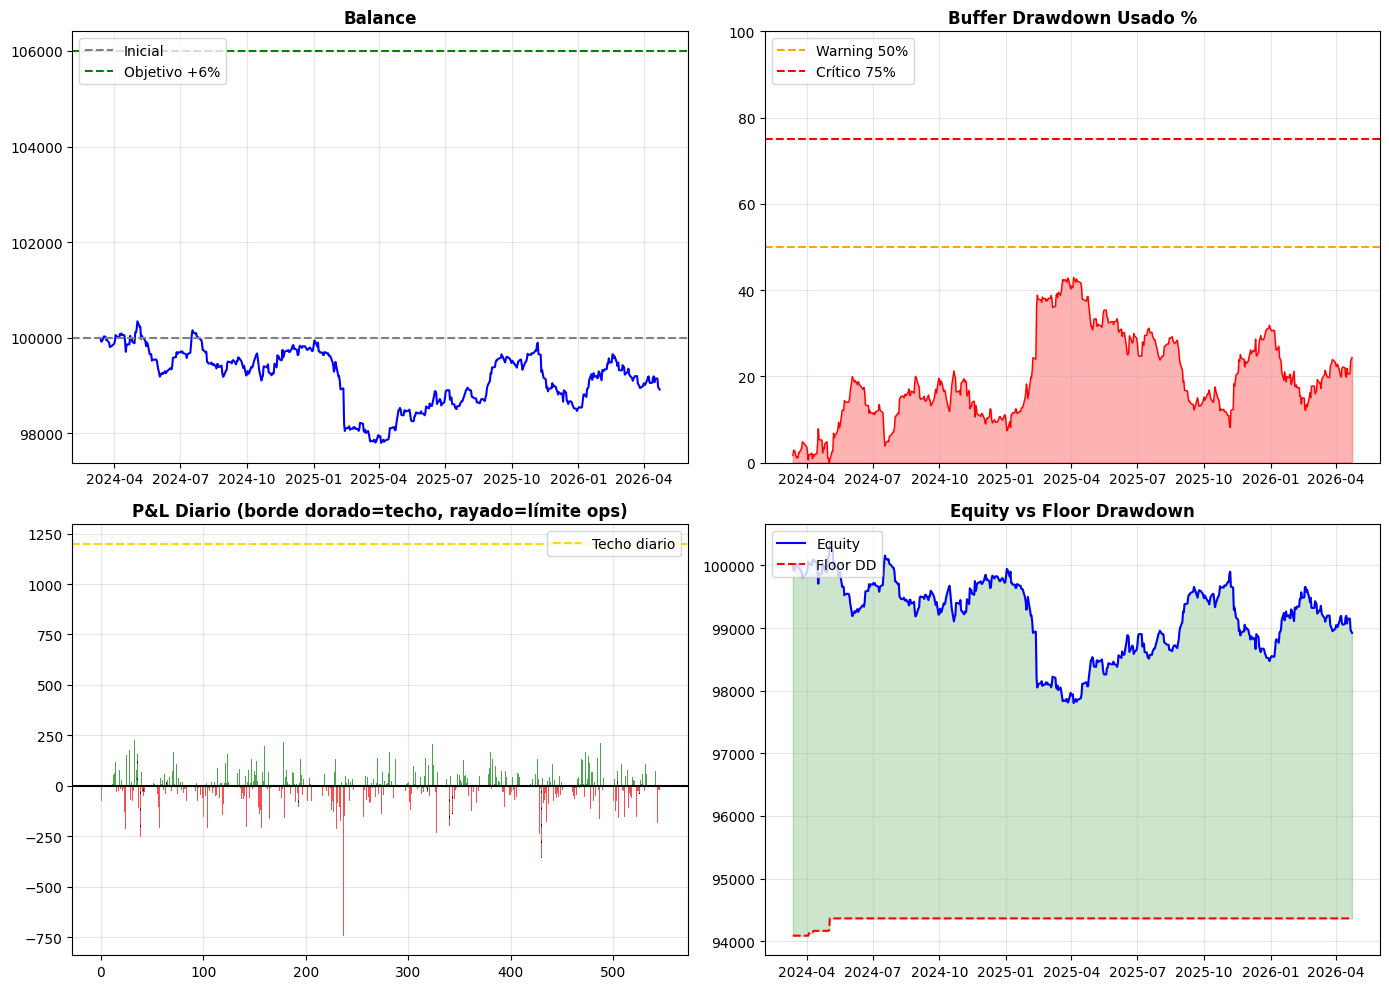

📊 Gráfico guardado: backtest_results.png

✅ Backtest completado


In [ ]:
# ============================================================
# TFM BOT TRADING ALGORÍTMICO
# MÓDULO DE RIESGO COMPLETO + BACKTEST
# GetLeveraged Turbo Trade | CFD US500 M15
# ============================================================
# MEJORAS INTEGRADAS:
# - Filtro anti-consecutivo (no entrar en velas consecutivas)
# - Techo diario de ganancias (protege regla consistencia 20%)
# - Filtro apertura americana (15:30-15:45 excluido)
# - Contratos dinámicos por drawdown intradía
# - Control intravela del drawdown
# - Límite máximo de operaciones por día
# - Control de posición única (no operar si ya hay posición abierta)
# ============================================================

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from typing import Dict, List, Tuple, Optional
from collections import defaultdict

# ============================================================
# 1. CONFIGURACIÓN
# ============================================================

CONFIG_RISK = {
    "initial_balance": 100000,

    # Reglas oficiales GetLeveraged
    "daily_loss_limit_pct": 0.03,          # 3% pérdida diaria máxima
    "trailing_drawdown_pct": 0.06,          # 6% drawdown trailing
    "profit_target_pct": 0.06,              # 6% objetivo de ganancia
    "consistency_rule_pct": 0.20,           # Mejor día ≤ 20% del total
    "min_trade_duration_minutes": 2,        # Mínimo 2 minutos por operación
    "max_leverage": 30,                     # Apalancamiento máximo 1:30

    # Reglas internas conservadoras
    "internal_daily_risk_max": 1000,        # Límite interno diario en USD
    "min_signal_score": 50,                 # Score mínimo de señal

    # Riesgo por operación
    "max_risk_per_trade": 150,              # Riesgo máximo por trade USD
    "min_risk_per_trade": 25,               # Riesgo mínimo por trade USD

    # Horario operativo (hora local Madrid)
    "trading_start_hour": 9,
    "trading_end_hour": 21,

    # Filtro apertura americana (15:30-15:45 excluido)
    "us_open_start": 15.50,
    "us_open_end": 15.75,
    "filter_us_open": True,

    # Techo diario de ganancias (protege consistencia)
    "daily_profit_ceiling": 1200,
    "daily_profit_ceiling_enabled": True,

    # Filtro anti-consecutivo
    "min_bars_between_entries": 2,
    "anti_consecutive_enabled": True,

    # NUEVO: Límite de operaciones por día
    "max_trades_per_day": 5,
    "max_trades_per_day_enabled": True,

    # CFD US500
    "point_value_per_lot": 1,

    # Umbrales de alerta
    "alert_threshold_warning": 0.50,        # 50% del buffer usado
    "alert_threshold_critical": 0.75,       # 75% del buffer usado

    # Control de exposición
    "max_positions": 1,                     # Solo 1 posición simultánea
    "max_total_exposure_pct": 0.02,

    # Modo de cuenta
    "account_mode": "EVALUACION"
}

CONFIG_TELEGRAM = {
    "enabled": False,
    "bot_token": "TU_BOT_TOKEN",
    "chat_id": "TU_CHAT_ID",
    "notify_trade_open": True,
    "notify_trade_close": True,
    "notify_daily_summary": True,
    "notify_drawdown_warning": True,
    "notify_drawdown_critical": True,
    "notify_daily_blocked": True,
    "notify_account_blocked": True,
    "notify_profit_target": True,
    "notify_good_day": True,
    "notify_ceiling_reached": True,
    "notify_max_trades_reached": True
}


# ============================================================
# 2. NOTIFICADOR TELEGRAM
# ============================================================

class TelegramNotifier:

    def __init__(self, config: dict):
        self.enabled = config.get("enabled", False)
        self.bot_token = config.get("bot_token", "")
        self.chat_id = config.get("chat_id", "")
        self.config = config

    def _send_message(self, message: str, parse_mode: str = "HTML") -> bool:
        if not self.enabled:
            return False

        url = f"[api.telegram.org](https://api.telegram.org/bot{self.bot_token}/sendMessage)"
        payload = {"chat_id": self.chat_id, "text": message, "parse_mode": parse_mode}

        try:
            response = requests.post(url, json=payload, timeout=10)
            return response.status_code == 200
        except:
            return False

    def notify_trade_open(self, info: dict) -> bool:
        if not self.config.get("notify_trade_open"):
            return False
        direction = "🟢 LONG" if info["signal"] == 1 else "🔴 SHORT"
        message = f"<b>📈 OPERACIÓN ABIERTA</b>\n\n{direction}\nPrecio: {info['entry_price']:.2f}\nRiesgo: ${info['risk_usd']:.2f}\nModo: {info['mode']}"
        return self._send_message(message)

    def notify_trade_close(self, info: dict) -> bool:
        if not self.config.get("notify_trade_close"):
            return False
        emoji = "✅" if info["pnl"] >= 0 else "❌"
        message = f"<b>{emoji} CIERRE</b>\n\nP&L: ${info['pnl']:.2f}\nBalance: ${info['balance']:.2f}"
        return self._send_message(message)

    def notify_daily_summary(self, summary: dict) -> bool:
        if not self.config.get("notify_daily_summary"):
            return False
        emoji = "🟢" if summary["pnl_dia"] >= 0 else "🔴"
        message = f"<b>📊 RESUMEN {summary['fecha']}</b>\n\n{emoji} P&L: ${summary['pnl_dia']:.2f}\nBalance: ${summary['balance']:.2f}"
        return self._send_message(message)

    def notify_drawdown_warning(self, info: dict) -> bool:
        if not self.config.get("notify_drawdown_warning"):
            return False
        message = f"<b>⚠️ ALERTA DD</b>\n\nBuffer: {info['buffer_usado_pct']:.1f}%\nModo: {info['modo']}"
        return self._send_message(message)

    def notify_drawdown_critical(self, info: dict) -> bool:
        if not self.config.get("notify_drawdown_critical"):
            return False
        message = f"<b>🚨 DD CRÍTICO</b>\n\nBuffer: {info['buffer_usado_pct']:.1f}%"
        return self._send_message(message)

    def notify_daily_blocked(self, info: dict) -> bool:
        if not self.config.get("notify_daily_blocked"):
            return False
        message = f"<b>🛑 PAUSADO</b>\n\n{info['reason']}"
        return self._send_message(message)

    def notify_account_blocked(self, info: dict) -> bool:
        if not self.config.get("notify_account_blocked"):
            return False
        message = f"<b>⛔ BLOQUEADO</b>\n\n{info['reason']}"
        return self._send_message(message)

    def notify_profit_target(self, info: dict) -> bool:
        if not self.config.get("notify_profit_target"):
            return False
        message = f"<b>🎯 OBJETIVO</b>\n\nRentabilidad: +{info['return_pct']:.2f}%"
        return self._send_message(message)

    def notify_good_day(self, info: dict) -> bool:
        if not self.config.get("notify_good_day"):
            return False
        message = f"<b>🎉 BUEN DÍA</b>\n\nP&L: +${info['pnl']:.2f}"
        return self._send_message(message)

    def notify_ceiling_reached(self, info: dict) -> bool:
        if not self.config.get("notify_ceiling_reached"):
            return False
        message = f"<b>🏆 TECHO DIARIO</b>\n\nP&L día: +${info['pnl_dia']:.2f}\nProtegiendo consistencia"
        return self._send_message(message)

    def notify_max_trades_reached(self, info: dict) -> bool:
        if not self.config.get("notify_max_trades_reached"):
            return False
        message = f"<b>🔢 LÍMITE OPERACIONES</b>\n\nOperaciones hoy: {info['trades_today']}/{info['max_trades']}"
        return self._send_message(message)


# ============================================================
# 3. TRACKER DE CONSISTENCIA
# ============================================================

class ConsistencyTracker:

    def __init__(self, config: dict, notifier: TelegramNotifier = None):
        self.config = config
        self.notifier = notifier
        self.threshold = config.get("consistency_rule_pct", 0.20)
        self.account_mode = config.get("account_mode", "EVALUACION")
        self.daily_profits = {}
        self.payout_eligible = True

    def update_day(self, fecha, pnl: float) -> None:
        if pnl > 0:
            self.daily_profits[fecha] = pnl

    def get_score(self) -> dict:
        if not self.daily_profits:
            return {"best_day_pnl": 0, "total_profit": 0, "consistency_pct": 0, "is_compliant": True}

        total = sum(self.daily_profits.values())
        if total <= 0:
            return {"best_day_pnl": 0, "total_profit": 0, "consistency_pct": 0, "is_compliant": True}

        best_date = max(self.daily_profits, key=self.daily_profits.get)
        best_pnl = self.daily_profits[best_date]
        pct = (best_pnl / total) * 100

        return {
            "best_day_pnl": round(best_pnl, 2),
            "best_day_date": best_date,
            "total_profit": round(total, 2),
            "consistency_pct": round(pct, 2),
            "is_compliant": pct <= (self.threshold * 100)
        }

    def check(self, current_date) -> dict:
        score = self.get_score()
        if not score["is_compliant"] and self.account_mode == "FONDEADA":
            self.payout_eligible = False
        else:
            self.payout_eligible = True
        return {"score": score, "payout_eligible": self.payout_eligible}

    def get_max_allowed_today(self, current_total_profit: float) -> float:
        """
        Calcula el máximo P&L permitido hoy para no violar consistencia.
        """
        if current_total_profit <= 0:
            return float('inf')

        max_if_new_best = current_total_profit * (self.threshold / (1 - self.threshold))
        return max(0, max_if_new_best)

    def get_summary(self) -> dict:
        score = self.get_score()
        return {
            "modo": self.account_mode,
            "score_pct": score["consistency_pct"],
            "limite_pct": self.threshold * 100,
            "cumple": score["is_compliant"],
            "elegible_payout": self.payout_eligible
        }


# ============================================================
# 4. TRACKER ANTI-CONSECUTIVO
# ============================================================

class AntiConsecutiveTracker:
    """
    Evita entradas en velas consecutivas.
    Replica el comportamiento del backtesting que nunca entra
    en dos velas seguidas (evita sobreoperar en momentum).
    """

    def __init__(self, config: dict):
        self.min_bars = config.get("min_bars_between_entries", 2)
        self.enabled = config.get("anti_consecutive_enabled", True)
        self.last_entry_bar_index = None
        self.last_entry_timestamp = None

    def register_entry(self, bar_index: int, timestamp: datetime) -> None:
        self.last_entry_bar_index = bar_index
        self.last_entry_timestamp = timestamp

    def can_enter(self, current_bar_index: int, current_timestamp: datetime) -> Tuple[bool, str]:
        if not self.enabled:
            return True, "Filtro desactivado"

        if self.last_entry_bar_index is None:
            return True, "Primera entrada"

        bars_since_last = current_bar_index - self.last_entry_bar_index

        if bars_since_last < self.min_bars:
            return False, f"Anti-consecutivo: {bars_since_last} velas desde última entrada (mín: {self.min_bars})"

        return True, "OK"

    def reset_day(self) -> None:
        """Resetear al inicio de cada día"""
        self.last_entry_bar_index = None
        self.last_entry_timestamp = None


# ============================================================
# 5. GESTOR DE RIESGO
# ============================================================

class RiskManager:

    def __init__(self, config: dict, telegram_config: dict = None):
        self.config = config

        self.initial_balance = config["initial_balance"]
        self.balance = config["initial_balance"]
        self.equity = config["initial_balance"]
        self.max_equity = config["initial_balance"]

        self.current_day = None
        self.day_start_balance = config["initial_balance"]
        self.daily_pnl = 0
        self.daily_risk_used = 0
        self.daily_trades = []

        self.blocked_today = False
        self.blocked_total = False
        self.block_reason = ""

        # Techo diario y límite operaciones
        self.ceiling_reached_today = False
        self.max_trades_reached_today = False

        self.profit_target_reached = False
        self.profit_target_notified = False

        self.daily_log = []
        self.trade_log = []
        self.rejection_log = defaultdict(int)

        self.warning_sent_today = False
        self.critical_sent_today = False

        self.notifier = TelegramNotifier(telegram_config) if telegram_config else None
        self.consistency = ConsistencyTracker(config, self.notifier)

        # Tracker anti-consecutivo
        self.anti_consecutive = AntiConsecutiveTracker(config)

        # Índice de barra actual
        self.current_bar_index = 0

    def update_day(self, timestamp: datetime) -> None:
        day = timestamp.date()

        if self.current_day != day:
            if self.current_day is not None:
                self._close_day()

            self.current_day = day
            self.day_start_balance = self.balance
            self.daily_pnl = 0
            self.daily_risk_used = 0
            self.daily_trades = []
            self.blocked_today = False
            self.ceiling_reached_today = False
            self.max_trades_reached_today = False
            self.warning_sent_today = False
            self.critical_sent_today = False

            # Reset anti-consecutivo al cambiar de día
            self.anti_consecutive.reset_day()

    def _close_day(self) -> None:
        summary = self.get_daily_summary()
        self.daily_log.append(summary)

        if summary["pnl_dia"] > 0:
            self.consistency.update_day(summary["fecha"], summary["pnl_dia"])

        self.consistency.check(summary["fecha"])

        if self.notifier:
            self.notifier.notify_daily_summary(summary)

    def update_equity(self, equity: float) -> None:
        self.equity = equity
        if equity > self.max_equity:
            self.max_equity = equity
            self._check_profit_target()

    def update_equity_intrabar(self, best_equity: float, worst_equity: float) -> None:
        if best_equity > self.max_equity:
            self.max_equity = best_equity
            self._check_profit_target()
        self.equity = worst_equity

    def _check_profit_target(self) -> None:
        target = self.initial_balance * (1 + self.config["profit_target_pct"])
        if self.max_equity >= target and not self.profit_target_reached:
            self.profit_target_reached = True
            if self.notifier and not self.profit_target_notified:
                self.notifier.notify_profit_target({
                    "equity": self.max_equity,
                    "return_pct": ((self.max_equity / self.initial_balance) - 1) * 100,
                    "locked_floor": self.initial_balance
                })
                self.profit_target_notified = True

    def get_drawdown_floor(self) -> float:
        if self.profit_target_reached:
            return self.initial_balance
        return self.max_equity * (1 - self.config["trailing_drawdown_pct"])

    def get_buffer_ratio(self) -> float:
        floor = self.get_drawdown_floor()
        total_buffer = self.max_equity - floor
        current_buffer = self.equity - floor
        if total_buffer <= 0:
            return 0
        return max(0, min(current_buffer / total_buffer, 1))

    def get_buffer_used_pct(self) -> float:
        return (1 - self.get_buffer_ratio()) * 100

    def check_trailing_drawdown(self) -> Tuple[bool, str]:
        floor = self.get_drawdown_floor()
        if self.equity <= floor:
            self.blocked_total = True
            self.block_reason = "Drawdown trailing alcanzado"
            if self.notifier:
                self.notifier.notify_account_blocked({"reason": self.block_reason, "equity": self.equity, "dd_floor": floor})
            return False, self.block_reason
        return True, "OK"

    def check_daily_loss(self) -> Tuple[bool, str]:
        official_limit = self.day_start_balance * self.config["daily_loss_limit_pct"]
        internal_limit = self.config["internal_daily_risk_max"]

        if self.daily_pnl <= -official_limit:
            self.blocked_today = True
            reason = "Pérdida diaria 3% alcanzada"
            if self.notifier:
                self.notifier.notify_daily_blocked({"reason": reason, "daily_pnl": self.daily_pnl})
            return False, reason

        if self.daily_pnl <= -internal_limit:
            self.blocked_today = True
            reason = "Límite interno diario alcanzado"
            if self.notifier:
                self.notifier.notify_daily_blocked({"reason": reason, "daily_pnl": self.daily_pnl})
            return False, reason

        return True, "OK"

    def check_daily_ceiling(self) -> Tuple[bool, str]:
        """Verifica si se alcanzó el techo diario de ganancias"""
        if not self.config.get("daily_profit_ceiling_enabled", True):
            return True, "OK"

        ceiling = self.config.get("daily_profit_ceiling", 1200)

        if self.daily_pnl >= ceiling:
            self.ceiling_reached_today = True
            reason = f"Techo diario ${ceiling} alcanzado (protección consistencia)"
            if self.notifier:
                self.notifier.notify_ceiling_reached({"pnl_dia": self.daily_pnl, "ceiling": ceiling})
            return False, reason

        return True, "OK"

    def check_max_trades_per_day(self) -> Tuple[bool, str]:
        """Verifica si se alcanzó el límite de operaciones diarias"""
        if not self.config.get("max_trades_per_day_enabled", True):
            return True, "OK"

        max_trades = self.config.get("max_trades_per_day", 5)
        trades_today = len(self.daily_trades)

        if trades_today >= max_trades:
            self.max_trades_reached_today = True
            reason = f"Límite diario {max_trades} operaciones alcanzado"
            if self.notifier:
                self.notifier.notify_max_trades_reached({"trades_today": trades_today, "max_trades": max_trades})
            return False, reason

        return True, "OK"

    def check_trading_hours(self, timestamp: datetime) -> Tuple[bool, str]:
        hour = timestamp.hour
        minute = timestamp.minute
        hora_decimal = hour + minute / 60

        # Horario general
        if hour < self.config["trading_start_hour"] or hour >= self.config["trading_end_hour"]:
            return False, "Fuera de horario"

        # Filtro apertura americana
        if self.config.get("filter_us_open", True):
            us_start = self.config.get("us_open_start", 15.50)
            us_end = self.config.get("us_open_end", 15.75)
            if us_start <= hora_decimal < us_end:
                return False, "Filtro apertura US (15:30-15:45)"

        return True, "OK"

    def check_min_duration(self, open_time: datetime, close_time: datetime) -> Tuple[bool, str]:
        duration = (close_time - open_time).total_seconds() / 60
        if duration < self.config["min_trade_duration_minutes"]:
            return False, f"Duración {duration:.1f}m < {self.config['min_trade_duration_minutes']}m"
        return True, "OK"

    def check_leverage(self, lot_size: float, entry_price: float) -> Tuple[bool, str]:
        if self.equity <= 0:
            return False, "Equity inválida"
        position_value = lot_size * entry_price * self.config["point_value_per_lot"]
        leverage = position_value / self.equity
        if leverage > self.config["max_leverage"]:
            return False, f"Apalancamiento {leverage:.1f}x > {self.config['max_leverage']}x"
        return True, "OK"

    def check_stop_loss(self, stop_loss_points: float) -> Tuple[bool, str]:
        if stop_loss_points is None or stop_loss_points <= 0:
            return False, "Stop loss inválido"
        return True, "OK"

    def check_anti_consecutive(self, bar_index: int, timestamp: datetime) -> Tuple[bool, str]:
        """Verifica filtro anti-consecutivo"""
        return self.anti_consecutive.can_enter(bar_index, timestamp)

    def _check_alerts(self) -> None:
        if not self.notifier:
            return
        buffer_used = self.get_buffer_used_pct()
        info = {"buffer_usado_pct": buffer_used, "equity": self.equity, "dd_floor": self.get_drawdown_floor(), "modo": self.get_risk_mode()}

        if buffer_used >= self.config["alert_threshold_critical"] * 100 and not self.critical_sent_today:
            self.notifier.notify_drawdown_critical(info)
            self.critical_sent_today = True
        elif buffer_used >= self.config["alert_threshold_warning"] * 100 and not self.warning_sent_today:
            self.notifier.notify_drawdown_warning(info)
            self.warning_sent_today = True

    def get_risk_mode(self) -> str:
        buffer = self.get_buffer_ratio()
        if buffer > 0.70:
            return "NORMAL"
        elif buffer > 0.40:
            return "CONSERVADOR"
        elif buffer > 0.20:
            return "SUPERVIVENCIA"
        else:
            return "BLOQUEADO"

    def get_contracts_by_drawdown(self, base_contracts: int = 3) -> int:
        """
        Ajusta contratos según drawdown intradía.
        Más defensivo cuando el drawdown sube.
        """
        buffer = self.get_buffer_ratio()
        dd_from_max = self.max_equity - self.equity

        if buffer <= 0.20:
            return 0
        elif dd_from_max >= 800 or buffer <= 0.30:
            return max(1, base_contracts - 2)
        elif dd_from_max >= 600 or buffer <= 0.50:
            return max(1, base_contracts - 1)
        elif self.daily_pnl >= 800:
            return min(base_contracts + 2, 5)
        elif self.daily_pnl >= 400:
            return min(base_contracts + 1, 4)
        else:
            return base_contracts

    def calculate_risk_smooth(self, signal_score: float) -> float:
        if signal_score < self.config["min_signal_score"]:
            return 0

        buffer = self.get_buffer_ratio()
        if buffer <= 0.20:
            return 0

        max_risk = self.config["max_risk_per_trade"]
        min_risk = self.config["min_risk_per_trade"]

        scale = (buffer - 0.20) / 0.80
        base_risk = min_risk + (max_risk - min_risk) * scale

        if signal_score >= 80:
            multiplier = 1.0
        elif signal_score >= 65:
            multiplier = 0.75
        else:
            multiplier = 0.50

        risk = base_risk * multiplier
        remaining = self._get_daily_budget() - self.daily_risk_used
        risk = min(risk, remaining)

        if risk < self.config["min_risk_per_trade"]:
            return 0

        return round(risk, 2)

    def _get_daily_budget(self) -> float:
        mode = self.get_risk_mode()
        base_budgets = {"NORMAL": 1000, "CONSERVADOR": 600, "SUPERVIVENCIA": 250, "BLOQUEADO": 0}
        budget = base_budgets.get(mode, 0)

        # Reducir presupuesto si nos acercamos al techo
        if self.config.get("daily_profit_ceiling_enabled", True):
            ceiling = self.config.get("daily_profit_ceiling", 1200)
            remaining_to_ceiling = ceiling - self.daily_pnl
            if remaining_to_ceiling < budget:
                budget = max(0, remaining_to_ceiling * 0.5)

        return budget

    def calculate_lot_size(self, risk_usd: float, stop_loss_points: float) -> float:
        if stop_loss_points <= 0 or risk_usd <= 0:
            return 0
        return round(risk_usd / (stop_loss_points * self.config["point_value_per_lot"]), 4)

    def evaluate_trade(self, signal: dict, bar_index: int = None) -> dict:
        timestamp = signal["timestamp"]
        direction = signal["signal"]
        score = signal["signal_score"]
        entry_price = signal["entry_price"]
        sl_points = signal["stop_loss_points"]

        self.update_day(timestamp)

        # Actualizar índice de barra
        if bar_index is not None:
            self.current_bar_index = bar_index

        base = {"allowed": False, "reason": "", "risk_usd": 0, "lot_size": 0, "mode": self.get_risk_mode()}

        if direction == 0:
            base["reason"] = "Sin señal"
            return base

        if self.blocked_total:
            base["reason"] = "Cuenta bloqueada"
            self.rejection_log["Cuenta bloqueada"] += 1
            return base

        if self.blocked_today:
            base["reason"] = "Bloqueado hoy"
            self.rejection_log["Bloqueado hoy"] += 1
            return base

        # Verificar techo diario
        if self.ceiling_reached_today:
            base["reason"] = "Techo diario alcanzado"
            self.rejection_log["Techo diario"] += 1
            return base

        # Verificar límite operaciones diarias
        if self.max_trades_reached_today:
            base["reason"] = "Límite operaciones diarias"
            self.rejection_log["Límite operaciones diarias"] += 1
            return base

        # Verificar filtro anti-consecutivo
        if bar_index is not None:
            ok_anti, reason_anti = self.check_anti_consecutive(bar_index, timestamp)
            if not ok_anti:
                base["reason"] = reason_anti
                self.rejection_log["Anti-consecutivo"] += 1
                return base

        # Verificaciones de reglas
        checks = [
            self.check_trading_hours(timestamp),
            self.check_trailing_drawdown(),
            self.check_daily_loss(),
            self.check_daily_ceiling(),
            self.check_max_trades_per_day(),
            self.check_stop_loss(sl_points)
        ]

        for ok, reason in checks:
            if not ok:
                base["reason"] = reason
                self.rejection_log[reason] += 1
                return base

        risk_usd = self.calculate_risk_smooth(score)
        if risk_usd <= 0:
            base["reason"] = "Riesgo cero"
            self.rejection_log["Riesgo cero"] += 1
            return base

        lot_size = self.calculate_lot_size(risk_usd, sl_points)
        if lot_size <= 0:
            base["reason"] = "Lote inválido"
            self.rejection_log["Lote inválido"] += 1
            return base

        ok_lev, reason_lev = self.check_leverage(lot_size, entry_price)
        if not ok_lev:
            base["reason"] = reason_lev
            self.rejection_log["Apalancamiento"] += 1
            return base

        self._check_alerts()

        return {"allowed": True, "reason": "Autorizada", "risk_usd": risk_usd, "lot_size": lot_size, "mode": self.get_risk_mode()}

    def confirm_trade_open(self, risk_usd: float, info: dict, bar_index: int = None) -> None:
        self.daily_risk_used += risk_usd
        self.update_equity(self.balance)

        # Registrar entrada para anti-consecutivo
        if bar_index is not None:
            self.anti_consecutive.register_entry(bar_index, info.get("timestamp", datetime.now()))

        if self.notifier:
            self.notifier.notify_trade_open(info)

    def register_trade_result(self, open_time: datetime, close_time: datetime, pnl: float, details: dict) -> dict:
        self.update_day(close_time)

        ok_dur, reason_dur = self.check_min_duration(open_time, close_time)
        duration = (close_time - open_time).total_seconds() / 60

        self.balance += pnl
        self.equity = self.balance
        if self.equity > self.max_equity:
            self.max_equity = self.equity
            self._check_profit_target()

        self.daily_pnl += pnl

        # Verificar techo después de cada trade
        self.check_daily_ceiling()

        record = {
            "open_time": open_time, "close_time": close_time, "duration_min": round(duration, 2),
            "pnl": round(pnl, 2), "balance": round(self.balance, 2), "equity": round(self.equity, 2),
            "max_equity": round(self.max_equity, 2), "dd_floor": round(self.get_drawdown_floor(), 2),
            "mode": self.get_risk_mode(), "duration_valid": ok_dur, **details
        }

        self.trade_log.append(record)
        self.daily_trades.append(record)

        if self.notifier:
            self.notifier.notify_trade_close({"pnl": pnl, "balance": self.balance, "duration_minutes": duration, "mode": self.get_risk_mode()})

        self.check_trailing_drawdown()
        self.check_daily_loss()

        return {"duration_valid": ok_dur, "duration_reason": reason_dur}

    def get_daily_summary(self) -> dict:
        floor = self.get_drawdown_floor()
        total = len(self.daily_trades)
        wins = sum(1 for t in self.daily_trades if t["pnl"] > 0)
        losses = sum(1 for t in self.daily_trades if t["pnl"] < 0)

        total_profit = sum(t["pnl"] for t in self.daily_trades if t["pnl"] > 0)
        total_loss = abs(sum(t["pnl"] for t in self.daily_trades if t["pnl"] < 0))

        win_rate = (wins / total * 100) if total > 0 else 0
        pf = (total_profit / total_loss) if total_loss > 0 else float('inf') if total_profit > 0 else 0

        consistency = self.consistency.get_score()

        return {
            "fecha": self.current_day,
            "balance_inicio": round(self.day_start_balance, 2),
            "balance": round(self.balance, 2),
            "equity": round(self.equity, 2),
            "equity_max": round(self.max_equity, 2),
            "limite_drawdown": round(floor, 2),
            "distancia_drawdown": round(self.equity - floor, 2),
            "buffer_usado_pct": round(self.get_buffer_used_pct(), 2),
            "pnl_dia": round(self.daily_pnl, 2),
            "rentabilidad_dia_pct": round((self.daily_pnl / self.day_start_balance) * 100, 4),
            "riesgo_usado_dia": round(self.daily_risk_used, 2),
            "presupuesto_dia": self._get_daily_budget(),
            "total_operaciones": total,
            "operaciones_ganadoras": wins,
            "operaciones_perdedoras": losses,
            "win_rate": round(win_rate, 2),
            "profit_factor": round(pf, 2) if pf != float('inf') else "∞",
            "modo": self.get_risk_mode(),
            "bloqueado_hoy": self.blocked_today,
            "bloqueado_total": self.blocked_total,
            "techo_alcanzado": self.ceiling_reached_today,
            "limite_ops_alcanzado": self.max_trades_reached_today,
            "consistency_score_pct": consistency["consistency_pct"],
            "payout_elegible": self.consistency.payout_eligible
        }

    def get_final_metrics(self) -> dict:
        if self.current_day is not None:
            self._close_day()

        total = len(self.trade_log)
        wins = sum(1 for t in self.trade_log if t["pnl"] > 0)
        total_pnl = sum(t["pnl"] for t in self.trade_log)

        best_day = max(self.daily_log, key=lambda x: x["pnl_dia"]) if self.daily_log else None
        worst_day = min(self.daily_log, key=lambda x: x["pnl_dia"]) if self.daily_log else None

        # Contar días con techo alcanzado y límite operaciones
        ceiling_days = sum(1 for d in self.daily_log if d.get("techo_alcanzado", False))
        max_trades_days = sum(1 for d in self.daily_log if d.get("limite_ops_alcanzado", False))

        return {
            "balance_inicial": self.initial_balance,
            "balance_final": round(self.balance, 2),
            "rentabilidad_pct": round(((self.balance / self.initial_balance) - 1) * 100, 2),
            "equity_maxima": round(self.max_equity, 2),
            "dd_floor_actual": round(self.get_drawdown_floor(), 2),
            "distancia_dd": round(self.balance - self.get_drawdown_floor(), 2),
            "estado": self.get_risk_mode(),
            "bloqueado": self.blocked_total,
            "objetivo_alcanzado": self.profit_target_reached,
            "total_operaciones": total,
            "operaciones_ganadoras": wins,
            "win_rate_global": round((wins / total * 100) if total > 0 else 0, 2),
            "pnl_total": round(total_pnl, 2),
            "dias_operados": len(self.daily_log),
            "dias_techo_alcanzado": ceiling_days,
            "dias_limite_ops_alcanzado": max_trades_days,
            "mejor_dia": best_day,
            "peor_dia": worst_day,
            "consistencia": self.consistency.get_summary(),
            "rechazos": dict(self.rejection_log)
        }


# ============================================================
# 6. CONTROL INTRAVELA
# ============================================================

def check_intrabar_risk(row: pd.Series, position: dict, rm: RiskManager) -> Tuple[bool, str]:
    if position is None:
        return True, "Sin posición"

    direction = position["signal"]
    entry = position["entry_price"]
    lot = position["lot_size"]
    pv = rm.config["point_value_per_lot"]

    if direction == 1:
        best_pnl = (row["high"] - entry) * lot * pv
        worst_pnl = (row["low"] - entry) * lot * pv
    else:
        best_pnl = (entry - row["low"]) * lot * pv
        worst_pnl = (entry - row["high"]) * lot * pv

    best_equity = rm.balance + best_pnl
    worst_equity = rm.balance + worst_pnl

    rm.update_equity_intrabar(best_equity, worst_equity)

    floor = rm.get_drawdown_floor()
    if worst_equity <= floor:
        rm.blocked_total = True
        rm.block_reason = "Drawdown intravela"
        if rm.notifier:
            rm.notifier.notify_account_blocked({"reason": "DD intravela", "equity": worst_equity, "dd_floor": floor})
        return False, f"DD intravela: {worst_equity:.2f} <= {floor:.2f}"

    rm._check_alerts()
    return True, "OK"


# ============================================================
# 7. BACKTEST
# ============================================================

def run_backtest(df: pd.DataFrame, config_risk: dict, config_telegram: dict = None) -> dict:
    rm = RiskManager(config_risk, config_telegram)

    position = None
    results = []

    for bar_index, (i, row) in enumerate(df.iterrows()):
        ts = row["time"]
        rm.update_day(ts)

        # Control intravela si hay posición abierta
        if position is not None:
            ok, reason = check_intrabar_risk(row, position, rm)
            if not ok:
                direction = position["signal"]
                entry = position["entry_price"]
                lot = position["lot_size"]
                exit_price = row["low"] if direction == 1 else row["high"]
                pnl = ((exit_price - entry) if direction == 1 else (entry - exit_price)) * lot * config_risk["point_value_per_lot"]
                rm.register_trade_result(position["open_time"], ts, pnl, {"exit_reason": "DD_INTRAVELA", "exit_price": exit_price})
                results.append({"time": ts, "bar_index": bar_index, "event": "BLOQUEO_INTRAVELA", "reason": reason})
                position = None
                break

        # Evaluar nueva entrada SOLO si no hay posición abierta
        if position is None:
            signal = {
                "timestamp": ts,
                "signal": row["signal"],
                "signal_score": row["signal_score"],
                "entry_price": row["close"],
                "stop_loss_points": row["stop_loss_points"]
            }

            # Pasar bar_index para filtro anti-consecutivo
            decision = rm.evaluate_trade(signal, bar_index=bar_index)

            results.append({
                "time": ts,
                "bar_index": bar_index,
                "event": "EVAL",
                "signal": row["signal"],
                "score": row["signal_score"],
                "allowed": decision["allowed"],
                "reason": decision["reason"],
                "risk_usd": decision["risk_usd"],
                "lot": decision["lot_size"],
                "mode": decision["mode"]
            })

            if decision["allowed"]:
                position = {
                    "open_time": ts,
                    "signal": row["signal"],
                    "entry_price": row["close"],
                    "lot_size": decision["lot_size"],
                    "risk_usd": decision["risk_usd"],
                    "stop_loss_points": row["stop_loss_points"],
                    "bar_index": bar_index
                }

                # Pasar bar_index a confirm
                rm.confirm_trade_open(
                    decision["risk_usd"],
                    {
                        "timestamp": ts,
                        "signal": row["signal"],
                        "entry_price": row["close"],
                        "risk_usd": decision["risk_usd"],
                        "lot_size": decision["lot_size"],
                        "mode": decision["mode"]
                    },
                    bar_index=bar_index
                )

        # Cerrar posición al final de la barra
        elif position is not None:
            direction = position["signal"]
            entry = position["entry_price"]
            exit_price = row["close"]
            lot = position["lot_size"]
            pnl = ((exit_price - entry) if direction == 1 else (entry - exit_price)) * lot * config_risk["point_value_per_lot"]

            rm.register_trade_result(position["open_time"], ts, pnl, {
                "entry_price": entry,
                "exit_price": exit_price,
                "direction": direction,
                "exit_reason": "CIERRE_NORMAL"
            })

            results.append({
                "time": ts,
                "bar_index": bar_index,
                "event": "CIERRE",
                "pnl": round(pnl, 2),
                "balance": rm.balance,
                "mode": rm.get_risk_mode()
            })
            position = None

            if rm.blocked_total or rm.blocked_today:
                results.append({
                    "time": ts,
                    "bar_index": bar_index,
                    "event": "PAUSADO",
                    "reason": "DD" if rm.blocked_total else "Diario"
                })

    return {
        "risk_manager": rm,
        "results": pd.DataFrame(results),
        "daily": pd.DataFrame(rm.daily_log),
        "trades": pd.DataFrame(rm.trade_log),
        "metrics": rm.get_final_metrics()
    }


# ============================================================
# 8. PREPARACIÓN DE DATOS
# ============================================================

def prepare_data_with_signals(df: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    """Añade señales simuladas para probar el módulo de riesgo."""
    df = df.copy()
    np.random.seed(seed)

    n = len(df)

    signal_mask = np.random.random(n) < 0.05
    signals = np.zeros(n, dtype=int)
    signals[signal_mask] = np.random.choice([1, -1], size=signal_mask.sum())
    df["signal"] = signals

    scores = np.zeros(n)
    scores[signal_mask] = np.random.randint(50, 100, size=signal_mask.sum())
    df["signal_score"] = scores

    df["atr"] = (df["high"] - df["low"]).rolling(14).mean()
    df["stop_loss_points"] = df["atr"] * 1.5
    df["stop_loss_points"] = df["stop_loss_points"].fillna(5)

    df = df.dropna().reset_index(drop=True)

    print(f"✅ Datos preparados: {len(df)} velas, {(df['signal'] != 0).sum()} señales")
    return df


# ============================================================
# 9. VERIFICACIÓN DE CUMPLIMIENTO
# ============================================================

def verify_compliance(metrics: dict, df_daily: pd.DataFrame, df_trades: pd.DataFrame, config: dict) -> dict:
    results = {"reglas": [], "cumple_todas": True}

    # Pérdida diaria
    if not df_daily.empty:
        worst = df_daily["rentabilidad_dia_pct"].min()
        limit = -config["daily_loss_limit_pct"] * 100
        cumple = worst >= limit
        results["reglas"].append({
            "regla": "Pérdida diaria 3%",
            "limite": f"{limit:.2f}%",
            "valor": f"{worst:.2f}%",
            "cumple": cumple
        })
        if not cumple:
            results["cumple_todas"] = False

    # Drawdown
    cumple_dd = not metrics["bloqueado"]
    results["reglas"].append({
        "regla": "Drawdown 6%",
        "limite": "No tocar floor",
        "valor": "OK" if cumple_dd else "VIOLADO",
        "cumple": cumple_dd
    })
    if not cumple_dd:
        results["cumple_todas"] = False

    # Objetivo
    results["reglas"].append({
        "regla": "Objetivo 6%",
        "limite": "6%",
        "valor": f"{metrics['rentabilidad_pct']:.2f}%",
        "cumple": metrics["objetivo_alcanzado"]
    })

    # Consistencia
    c = metrics["consistencia"]
    results["reglas"].append({
        "regla": "Consistencia 20%",
        "limite": f"{c['limite_pct']:.0f}%",
        "valor": f"{c['score_pct']:.1f}%",
        "cumple": c["cumple"],
        "nota": "Informativo"
    })

    # Duración
    if not df_trades.empty and "duration_valid" in df_trades.columns:
        invalidos = (~df_trades["duration_valid"]).sum()
        cumple_dur = invalidos == 0
        results["reglas"].append({
            "regla": "Duración 2 min",
            "limite": "2 min",
            "valor": f"{invalidos} inválidas",
            "cumple": cumple_dur
        })
        if not cumple_dur:
            results["cumple_todas"] = False

    # Días con techo alcanzado
    results["reglas"].append({
        "regla": "Protección consistencia (techo)",
        "limite": "Informativo",
        "valor": f"{metrics.get('dias_techo_alcanzado', 0)} días",
        "cumple": True,
        "nota": "Días donde se detuvo para proteger la regla 20%"
    })

    # Días con límite operaciones alcanzado
    results["reglas"].append({
        "regla": "Límite operaciones diarias",
        "limite": f"{config.get('max_trades_per_day', 5)} ops/día",
        "valor": f"{metrics.get('dias_limite_ops_alcanzado', 0)} días",
        "cumple": True,
        "nota": "Días donde se alcanzó el límite de operaciones"
    })

    return results


# ============================================================
# 10. VISUALIZACIÓN
# ============================================================

def print_report(metrics: dict) -> None:
    print("\n" + "=" * 60)
    print("              INFORME FINAL BACKTEST")
    print("=" * 60)

    print(f"\n{'RENDIMIENTO':-^60}")
    print(f"  Balance inicial:    ${metrics['balance_inicial']:,.2f}")
    print(f"  Balance final:      ${metrics['balance_final']:,.2f}")
    print(f"  Rentabilidad:       {metrics['rentabilidad_pct']:+.2f}%")
    print(f"  Objetivo alcanzado: {'✅' if metrics['objetivo_alcanzado'] else '❌'}")

    print(f"\n{'DRAWDOWN':-^60}")
    print(f"  Equity máxima:      ${metrics['equity_maxima']:,.2f}")
    print(f"  Floor actual:       ${metrics['dd_floor_actual']:,.2f}")
    print(f"  Distancia:          ${metrics['distancia_dd']:,.2f}")
    print(f"  Bloqueado:          {'⛔' if metrics['bloqueado'] else '✅'}")

    print(f"\n{'OPERACIONES':-^60}")
    print(f"  Total:              {metrics['total_operaciones']}")
    print(f"  Ganadoras:          {metrics['operaciones_ganadoras']}")
    print(f"  Win rate:           {metrics['win_rate_global']:.1f}%")

    c = metrics["consistencia"]
    print(f"\n{'CONSISTENCIA':-^60}")
    print(f"  Score:              {c['score_pct']:.1f}% (máx {c['limite_pct']:.0f}%)")
    print(f"  Cumple:             {'✅' if c['cumple'] else '⚠️'}")
    print(f"  Días con techo:     {metrics.get('dias_techo_alcanzado', 0)}")
    print(f"  Días límite ops:    {metrics.get('dias_limite_ops_alcanzado', 0)}")

    print(f"\n{'RECHAZOS':-^60}")
    for reason, count in metrics.get("rechazos", {}).items():
        print(f"  {reason}: {count}")

    print("=" * 60)


def print_compliance(compliance: dict) -> None:
    print("\n" + "=" * 60)
    print("           VERIFICACIÓN DE REGLAS")
    print("=" * 60)

    for r in compliance["reglas"]:
        emoji = "✅" if r["cumple"] else "❌"
        print(f"\n{emoji} {r['regla']}")
        print(f"   Límite: {r['limite']} | Resultado: {r['valor']}")
        if "nota" in r:
            print(f"   Nota: {r['nota']}")

    print("\n" + "-" * 60)
    print(f"   {'🎉 TODAS LAS REGLAS OK' if compliance['cumple_todas'] else '❌ HAY VIOLACIONES'}")
    print("=" * 60)


def plot_results(df_daily: pd.DataFrame, config: dict) -> None:
    if df_daily.empty:
        print("Sin datos para graficar")
        return

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Balance
    axes[0, 0].plot(df_daily["fecha"], df_daily["balance"], 'b-', linewidth=1.5)
    axes[0, 0].axhline(config["initial_balance"], color='gray', linestyle='--', label='Inicial')
    axes[0, 0].axhline(config["initial_balance"] * 1.06, color='green', linestyle='--', label='Objetivo +6%')
    axes[0, 0].set_title("Balance", fontsize=12, fontweight='bold')
    axes[0, 0].legend(loc='upper left')
    axes[0, 0].grid(True, alpha=0.3)

    # Buffer usado
    axes[0, 1].fill_between(df_daily["fecha"], df_daily["buffer_usado_pct"], alpha=0.3, color='red')
    axes[0, 1].plot(df_daily["fecha"], df_daily["buffer_usado_pct"], 'r-', linewidth=1)
    axes[0, 1].axhline(50, color='orange', linestyle='--', label='Warning 50%')
    axes[0, 1].axhline(75, color='red', linestyle='--', label='Crítico 75%')
    axes[0, 1].set_title("Buffer Drawdown Usado %", fontsize=12, fontweight='bold')
    axes[0, 1].set_ylim(0, 100)
    axes[0, 1].legend(loc='upper left')
    axes[0, 1].grid(True, alpha=0.3)

    # P&L diario con marcadores
    colors = ['green' if x >= 0 else 'red' for x in df_daily["pnl_dia"]]
    bars = axes[1, 0].bar(range(len(df_daily)), df_daily["pnl_dia"], color=colors, alpha=0.7)

    # Marcar días con techo alcanzado
    if "techo_alcanzado" in df_daily.columns:
        for idx, (_, row) in enumerate(df_daily.iterrows()):
            if row.get("techo_alcanzado", False):
                bars[idx].set_edgecolor('gold')
                bars[idx].set_linewidth(2)

    # Marcar días con límite operaciones
    if "limite_ops_alcanzado" in df_daily.columns:
        for idx, (_, row) in enumerate(df_daily.iterrows()):
            if row.get("limite_ops_alcanzado", False):
                bars[idx].set_hatch('//')

    axes[1, 0].axhline(0, color='black')
    axes[1, 0].axhline(config.get("daily_profit_ceiling", 1200), color='gold', linestyle='--', label='Techo diario')
    axes[1, 0].set_title("P&L Diario (borde dorado=techo, rayado=límite ops)", fontsize=12, fontweight='bold')
    axes[1, 0].legend(loc='upper right')
    axes[1, 0].grid(True, alpha=0.3)

    # Equity vs Floor
    axes[1, 1].plot(df_daily["fecha"], df_daily["equity"], 'b-', label='Equity', linewidth=1.5)
    axes[1, 1].plot(df_daily["fecha"], df_daily["limite_drawdown"], 'r--', label='Floor DD', linewidth=1.5)
    axes[1, 1].fill_between(df_daily["fecha"], df_daily["limite_drawdown"], df_daily["equity"], alpha=0.2, color='green')
    axes[1, 1].set_title("Equity vs Floor Drawdown", fontsize=12, fontweight='bold')
    axes[1, 1].legend(loc='upper left')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("backtest_results.png", dpi=150)
    plt.show()
    print("📊 Gráfico guardado: backtest_results.png")


# ============================================================
# 11. EJECUCIÓN
# ============================================================

if __name__ == "__main__":
    print("=" * 60)
    print("  BOT FONDEO — BACKTEST CON MEJORAS INTEGRADAS")
    print("=" * 60)
    print("\nMejoras activas:")
    print("  ✓ Filtro anti-consecutivo (mín 2 velas entre entradas)")
    print("  ✓ Techo diario de ganancias ($1,200 — protege consistencia)")
    print("  ✓ Filtro apertura US (15:30-15:45 excluido)")
    print("  ✓ Control intravela del drawdown")
    print("  ✓ Contratos dinámicos por DD intradía")
    print("  ✓ Límite máximo operaciones por día (5)")
    print("  ✓ Solo 1 posición simultánea")
    print()

    # ===========================================================
    # PARA DATOS REALES: Descomentar y ajustar ruta
    # ===========================================================
    # df_raw = pd.read_csv("tu_archivo.csv", parse_dates=["time"])
    # df_raw.columns = df_raw.columns.str.lower().str.strip()
    # print(f"✅ Datos cargados: {len(df_raw)} velas")

    # ===========================================================
    # DATOS SINTÉTICOS (para prueba)
    # ===========================================================
    # ===========================================================
    # CARGAR DATOS REALES DESDE CSV
    # ===========================================================
    print("Cargando datos desde CSV...")
    df_raw = pd.read_csv("datos_US500.csv", parse_dates=["time"])
    df_raw.columns = df_raw.columns.str.lower().str.strip()
    print(f"✅ Datos cargados: {len(df_raw)} velas")

    # Preparar con señales
    df = prepare_data_with_signals(df_raw, seed=42)

    # Ejecutar backtest
    print("\nEjecutando backtest...")
    result = run_backtest(df, CONFIG_RISK, CONFIG_TELEGRAM)


    # Preparar con señales
    df = prepare_data_with_signals(df_raw, seed=42)

    # Ejecutar backtest
    print("\nEjecutando backtest...")
    result = run_backtest(df, CONFIG_RISK, CONFIG_TELEGRAM)

    # Resultados
    metrics = result["metrics"]
    df_daily = result["daily"]
    df_trades = result["trades"]

    # Informes
    print_report(metrics)

    compliance = verify_compliance(metrics, df_daily, df_trades, CONFIG_RISK)
    print_compliance(compliance)

    # Gráficos
    plot_results(df_daily, CONFIG_RISK)

    print("\n✅ Backtest completado")


   BOT UNIFICADO — ESTRATEGIA + RIESGO INTEGRADOS
   Cuenta: $100,000 | DD: 6% | Objetivo: 6%
   Estrategia: Donchian30 + SMA200 + CCI>100
   SL: 0.5xATR | TP: 1.5xATR | Ratio: 3:1
   Breakeven WR: 25.0%

[1/6] Cargando datos...
   Cargadas 49,967 velas | 2024-03-12 a 2026-04-24

[2/6] Calculando indicadores...
   Dataset procesado: 49,768 velas

[3/6] Dividiendo datos...
   Entrenamiento: 30,370 velas hasta 2025-06-30
   Test: 11,924 velas
   Forward: 7,474 velas

[4/6] Entrenando modelo ML...
   AUC entrenamiento: 0.5077

[5/6] Ejecutando backtests...

   → TEST...
      Balance: $100,692.18 | Rentab: +0.69%
      Ops: 90 | WR: 27.8% | PF: 1.149

   → FORWARD...
      Balance: $99,824.10 | Rentab: -0.18%
      Ops: 73 | WR: 24.7% | PF: 0.955


   INFORME FINAL — BOT UNIFICADO

─────────────────────────────────────────────────────────────────
  TEST
─────────────────────────────────────────────────────────────────

  RENDIMIENTO
  Balance inicial               : $100,000.00
  Balance 

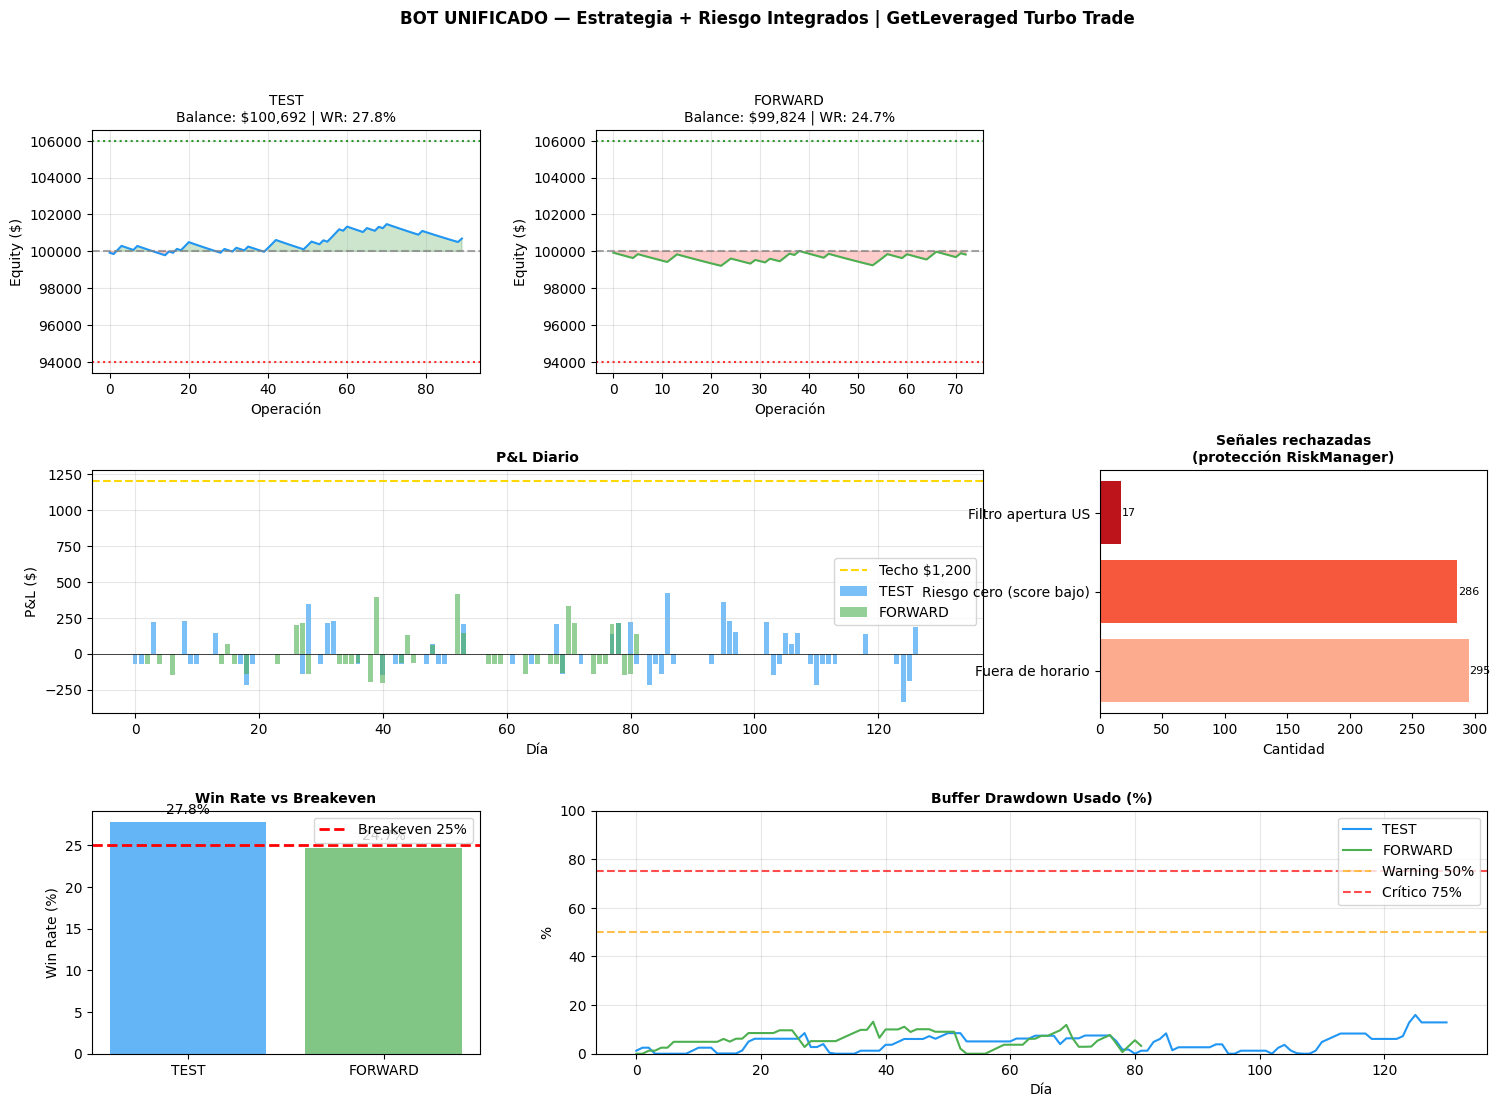


✅ Gráfico guardado: backtest_unificado.png

   BACKTEST COMPLETADO


In [ ]:
# ============================================================
# BOT UNIFICADO — BACKTEST COMPLETO EN COLAB
# GetLeveraged Turbo Trade | CFD US500 M15
# ============================================================
# Ejecutar en Google Colab con datos_US500.csv
# ============================================================

!pip install statsmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from datetime import datetime, timedelta
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from statsmodels.stats.proportion import proportion_confint
import scipy.stats as stats

warnings.filterwarnings('ignore')

# ============================================================
# 1. CONFIGURACIÓN UNIFICADA
# ============================================================

CONFIG = {
    # ── Cuenta GetLeveraged Turbo Trade ──
    "initial_balance": 100_000,
    "daily_loss_limit_pct": 0.03,           # 3%
    "trailing_drawdown_pct": 0.06,          # 6%
    "profit_target_pct": 0.06,              # 6%
    "consistency_rule_pct": 0.20,           # 20%
    "min_trade_duration_minutes": 2,
    "max_leverage": 30,

    # ── Límites internos conservadores ──
    "internal_daily_risk_max": 1000,
    "daily_profit_ceiling": 1200,
    "daily_profit_ceiling_enabled": True,
    "max_trades_per_day": 5,
    "max_trades_per_day_enabled": True,

    # ── Riesgo por operación ──
    "max_risk_per_trade": 150,
    "min_risk_per_trade": 25,
    "min_signal_score": 50,

    # ── Horarios (Madrid) ──
    "trading_start_hour": 9,
    "trading_end_hour": 21,
    "us_open_start": 15.50,
    "us_open_end": 15.75,
    "filter_us_open": True,

    # ── Anti-sobreoperar ──
    "min_bars_between_entries": 2,
    "anti_consecutive_enabled": True,
    "max_positions": 1,

    # ── Estrategia Donchian + CCI + ML ──
    "donchian_period": 30,
    "sma_period": 200,
    "cci_period": 14,
    "cci_threshold": 100,
    "atr_period": 14,
    "sl_multiplier": 0.5,
    "tp_multiplier": 1.5,
    "ml_threshold": 0.50,
    "lookforward_bars": 30,
    "max_bars_in_trade": 32,            # 8 horas en M15

    # ── CFD US500 ──
    "point_value_per_lot": 1,
    "symbol": "US500",
    "timeframe": "M15",

    # ── Alertas ──
    "alert_threshold_warning": 0.50,
    "alert_threshold_critical": 0.75,

    # ── División temporal ──
    # ── División temporal ──
    "train_end_date": "2025-06-30",    # Entrenamiento: ~15 meses
    "test_end_date": "2025-12-31",     # Backtest: ~6 meses
    # Forward: enero 2026 - abril 2026 (~4 meses)


    # ── Modo ──
    "account_mode": "EVALUACION"
}

# Breakeven matemático
WR_BREAKEVEN = CONFIG["sl_multiplier"] / (CONFIG["sl_multiplier"] + CONFIG["tp_multiplier"]) * 100

print("=" * 65)
print("   BOT UNIFICADO — ESTRATEGIA + RIESGO INTEGRADOS")
print("=" * 65)
print(f"   Cuenta: ${CONFIG['initial_balance']:,} | DD: {CONFIG['trailing_drawdown_pct']*100:.0f}% | Objetivo: {CONFIG['profit_target_pct']*100:.0f}%")
print(f"   Estrategia: Donchian{CONFIG['donchian_period']} + SMA{CONFIG['sma_period']} + CCI>{CONFIG['cci_threshold']}")
print(f"   SL: {CONFIG['sl_multiplier']}xATR | TP: {CONFIG['tp_multiplier']}xATR | Ratio: {CONFIG['tp_multiplier']/CONFIG['sl_multiplier']:.0f}:1")
print(f"   Breakeven WR: {WR_BREAKEVEN:.1f}%")
print("=" * 65)


# ============================================================
# 2. CLASES DE RIESGO (del módulo original)
# ============================================================

class ConsistencyTracker:
    """Monitorea la regla del 20%: mejor día ≤ 20% del profit total."""

    def __init__(self, config: dict):
        self.threshold = config.get("consistency_rule_pct", 0.20)
        self.daily_profits = {}

    def update_day(self, fecha, pnl: float) -> None:
        if pnl > 0:
            self.daily_profits[fecha] = pnl

    def get_score(self) -> dict:
        if not self.daily_profits:
            return {"best_day_pnl": 0, "total_profit": 0, "consistency_pct": 0, "is_compliant": True}

        total = sum(self.daily_profits.values())
        if total <= 0:
            return {"best_day_pnl": 0, "total_profit": 0, "consistency_pct": 0, "is_compliant": True}

        best_date = max(self.daily_profits, key=self.daily_profits.get)
        best_pnl = self.daily_profits[best_date]
        pct = (best_pnl / total) * 100

        return {
            "best_day_pnl": round(best_pnl, 2),
            "best_day_date": best_date,
            "total_profit": round(total, 2),
            "consistency_pct": round(pct, 2),
            "is_compliant": pct <= (self.threshold * 100)
        }

    def get_summary(self) -> dict:
        score = self.get_score()
        return {
            "score_pct": score["consistency_pct"],
            "limite_pct": self.threshold * 100,
            "cumple": score["is_compliant"]
        }


class AntiConsecutiveTracker:
    """Evita entradas en velas consecutivas."""

    def __init__(self, config: dict):
        self.min_bars = config.get("min_bars_between_entries", 2)
        self.enabled = config.get("anti_consecutive_enabled", True)
        self.last_entry_bar_index = None

    def register_entry(self, bar_index: int) -> None:
        self.last_entry_bar_index = bar_index

    def can_enter(self, current_bar_index: int) -> Tuple[bool, str]:
        if not self.enabled:
            return True, "Filtro desactivado"
        if self.last_entry_bar_index is None:
            return True, "Primera entrada"

        bars_since = current_bar_index - self.last_entry_bar_index
        if bars_since < self.min_bars:
            return False, f"Anti-consecutivo: {bars_since} velas (mín: {self.min_bars})"
        return True, "OK"

    def reset_day(self) -> None:
        self.last_entry_bar_index = None


class RiskManager:
    """Gestor de riesgo completo para cuentas de fondeo."""

    def __init__(self, config: dict):
        self.config = config
        self.initial_balance = config["initial_balance"]
        self.balance = config["initial_balance"]
        self.equity = config["initial_balance"]
        self.max_equity = config["initial_balance"]

        self.current_day = None
        self.day_start_balance = config["initial_balance"]
        self.daily_pnl = 0
        self.daily_risk_used = 0
        self.daily_trades = []

        self.blocked_today = False
        self.blocked_total = False
        self.block_reason = ""
        self.ceiling_reached_today = False
        self.max_trades_reached_today = False
        self.profit_target_reached = False

        self.daily_log = []
        self.trade_log = []
        self.rejection_log = defaultdict(int)

        self.consistency = ConsistencyTracker(config)
        self.anti_consecutive = AntiConsecutiveTracker(config)

    def update_day(self, timestamp: datetime) -> None:
        day = timestamp.date()
        if self.current_day != day:
            if self.current_day is not None:
                self._close_day()

            self.current_day = day
            self.day_start_balance = self.balance
            self.daily_pnl = 0
            self.daily_risk_used = 0
            self.daily_trades = []
            self.blocked_today = False
            self.ceiling_reached_today = False
            self.max_trades_reached_today = False
            self.anti_consecutive.reset_day()

    def _close_day(self) -> None:
        summary = self._get_daily_summary_internal()
        self.daily_log.append(summary)
        if summary["pnl_dia"] > 0:
            self.consistency.update_day(summary["fecha"], summary["pnl_dia"])

    def _get_daily_summary_internal(self) -> dict:
        floor = self.get_drawdown_floor()
        total = len(self.daily_trades)
        wins = sum(1 for t in self.daily_trades if t["pnl"] > 0)
        return {
            "fecha": self.current_day,
            "balance_inicio": round(self.day_start_balance, 2),
            "balance": round(self.balance, 2),
            "equity": round(self.equity, 2),
            "equity_max": round(self.max_equity, 2),
            "limite_drawdown": round(floor, 2),
            "distancia_drawdown": round(self.equity - floor, 2),
            "buffer_usado_pct": round(self.get_buffer_used_pct(), 2),
            "pnl_dia": round(self.daily_pnl, 2),
            "rentabilidad_dia_pct": round((self.daily_pnl / self.day_start_balance) * 100, 4) if self.day_start_balance > 0 else 0,
            "total_operaciones": total,
            "operaciones_ganadoras": wins,
            "win_rate": round((wins / total * 100) if total > 0 else 0, 2),
            "modo": self.get_risk_mode(),
            "bloqueado_hoy": self.blocked_today,
            "techo_alcanzado": self.ceiling_reached_today,
            "limite_ops_alcanzado": self.max_trades_reached_today
        }

    def update_equity(self, equity: float) -> None:
        self.equity = equity
        if equity > self.max_equity:
            self.max_equity = equity
            self._check_profit_target()

    def _check_profit_target(self) -> None:
        target = self.initial_balance * (1 + self.config["profit_target_pct"])
        if self.max_equity >= target:
            self.profit_target_reached = True

    def get_drawdown_floor(self) -> float:
        if self.profit_target_reached:
            return self.initial_balance
        return self.max_equity * (1 - self.config["trailing_drawdown_pct"])

    def get_buffer_ratio(self) -> float:
        floor = self.get_drawdown_floor()
        total_buffer = self.max_equity - floor
        current_buffer = self.equity - floor
        if total_buffer <= 0:
            return 0
        return max(0, min(current_buffer / total_buffer, 1))

    def get_buffer_used_pct(self) -> float:
        return (1 - self.get_buffer_ratio()) * 100

    def get_risk_mode(self) -> str:
        buffer = self.get_buffer_ratio()
        if buffer > 0.70:
            return "NORMAL"
        elif buffer > 0.40:
            return "CONSERVADOR"
        elif buffer > 0.20:
            return "SUPERVIVENCIA"
        else:
            return "BLOQUEADO"

    def check_trailing_drawdown(self) -> Tuple[bool, str]:
        floor = self.get_drawdown_floor()
        if self.equity <= floor:
            self.blocked_total = True
            self.block_reason = "Drawdown trailing alcanzado"
            return False, self.block_reason
        return True, "OK"

    def check_daily_loss(self) -> Tuple[bool, str]:
        official_limit = self.day_start_balance * self.config["daily_loss_limit_pct"]
        internal_limit = self.config["internal_daily_risk_max"]

        if self.daily_pnl <= -official_limit:
            self.blocked_today = True
            return False, "Pérdida diaria 3% alcanzada"
        if self.daily_pnl <= -internal_limit:
            self.blocked_today = True
            return False, "Límite interno diario alcanzado"
        return True, "OK"

    def check_daily_ceiling(self) -> Tuple[bool, str]:
        if not self.config.get("daily_profit_ceiling_enabled", True):
            return True, "OK"
        ceiling = self.config.get("daily_profit_ceiling", 1200)
        if self.daily_pnl >= ceiling:
            self.ceiling_reached_today = True
            return False, f"Techo diario ${ceiling} alcanzado"
        return True, "OK"

    def check_max_trades_per_day(self) -> Tuple[bool, str]:
        if not self.config.get("max_trades_per_day_enabled", True):
            return True, "OK"
        max_trades = self.config.get("max_trades_per_day", 5)
        if len(self.daily_trades) >= max_trades:
            self.max_trades_reached_today = True
            return False, f"Límite {max_trades} ops/día alcanzado"
        return True, "OK"

    def check_trading_hours(self, timestamp: datetime) -> Tuple[bool, str]:
        hour = timestamp.hour
        minute = timestamp.minute
        hora_decimal = hour + minute / 60

        if hour < self.config["trading_start_hour"] or hour >= self.config["trading_end_hour"]:
            return False, "Fuera de horario"

        if self.config.get("filter_us_open", True):
            us_start = self.config.get("us_open_start", 15.50)
            us_end = self.config.get("us_open_end", 15.75)
            if us_start <= hora_decimal < us_end:
                return False, "Filtro apertura US"
        return True, "OK"

    def check_anti_consecutive(self, bar_index: int) -> Tuple[bool, str]:
        return self.anti_consecutive.can_enter(bar_index)

    def calculate_risk_smooth(self, signal_score: float) -> float:
        if signal_score < self.config["min_signal_score"]:
            return 0

        buffer = self.get_buffer_ratio()
        if buffer <= 0.20:
            return 0

        max_risk = self.config["max_risk_per_trade"]
        min_risk = self.config["min_risk_per_trade"]

        scale = (buffer - 0.20) / 0.80
        base_risk = min_risk + (max_risk - min_risk) * scale

        if signal_score >= 80:
            multiplier = 1.0
        elif signal_score >= 65:
            multiplier = 0.75
        else:
            multiplier = 0.50

        risk = base_risk * multiplier
        remaining = self._get_daily_budget() - self.daily_risk_used
        risk = min(risk, remaining)

        if risk < self.config["min_risk_per_trade"]:
            return 0
        return round(risk, 2)

    def _get_daily_budget(self) -> float:
        mode = self.get_risk_mode()
        budgets = {"NORMAL": 1000, "CONSERVADOR": 600, "SUPERVIVENCIA": 250, "BLOQUEADO": 0}
        budget = budgets.get(mode, 0)

        if self.config.get("daily_profit_ceiling_enabled", True):
            ceiling = self.config.get("daily_profit_ceiling", 1200)
            remaining = ceiling - self.daily_pnl
            if remaining < budget:
                budget = max(0, remaining * 0.5)
        return budget

    def calculate_lot_size(self, risk_usd: float, stop_loss_points: float) -> float:
        if stop_loss_points <= 0 or risk_usd <= 0:
            return 0
        return round(risk_usd / (stop_loss_points * self.config["point_value_per_lot"]), 4)

    def evaluate_trade(self, signal: dict, bar_index: int) -> dict:
        timestamp = signal["timestamp"]
        direction = signal["signal"]
        score = signal["signal_score"]
        entry_price = signal["entry_price"]
        sl_points = signal["stop_loss_points"]

        self.update_day(timestamp)

        base = {"allowed": False, "reason": "", "risk_usd": 0, "lot_size": 0, "mode": self.get_risk_mode()}

        if direction == 0:
            return {**base, "reason": "Sin señal"}

        if self.blocked_total:
            self.rejection_log["Cuenta bloqueada"] += 1
            return {**base, "reason": "Cuenta bloqueada"}

        if self.blocked_today:
            self.rejection_log["Bloqueado hoy"] += 1
            return {**base, "reason": "Bloqueado hoy"}

        if self.ceiling_reached_today:
            self.rejection_log["Techo diario"] += 1
            return {**base, "reason": "Techo diario alcanzado"}

        if self.max_trades_reached_today:
            self.rejection_log["Límite ops diarias"] += 1
            return {**base, "reason": "Límite ops diarias"}

        # Verificaciones en cadena
        checks = [
            ("Horario", self.check_trading_hours(timestamp)),
            ("Drawdown", self.check_trailing_drawdown()),
            ("Pérdida diaria", self.check_daily_loss()),
            ("Techo diario", self.check_daily_ceiling()),
            ("Límite ops", self.check_max_trades_per_day()),
            ("Anti-consecutivo", self.check_anti_consecutive(bar_index)),
        ]

        for name, (ok, reason) in checks:
            if not ok:
                self.rejection_log[reason] += 1
                return {**base, "reason": reason}

        risk_usd = self.calculate_risk_smooth(score)
        if risk_usd <= 0:
            self.rejection_log["Riesgo cero (score bajo)"] += 1
            return {**base, "reason": "Riesgo cero (score bajo)"}

        lot_size = self.calculate_lot_size(risk_usd, sl_points)
        if lot_size <= 0:
            self.rejection_log["Lote inválido"] += 1
            return {**base, "reason": "Lote inválido"}

        return {
            "allowed": True,
            "reason": "Autorizada",
            "risk_usd": risk_usd,
            "lot_size": lot_size,
            "mode": self.get_risk_mode()
        }

    def confirm_trade_open(self, risk_usd: float, bar_index: int) -> None:
        self.daily_risk_used += risk_usd
        self.anti_consecutive.register_entry(bar_index)

    def register_trade_result(self, open_time, close_time, pnl: float, details: dict) -> None:
        self.balance += pnl
        self.equity = self.balance
        if self.equity > self.max_equity:
            self.max_equity = self.equity
            self._check_profit_target()

        self.daily_pnl += pnl

        record = {
            "open_time": open_time,
            "close_time": close_time,
            "pnl": round(pnl, 2),
            "balance": round(self.balance, 2),
            "mode": self.get_risk_mode(),
            **details
        }
        self.trade_log.append(record)
        self.daily_trades.append(record)

        self.check_trailing_drawdown()
        self.check_daily_loss()
        self.check_daily_ceiling()

    def get_final_metrics(self) -> dict:
        if self.current_day is not None:
            self._close_day()

        total = len(self.trade_log)
        wins = sum(1 for t in self.trade_log if t["pnl"] > 0)
        total_pnl = sum(t["pnl"] for t in self.trade_log)

        gains = sum(t["pnl"] for t in self.trade_log if t["pnl"] > 0)
        losses = abs(sum(t["pnl"] for t in self.trade_log if t["pnl"] < 0))
        pf = gains / losses if losses > 0 else (float('inf') if gains > 0 else 0)

        return {
            "balance_inicial": self.initial_balance,
            "balance_final": round(self.balance, 2),
            "rentabilidad_pct": round(((self.balance / self.initial_balance) - 1) * 100, 2),
            "equity_maxima": round(self.max_equity, 2),
            "dd_floor_actual": round(self.get_drawdown_floor(), 2),
            "distancia_dd": round(self.balance - self.get_drawdown_floor(), 2),
            "estado": self.get_risk_mode(),
            "bloqueado": self.blocked_total,
            "objetivo_alcanzado": self.profit_target_reached,
            "total_operaciones": total,
            "operaciones_ganadoras": wins,
            "win_rate_global": round((wins / total * 100) if total > 0 else 0, 2),
            "profit_factor": round(pf, 3) if pf != float('inf') else "∞",
            "pnl_total": round(total_pnl, 2),
            "dias_operados": len(self.daily_log),
            "consistencia": self.consistency.get_summary(),
            "rechazos": dict(self.rejection_log)
        }


# ============================================================
# 3. GENERADOR DE SEÑALES (Estrategia)
# ============================================================

class SignalGenerator:
    """Estrategia Donchian + CCI + ML."""

    def __init__(self, config: dict):
        self.config = config
        self.model = None
        self.scaler = None
        self.features = ['cci', 'dist_upper', 'dist_lower', 'dist_sma', 'atr_rel']
        self.is_trained = False

    def calculate_indicators(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        # SMA
        df['sma_200'] = df['close'].rolling(self.config['sma_period']).mean()

        # Donchian
        don_p = self.config['donchian_period']
        df['donchian_upper'] = df['high'].rolling(don_p).max().shift(1)
        df['donchian_lower'] = df['low'].rolling(don_p).min().shift(1)

        # ATR
        hl = df['high'] - df['low']
        hc = (df['high'] - df['close'].shift(1)).abs()
        lc = (df['low'] - df['close'].shift(1)).abs()
        tr = pd.concat([hl, hc, lc], axis=1).max(axis=1)
        df['atr'] = tr.ewm(alpha=1/self.config['atr_period'], adjust=False).mean()

        # CCI
        cci_p = self.config['cci_period']
        tp = (df['high'] + df['low'] + df['close']) / 3
        sma_tp = tp.rolling(cci_p).mean()
        mean_dev = tp.rolling(cci_p).apply(lambda x: np.abs(x - x.mean()).mean(), raw=True)
        df['cci'] = (tp - sma_tp) / (0.015 * mean_dev)

        # Features ML
        df['dist_upper'] = (df['donchian_upper'] - df['close']) / df['close']
        df['dist_lower'] = (df['close'] - df['donchian_lower']) / df['close']
        df['dist_sma'] = (df['close'] - df['sma_200']) / df['sma_200']
        df['atr_rel'] = df['atr'] / df['close']

        # SL/TP en puntos
        df['stop_loss_points'] = df['atr'] * self.config['sl_multiplier']
        df['take_profit_points'] = df['atr'] * self.config['tp_multiplier']

        return df.dropna().reset_index(drop=True)

    def generate_labels(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        look = self.config['lookforward_bars']
        sl_mult = self.config['sl_multiplier']
        tp_mult = self.config['tp_multiplier']

        closes = df['close'].values
        highs = df['high'].values
        lows = df['low'].values
        opens = df['open'].values
        atrs = df['atr'].values
        n = len(df)

        labels = np.zeros(n, dtype=int)

        for i in range(n - look):
            entry = closes[i]
            atr = atrs[i]
            tp_level = entry + atr * tp_mult
            sl_level = entry - atr * sl_mult

            for j in range(i + 1, min(i + look + 1, n)):
                hit_tp = highs[j] >= tp_level
                hit_sl = lows[j] <= sl_level

                if hit_tp and not hit_sl:
                    labels[i] = 1
                    break
                elif hit_sl and not hit_tp:
                    break
                elif hit_tp and hit_sl:
                    labels[i] = 1 if abs(opens[j] - tp_level) < abs(opens[j] - sl_level) else 0
                    break

        df['label'] = labels
        return df

    def train_model(self, df_train: pd.DataFrame) -> float:
        self.scaler = StandardScaler()
        X = df_train[self.features].values
        y = df_train['label'].values

        self.scaler.fit(X)
        X_scaled = self.scaler.transform(X)

        self.model = LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced')
        self.model.fit(X_scaled, y)
        self.is_trained = True

        # AUC en training
        probs = self.model.predict_proba(X_scaled)[:, 1]
        return roc_auc_score(y, probs)

    def evaluate_bar(self, row: pd.Series) -> dict:
        result = {
            'signal': 0,
            'signal_score': 0,
            'entry_price': row['close'],
            'stop_loss_points': row['stop_loss_points'],
            'take_profit_points': row['take_profit_points'],
            'ml_probability': 0.0
        }

        # Condiciones técnicas (solo LONG)
        cond_donchian = row['close'] > row['donchian_upper']
        cond_trend = row['close'] > row['sma_200']
        cond_momentum = row['cci'] > self.config['cci_threshold']

        if not (cond_donchian and cond_trend and cond_momentum):
            return result

        if not self.is_trained:
            result['signal'] = 1
            result['signal_score'] = 60
            return result

        try:
            X = row[self.features].values.reshape(1, -1)
            X_scaled = self.scaler.transform(X)
            prob = self.model.predict_proba(X_scaled)[0][1]
        except Exception:
            return result

        result['ml_probability'] = prob
        result['signal'] = 1

        # Convertir prob (0.5-1.0) a score (50-100)
        if prob >= self.config['ml_threshold']:
            result['signal_score'] = int(50 + (prob - 0.5) * 100)
        else:
            result['signal_score'] = int(prob * 100)

        return result


# ============================================================
# 4. ORQUESTADOR
# ============================================================

class TradingOrchestrator:
    """Une estrategia + riesgo. El RiskManager siempre decide."""

    def __init__(self, config: dict, risk_manager: RiskManager, signal_generator: SignalGenerator):
        self.config = config
        self.rm = risk_manager
        self.sg = signal_generator
        self.position = None
        self.execution_log = []

    def process_bar(self, row: pd.Series, bar_index: int) -> dict:
        timestamp = row['time']
        self.rm.update_day(timestamp)

        # Gestionar posición abierta
        if self.position is not None:
            exit_result = self._check_exit(row, bar_index)
            if exit_result['closed']:
                return {'action': 'CLOSE', 'details': exit_result}

        # Evaluar nueva entrada
        if self.position is None:
            entry_result = self._evaluate_entry(row, bar_index)
            if entry_result['executed']:
                return {'action': 'OPEN', 'details': entry_result}

        return {'action': 'HOLD', 'details': {}}

    def _evaluate_entry(self, row: pd.Series, bar_index: int) -> dict:
        signal_data = self.sg.evaluate_bar(row)

        if signal_data['signal'] == 0:
            return {'executed': False, 'reason': 'Sin señal técnica'}

        trade_request = {
            'timestamp': row['time'],
            'signal': signal_data['signal'],
            'signal_score': signal_data['signal_score'],
            'entry_price': signal_data['entry_price'],
            'stop_loss_points': signal_data['stop_loss_points']
        }

        decision = self.rm.evaluate_trade(trade_request, bar_index)

        if not decision['allowed']:
            return {
                'executed': False,
                'reason': decision['reason'],
                'signal_score': signal_data['signal_score'],
                'ml_prob': signal_data['ml_probability']
            }

        # Abrir posición
        self.position = {
            'open_time': row['time'],
            'open_bar': bar_index,
            'signal': signal_data['signal'],
            'entry_price': signal_data['entry_price'],
            'lot_size': decision['lot_size'],
            'risk_usd': decision['risk_usd'],
            'stop_loss': signal_data['entry_price'] - signal_data['stop_loss_points'],
            'take_profit': signal_data['entry_price'] + signal_data['take_profit_points']
        }

        self.rm.confirm_trade_open(decision['risk_usd'], bar_index)

        return {
            'executed': True,
            'entry_price': signal_data['entry_price'],
            'lot_size': decision['lot_size'],
            'risk_usd': decision['risk_usd'],
            'mode': decision['mode'],
            'signal_score': signal_data['signal_score'],
            'ml_prob': signal_data['ml_probability']
        }

    def _check_exit(self, row: pd.Series, bar_index: int) -> dict:
        if self.position is None:
            return {'closed': False}

        pos = self.position
        entry = pos['entry_price']
        tp = pos['take_profit']
        sl = pos['stop_loss']
        lot = pos['lot_size']
        pv = self.config['point_value_per_lot']

        exit_price = None
        exit_reason = None

        # Check TP
        if row['high'] >= tp:
            exit_price = tp
            exit_reason = 'TP'

        # Check SL
        if exit_price is None and row['low'] <= sl:
            exit_price = sl
            exit_reason = 'SL'

        # Check tiempo máximo
        bars_in_trade = bar_index - pos['open_bar']
        if exit_price is None and bars_in_trade >= self.config.get('max_bars_in_trade', 32):
            exit_price = row['close']
            exit_reason = 'TIEMPO'

        if exit_price is None:
            return {'closed': False}

        pnl = (exit_price - entry) * lot * pv

        self.rm.register_trade_result(
            pos['open_time'], row['time'], pnl,
            {'entry_price': entry, 'exit_price': exit_price, 'exit_reason': exit_reason, 'lot_size': lot}
        )

        self.execution_log.append({
            'open_time': pos['open_time'],
            'close_time': row['time'],
            'entry_price': entry,
            'exit_price': exit_price,
            'exit_reason': exit_reason,
            'pnl': pnl,
            'lot_size': lot,
            'bars_in_trade': bars_in_trade
        })

        self.position = None

        return {
            'closed': True,
            'exit_reason': exit_reason,
            'exit_price': exit_price,
            'pnl': pnl,
            'balance': self.rm.balance
        }


# ============================================================
# 5. BACKTEST COMPLETO
# ============================================================

def run_backtest(df: pd.DataFrame, config: dict, period_name: str) -> dict:
    """Ejecuta backtest sobre un período."""
    rm = RiskManager(config)
    sg = SignalGenerator(config)
    sg.model = global_model
    sg.scaler = global_scaler
    sg.is_trained = True

    orchestrator = TradingOrchestrator(config, rm, sg)

    for bar_idx, (_, row) in enumerate(df.iterrows()):
        orchestrator.process_bar(row, bar_idx)
        if rm.blocked_total:
            break

    return {
        'metrics': rm.get_final_metrics(),
        'daily': pd.DataFrame(rm.daily_log),
        'trades': pd.DataFrame(rm.trade_log),
        'executions': orchestrator.execution_log
    }


# ============================================================
# 6. EJECUCIÓN PRINCIPAL
# ============================================================

print("\n[1/6] Cargando datos...")
df = pd.read_csv('datos_US500.csv')
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)
print(f"   Cargadas {len(df):,} velas | {df['time'].min().date()} a {df['time'].max().date()}")

print("\n[2/6] Calculando indicadores...")
sg = SignalGenerator(CONFIG)
df = sg.calculate_indicators(df)
df = sg.generate_labels(df)
print(f"   Dataset procesado: {len(df):,} velas")

print("\n[3/6] Dividiendo datos...")
train_end = CONFIG['train_end_date']
test_end = CONFIG['test_end_date']

df_train = df[df['time'] <= train_end].copy()
df_test = df[(df['time'] > train_end) & (df['time'] <= test_end)].copy()
df_forward = df[df['time'] > test_end].copy()

print(f"   Entrenamiento: {len(df_train):,} velas hasta {train_end}")
print(f"   Test: {len(df_test):,} velas")
print(f"   Forward: {len(df_forward):,} velas")

print("\n[4/6] Entrenando modelo ML...")
auc_train = sg.train_model(df_train)
global_model = sg.model
global_scaler = sg.scaler
print(f"   AUC entrenamiento: {auc_train:.4f}")

print("\n[5/6] Ejecutando backtests...")

results = {}

if len(df_test) > 0:
    print("\n   → TEST...")
    results['TEST'] = run_backtest(df_test.reset_index(drop=True), CONFIG, 'TEST')
    m = results['TEST']['metrics']
    print(f"      Balance: ${m['balance_final']:,.2f} | Rentab: {m['rentabilidad_pct']:+.2f}%")
    print(f"      Ops: {m['total_operaciones']} | WR: {m['win_rate_global']:.1f}% | PF: {m['profit_factor']}")

if len(df_forward) > 0:
    print("\n   → FORWARD...")
    results['FORWARD'] = run_backtest(df_forward.reset_index(drop=True), CONFIG, 'FORWARD')
    m = results['FORWARD']['metrics']
    print(f"      Balance: ${m['balance_final']:,.2f} | Rentab: {m['rentabilidad_pct']:+.2f}%")
    print(f"      Ops: {m['total_operaciones']} | WR: {m['win_rate_global']:.1f}% | PF: {m['profit_factor']}")


# ============================================================
# 7. INFORME FINAL
# ============================================================

print("\n\n" + "=" * 65)
print("   INFORME FINAL — BOT UNIFICADO")
print("=" * 65)

for period, data in results.items():
    m = data['metrics']
    c = m['consistencia']

    print(f"\n{'─'*65}")
    print(f"  {period}")
    print(f"{'─'*65}")

    print(f"\n  RENDIMIENTO")
    print(f"  {'Balance inicial':<30}: ${m['balance_inicial']:,.2f}")
    print(f"  {'Balance final':<30}: ${m['balance_final']:,.2f}")
    print(f"  {'Rentabilidad':<30}: {m['rentabilidad_pct']:+.2f}%")
    print(f"  {'Objetivo alcanzado':<30}: {'✅' if m['objetivo_alcanzado'] else '❌'}")

    print(f"\n  OPERACIONES")
    print(f"  {'Total':<30}: {m['total_operaciones']}")
    print(f"  {'Ganadoras':<30}: {m['operaciones_ganadoras']}")
    print(f"  {'Win rate':<30}: {m['win_rate_global']:.1f}% (breakeven: {WR_BREAKEVEN:.1f}%)")
    print(f"  {'Profit factor':<30}: {m['profit_factor']}")

    print(f"\n  RIESGO")
    print(f"  {'Equity máxima':<30}: ${m['equity_maxima']:,.2f}")
    print(f"  {'Floor drawdown':<30}: ${m['dd_floor_actual']:,.2f}")
    print(f"  {'Distancia al floor':<30}: ${m['distancia_dd']:,.2f}")
    print(f"  {'Bloqueado':<30}: {'⛔' if m['bloqueado'] else '✅'}")

    print(f"\n  CONSISTENCIA (regla 20%)")
    print(f"  {'Score':<30}: {c['score_pct']:.1f}% (máx {c['limite_pct']:.0f}%)")
    print(f"  {'Cumple':<30}: {'✅' if c['cumple'] else '⚠️'}")

    print(f"\n  RECHAZOS (protección del RiskManager)")
    for reason, count in m['rechazos'].items():
        print(f"  {'  ' + reason:<30}: {count}")


# ============================================================
# 8. VISUALIZACIONES
# ============================================================

print("\n\n[6/6] Generando gráficos...")

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)

# Curvas de equity
for idx, (period, data) in enumerate(results.items()):
    ax = fig.add_subplot(gs[0, idx])
    df_trades = data['trades']
    if not df_trades.empty:
        equity = CONFIG['initial_balance'] + df_trades['pnl'].cumsum()
        ax.plot(equity.values, linewidth=1.5, color='#2196F3' if period == 'TEST' else '#4CAF50')
        ax.axhline(CONFIG['initial_balance'], color='gray', linestyle='--', alpha=0.7)
        ax.axhline(CONFIG['initial_balance'] * 1.06, color='green', linestyle=':', alpha=0.8)
        ax.axhline(CONFIG['initial_balance'] * 0.94, color='red', linestyle=':', alpha=0.8)
        ax.fill_between(range(len(equity)), CONFIG['initial_balance'], equity.values,
                        where=equity.values >= CONFIG['initial_balance'], alpha=0.2, color='green')
        ax.fill_between(range(len(equity)), CONFIG['initial_balance'], equity.values,
                        where=equity.values < CONFIG['initial_balance'], alpha=0.2, color='red')
    m = data['metrics']
    ax.set_title(f"{period}\nBalance: ${m['balance_final']:,.0f} | WR: {m['win_rate_global']:.1f}%", fontsize=10)
    ax.set_xlabel('Operación')
    ax.set_ylabel('Equity ($)')
    ax.grid(True, alpha=0.3)

# P&L diario
ax_daily = fig.add_subplot(gs[1, :2])
for period, data in results.items():
    df_daily = data['daily']
    if not df_daily.empty:
        color = '#2196F3' if period == 'TEST' else '#4CAF50'
        ax_daily.bar(range(len(df_daily)), df_daily['pnl_dia'],
                     alpha=0.6, label=period, color=color)
ax_daily.axhline(0, color='black', linewidth=0.5)
ax_daily.axhline(CONFIG['daily_profit_ceiling'], color='gold', linestyle='--', label='Techo $1,200')
ax_daily.set_title('P&L Diario', fontsize=10, fontweight='bold')
ax_daily.set_xlabel('Día')
ax_daily.set_ylabel('P&L ($)')
ax_daily.legend()
ax_daily.grid(True, alpha=0.3)

# Rechazos
ax_rej = fig.add_subplot(gs[1, 2])
all_rejections = defaultdict(int)
for data in results.values():
    for reason, count in data['metrics']['rechazos'].items():
        all_rejections[reason] += count

if all_rejections:
    reasons = list(all_rejections.keys())
    counts = list(all_rejections.values())
    colors = plt.cm.Reds(np.linspace(0.3, 0.8, len(reasons)))
    bars = ax_rej.barh(reasons, counts, color=colors)
    for bar, count in zip(bars, counts):
        ax_rej.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                    str(count), va='center', fontsize=8)
ax_rej.set_title('Señales rechazadas\n(protección RiskManager)', fontsize=10, fontweight='bold')
ax_rej.set_xlabel('Cantidad')

# Comparativa WR vs Breakeven
ax_wr = fig.add_subplot(gs[2, 0])
periods = list(results.keys())
wrs = [results[p]['metrics']['win_rate_global'] for p in periods]
colors = ['#2196F3', '#4CAF50'][:len(periods)]
ax_wr.bar(periods, wrs, color=colors, alpha=0.7)
ax_wr.axhline(WR_BREAKEVEN, color='red', linestyle='--', linewidth=2, label=f'Breakeven {WR_BREAKEVEN:.0f}%')
ax_wr.set_ylabel('Win Rate (%)')
ax_wr.set_title('Win Rate vs Breakeven', fontsize=10, fontweight='bold')
ax_wr.legend()
for i, wr in enumerate(wrs):
    ax_wr.text(i, wr + 1, f'{wr:.1f}%', ha='center', fontsize=10)

# Buffer usado por día
ax_buf = fig.add_subplot(gs[2, 1:])
for period, data in results.items():
    df_daily = data['daily']
    if not df_daily.empty:
        color = '#2196F3' if period == 'TEST' else '#4CAF50'
        ax_buf.plot(df_daily['buffer_usado_pct'].values, label=period, color=color, linewidth=1.5)
ax_buf.axhline(50, color='orange', linestyle='--', alpha=0.7, label='Warning 50%')
ax_buf.axhline(75, color='red', linestyle='--', alpha=0.7, label='Crítico 75%')
ax_buf.set_ylim(0, 100)
ax_buf.set_title('Buffer Drawdown Usado (%)', fontsize=10, fontweight='bold')
ax_buf.set_xlabel('Día')
ax_buf.set_ylabel('%')
ax_buf.legend()
ax_buf.grid(True, alpha=0.3)

plt.suptitle('BOT UNIFICADO — Estrategia + Riesgo Integrados | GetLeveraged Turbo Trade',
             fontsize=12, fontweight='bold')
plt.savefig('backtest_unificado.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Gráfico guardado: backtest_unificado.png")
print("\n" + "=" * 65)
print("   BACKTEST COMPLETADO")
print("=" * 65)


In [ ]:
df = pd.read_csv('datos_US500.csv')
df['time'] = pd.to_datetime(df['time'])
print(f"Inicio: {df['time'].min()}")
print(f"Fin: {df['time'].max()}")


Inicio: 2024-03-12 23:30:00
Fin: 2026-04-24 23:45:00


   BOT UNIFICADO — ESTRATEGIA + RIESGO INTEGRADOS
   Cuenta: $100,000 | DD: 6% | Objetivo: 6%
   Estrategia: Donchian30 + SMA200 + CCI>100
   SL: 0.5xATR | TP: 1.5xATR | Ratio: 3:1
   Breakeven WR: 25.0%

[1/6] Cargando datos...
   Cargadas 49,967 velas | 2024-03-12 a 2026-04-24

[2/6] Calculando indicadores...
   Dataset procesado: 49,768 velas

[3/6] Dividiendo datos...
   Entrenamiento: 30,370 velas hasta 2025-06-30
   Test: 11,924 velas
   Forward: 7,474 velas

[4/6] Entrenando modelo ML...
   AUC entrenamiento: 0.5077

[5/6] Ejecutando backtests...

   → TEST...
      Balance: $103,187.82 | Rentab: +3.19%
      Ops: 253 | WR: 29.6% | PF: 1.252

   → FORWARD...
      Balance: $101,119.84 | Rentab: +1.12%
      Ops: 140 | WR: 28.6% | PF: 1.157


   INFORME FINAL — BOT UNIFICADO

─────────────────────────────────────────────────────────────────
  TEST
─────────────────────────────────────────────────────────────────

  RENDIMIENTO
  Balance inicial               : $100,000.00
  Balan

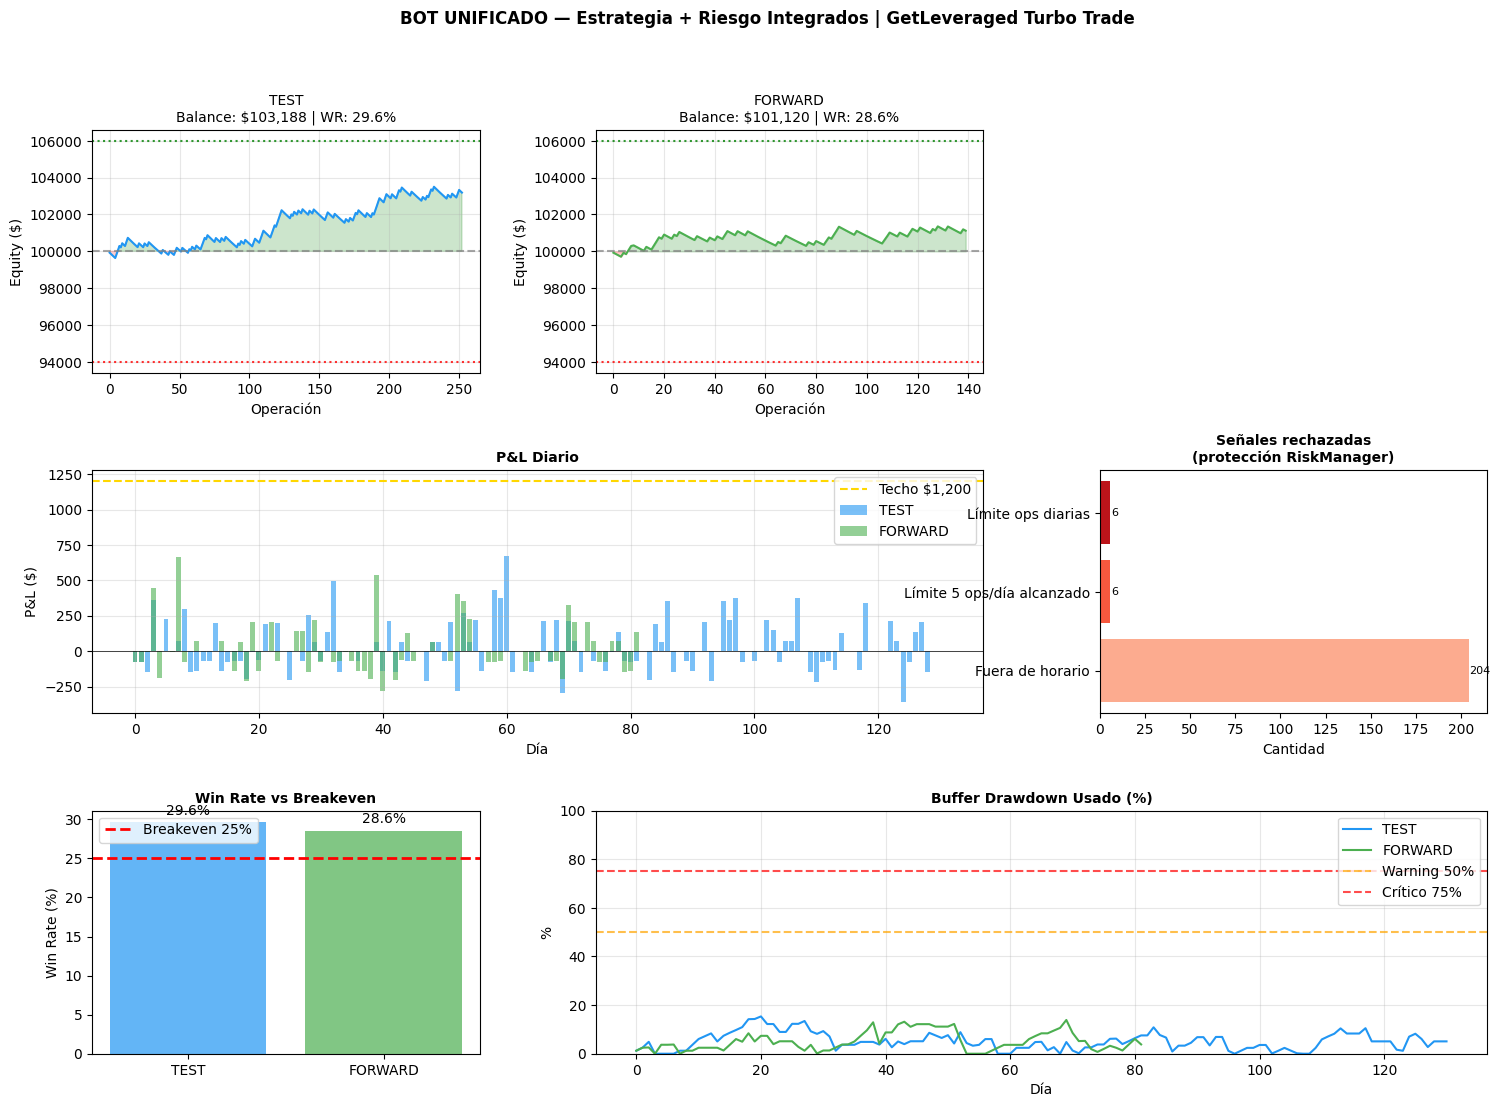


✅ Gráfico guardado: backtest_unificado.png

   BACKTEST COMPLETADO


In [ ]:
# ============================================================
# BOT UNIFICADO — BACKTEST COMPLETO EN COLAB
# GetLeveraged Turbo Trade | CFD US500 M15
# ============================================================
# Ejecutar en Google Colab con datos_US500.csv
# ============================================================

!pip install statsmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from datetime import datetime, timedelta
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from statsmodels.stats.proportion import proportion_confint
import scipy.stats as stats

warnings.filterwarnings('ignore')

# ============================================================
# 1. CONFIGURACIÓN UNIFICADA
# ============================================================

CONFIG = {
    # ── Cuenta GetLeveraged Turbo Trade ──
    "initial_balance": 100_000,
    "daily_loss_limit_pct": 0.03,           # 3%
    "trailing_drawdown_pct": 0.06,          # 6%
    "profit_target_pct": 0.06,              # 6%
    "consistency_rule_pct": 0.20,           # 20%
    "min_trade_duration_minutes": 2,
    "max_leverage": 30,

    # ── Límites internos conservadores ──
    "internal_daily_risk_max": 1000,
    "daily_profit_ceiling": 1200,
    "daily_profit_ceiling_enabled": True,
    "max_trades_per_day": 5,
    "max_trades_per_day_enabled": True,

    # ── Riesgo por operación ──
    "max_risk_per_trade": 150,
    "min_risk_per_trade": 25,
    "min_signal_score": 45,

    # ── Horarios (Madrid) ──
    "trading_start_hour": 8,
    "trading_end_hour": 22,
    "us_open_start": 15.50,
    "us_open_end": 15.75,
    "filter_us_open": False,

    # ── Anti-sobreoperar ──
    "min_bars_between_entries": 2,
    "anti_consecutive_enabled": True,
    "max_positions": 1,

    # ── Estrategia Donchian + CCI + ML ──
    "donchian_period": 30,
    "sma_period": 200,
    "cci_period": 14,
    "cci_threshold": 100,
    "atr_period": 14,
    "sl_multiplier": 0.5,
    "tp_multiplier": 1.5,
    "ml_threshold": 0.45,
    "lookforward_bars": 30,
    "max_bars_in_trade": 32,            # 8 horas en M15

    # ── CFD US500 ──
    "point_value_per_lot": 1,
    "symbol": "US500",
    "timeframe": "M15",

    # ── Alertas ──
    "alert_threshold_warning": 0.50,
    "alert_threshold_critical": 0.75,

    # ── División temporal ──
    # ── División temporal ──
    "train_end_date": "2025-06-30",    # Entrenamiento: ~15 meses
    "test_end_date": "2025-12-31",     # Backtest: ~6 meses
    # Forward: enero 2026 - abril 2026 (~4 meses)


    # ── Modo ──
    "account_mode": "EVALUACION"
}

# Breakeven matemático
WR_BREAKEVEN = CONFIG["sl_multiplier"] / (CONFIG["sl_multiplier"] + CONFIG["tp_multiplier"]) * 100

print("=" * 65)
print("   BOT UNIFICADO — ESTRATEGIA + RIESGO INTEGRADOS")
print("=" * 65)
print(f"   Cuenta: ${CONFIG['initial_balance']:,} | DD: {CONFIG['trailing_drawdown_pct']*100:.0f}% | Objetivo: {CONFIG['profit_target_pct']*100:.0f}%")
print(f"   Estrategia: Donchian{CONFIG['donchian_period']} + SMA{CONFIG['sma_period']} + CCI>{CONFIG['cci_threshold']}")
print(f"   SL: {CONFIG['sl_multiplier']}xATR | TP: {CONFIG['tp_multiplier']}xATR | Ratio: {CONFIG['tp_multiplier']/CONFIG['sl_multiplier']:.0f}:1")
print(f"   Breakeven WR: {WR_BREAKEVEN:.1f}%")
print("=" * 65)


# ============================================================
# 2. CLASES DE RIESGO (del módulo original)
# ============================================================

class ConsistencyTracker:
    """Monitorea la regla del 20%: mejor día ≤ 20% del profit total."""

    def __init__(self, config: dict):
        self.threshold = config.get("consistency_rule_pct", 0.20)
        self.daily_profits = {}

    def update_day(self, fecha, pnl: float) -> None:
        if pnl > 0:
            self.daily_profits[fecha] = pnl

    def get_score(self) -> dict:
        if not self.daily_profits:
            return {"best_day_pnl": 0, "total_profit": 0, "consistency_pct": 0, "is_compliant": True}

        total = sum(self.daily_profits.values())
        if total <= 0:
            return {"best_day_pnl": 0, "total_profit": 0, "consistency_pct": 0, "is_compliant": True}

        best_date = max(self.daily_profits, key=self.daily_profits.get)
        best_pnl = self.daily_profits[best_date]
        pct = (best_pnl / total) * 100

        return {
            "best_day_pnl": round(best_pnl, 2),
            "best_day_date": best_date,
            "total_profit": round(total, 2),
            "consistency_pct": round(pct, 2),
            "is_compliant": pct <= (self.threshold * 100)
        }

    def get_summary(self) -> dict:
        score = self.get_score()
        return {
            "score_pct": score["consistency_pct"],
            "limite_pct": self.threshold * 100,
            "cumple": score["is_compliant"]
        }


class AntiConsecutiveTracker:
    """Evita entradas en velas consecutivas."""

    def __init__(self, config: dict):
        self.min_bars = config.get("min_bars_between_entries", 2)
        self.enabled = config.get("anti_consecutive_enabled", True)
        self.last_entry_bar_index = None

    def register_entry(self, bar_index: int) -> None:
        self.last_entry_bar_index = bar_index

    def can_enter(self, current_bar_index: int) -> Tuple[bool, str]:
        if not self.enabled:
            return True, "Filtro desactivado"
        if self.last_entry_bar_index is None:
            return True, "Primera entrada"

        bars_since = current_bar_index - self.last_entry_bar_index
        if bars_since < self.min_bars:
            return False, f"Anti-consecutivo: {bars_since} velas (mín: {self.min_bars})"
        return True, "OK"

    def reset_day(self) -> None:
        self.last_entry_bar_index = None


class RiskManager:
    """Gestor de riesgo completo para cuentas de fondeo."""

    def __init__(self, config: dict):
        self.config = config
        self.initial_balance = config["initial_balance"]
        self.balance = config["initial_balance"]
        self.equity = config["initial_balance"]
        self.max_equity = config["initial_balance"]

        self.current_day = None
        self.day_start_balance = config["initial_balance"]
        self.daily_pnl = 0
        self.daily_risk_used = 0
        self.daily_trades = []

        self.blocked_today = False
        self.blocked_total = False
        self.block_reason = ""
        self.ceiling_reached_today = False
        self.max_trades_reached_today = False
        self.profit_target_reached = False

        self.daily_log = []
        self.trade_log = []
        self.rejection_log = defaultdict(int)

        self.consistency = ConsistencyTracker(config)
        self.anti_consecutive = AntiConsecutiveTracker(config)

    def update_day(self, timestamp: datetime) -> None:
        day = timestamp.date()
        if self.current_day != day:
            if self.current_day is not None:
                self._close_day()

            self.current_day = day
            self.day_start_balance = self.balance
            self.daily_pnl = 0
            self.daily_risk_used = 0
            self.daily_trades = []
            self.blocked_today = False
            self.ceiling_reached_today = False
            self.max_trades_reached_today = False
            self.anti_consecutive.reset_day()

    def _close_day(self) -> None:
        summary = self._get_daily_summary_internal()
        self.daily_log.append(summary)
        if summary["pnl_dia"] > 0:
            self.consistency.update_day(summary["fecha"], summary["pnl_dia"])

    def _get_daily_summary_internal(self) -> dict:
        floor = self.get_drawdown_floor()
        total = len(self.daily_trades)
        wins = sum(1 for t in self.daily_trades if t["pnl"] > 0)
        return {
            "fecha": self.current_day,
            "balance_inicio": round(self.day_start_balance, 2),
            "balance": round(self.balance, 2),
            "equity": round(self.equity, 2),
            "equity_max": round(self.max_equity, 2),
            "limite_drawdown": round(floor, 2),
            "distancia_drawdown": round(self.equity - floor, 2),
            "buffer_usado_pct": round(self.get_buffer_used_pct(), 2),
            "pnl_dia": round(self.daily_pnl, 2),
            "rentabilidad_dia_pct": round((self.daily_pnl / self.day_start_balance) * 100, 4) if self.day_start_balance > 0 else 0,
            "total_operaciones": total,
            "operaciones_ganadoras": wins,
            "win_rate": round((wins / total * 100) if total > 0 else 0, 2),
            "modo": self.get_risk_mode(),
            "bloqueado_hoy": self.blocked_today,
            "techo_alcanzado": self.ceiling_reached_today,
            "limite_ops_alcanzado": self.max_trades_reached_today
        }

    def update_equity(self, equity: float) -> None:
        self.equity = equity
        if equity > self.max_equity:
            self.max_equity = equity
            self._check_profit_target()

    def _check_profit_target(self) -> None:
        target = self.initial_balance * (1 + self.config["profit_target_pct"])
        if self.max_equity >= target:
            self.profit_target_reached = True

    def get_drawdown_floor(self) -> float:
        if self.profit_target_reached:
            return self.initial_balance
        return self.max_equity * (1 - self.config["trailing_drawdown_pct"])

    def get_buffer_ratio(self) -> float:
        floor = self.get_drawdown_floor()
        total_buffer = self.max_equity - floor
        current_buffer = self.equity - floor
        if total_buffer <= 0:
            return 0
        return max(0, min(current_buffer / total_buffer, 1))

    def get_buffer_used_pct(self) -> float:
        return (1 - self.get_buffer_ratio()) * 100

    def get_risk_mode(self) -> str:
        buffer = self.get_buffer_ratio()
        if buffer > 0.70:
            return "NORMAL"
        elif buffer > 0.40:
            return "CONSERVADOR"
        elif buffer > 0.20:
            return "SUPERVIVENCIA"
        else:
            return "BLOQUEADO"

    def check_trailing_drawdown(self) -> Tuple[bool, str]:
        floor = self.get_drawdown_floor()
        if self.equity <= floor:
            self.blocked_total = True
            self.block_reason = "Drawdown trailing alcanzado"
            return False, self.block_reason
        return True, "OK"

    def check_daily_loss(self) -> Tuple[bool, str]:
        official_limit = self.day_start_balance * self.config["daily_loss_limit_pct"]
        internal_limit = self.config["internal_daily_risk_max"]

        if self.daily_pnl <= -official_limit:
            self.blocked_today = True
            return False, "Pérdida diaria 3% alcanzada"
        if self.daily_pnl <= -internal_limit:
            self.blocked_today = True
            return False, "Límite interno diario alcanzado"
        return True, "OK"

    def check_daily_ceiling(self) -> Tuple[bool, str]:
        if not self.config.get("daily_profit_ceiling_enabled", True):
            return True, "OK"
        ceiling = self.config.get("daily_profit_ceiling", 1200)
        if self.daily_pnl >= ceiling:
            self.ceiling_reached_today = True
            return False, f"Techo diario ${ceiling} alcanzado"
        return True, "OK"

    def check_max_trades_per_day(self) -> Tuple[bool, str]:
        if not self.config.get("max_trades_per_day_enabled", True):
            return True, "OK"
        max_trades = self.config.get("max_trades_per_day", 5)
        if len(self.daily_trades) >= max_trades:
            self.max_trades_reached_today = True
            return False, f"Límite {max_trades} ops/día alcanzado"
        return True, "OK"

    def check_trading_hours(self, timestamp: datetime) -> Tuple[bool, str]:
        hour = timestamp.hour
        minute = timestamp.minute
        hora_decimal = hour + minute / 60

        if hour < self.config["trading_start_hour"] or hour >= self.config["trading_end_hour"]:
            return False, "Fuera de horario"

        if self.config.get("filter_us_open", True):
            us_start = self.config.get("us_open_start", 15.50)
            us_end = self.config.get("us_open_end", 15.75)
            if us_start <= hora_decimal < us_end:
                return False, "Filtro apertura US"
        return True, "OK"

    def check_anti_consecutive(self, bar_index: int) -> Tuple[bool, str]:
        return self.anti_consecutive.can_enter(bar_index)

    def calculate_risk_smooth(self, signal_score: float) -> float:
        if signal_score < self.config["min_signal_score"]:
            return 0

        buffer = self.get_buffer_ratio()
        if buffer <= 0.20:
            return 0

        max_risk = self.config["max_risk_per_trade"]
        min_risk = self.config["min_risk_per_trade"]

        scale = (buffer - 0.20) / 0.80
        base_risk = min_risk + (max_risk - min_risk) * scale

        if signal_score >= 80:
            multiplier = 1.0
        elif signal_score >= 65:
            multiplier = 0.75
        else:
            multiplier = 0.50

        risk = base_risk * multiplier
        remaining = self._get_daily_budget() - self.daily_risk_used
        risk = min(risk, remaining)

        if risk < self.config["min_risk_per_trade"]:
            return 0
        return round(risk, 2)

    def _get_daily_budget(self) -> float:
        mode = self.get_risk_mode()
        budgets = {"NORMAL": 1000, "CONSERVADOR": 600, "SUPERVIVENCIA": 250, "BLOQUEADO": 0}
        budget = budgets.get(mode, 0)

        if self.config.get("daily_profit_ceiling_enabled", True):
            ceiling = self.config.get("daily_profit_ceiling", 1200)
            remaining = ceiling - self.daily_pnl
            if remaining < budget:
                budget = max(0, remaining * 0.5)
        return budget

    def calculate_lot_size(self, risk_usd: float, stop_loss_points: float) -> float:
        if stop_loss_points <= 0 or risk_usd <= 0:
            return 0
        return round(risk_usd / (stop_loss_points * self.config["point_value_per_lot"]), 4)

    def evaluate_trade(self, signal: dict, bar_index: int) -> dict:
        timestamp = signal["timestamp"]
        direction = signal["signal"]
        score = signal["signal_score"]
        entry_price = signal["entry_price"]
        sl_points = signal["stop_loss_points"]

        self.update_day(timestamp)

        base = {"allowed": False, "reason": "", "risk_usd": 0, "lot_size": 0, "mode": self.get_risk_mode()}

        if direction == 0:
            return {**base, "reason": "Sin señal"}

        if self.blocked_total:
            self.rejection_log["Cuenta bloqueada"] += 1
            return {**base, "reason": "Cuenta bloqueada"}

        if self.blocked_today:
            self.rejection_log["Bloqueado hoy"] += 1
            return {**base, "reason": "Bloqueado hoy"}

        if self.ceiling_reached_today:
            self.rejection_log["Techo diario"] += 1
            return {**base, "reason": "Techo diario alcanzado"}

        if self.max_trades_reached_today:
            self.rejection_log["Límite ops diarias"] += 1
            return {**base, "reason": "Límite ops diarias"}

        # Verificaciones en cadena
        checks = [
            ("Horario", self.check_trading_hours(timestamp)),
            ("Drawdown", self.check_trailing_drawdown()),
            ("Pérdida diaria", self.check_daily_loss()),
            ("Techo diario", self.check_daily_ceiling()),
            ("Límite ops", self.check_max_trades_per_day()),
            ("Anti-consecutivo", self.check_anti_consecutive(bar_index)),
        ]

        for name, (ok, reason) in checks:
            if not ok:
                self.rejection_log[reason] += 1
                return {**base, "reason": reason}

        risk_usd = self.calculate_risk_smooth(score)
        if risk_usd <= 0:
            self.rejection_log["Riesgo cero (score bajo)"] += 1
            return {**base, "reason": "Riesgo cero (score bajo)"}

        lot_size = self.calculate_lot_size(risk_usd, sl_points)
        if lot_size <= 0:
            self.rejection_log["Lote inválido"] += 1
            return {**base, "reason": "Lote inválido"}

        return {
            "allowed": True,
            "reason": "Autorizada",
            "risk_usd": risk_usd,
            "lot_size": lot_size,
            "mode": self.get_risk_mode()
        }

    def confirm_trade_open(self, risk_usd: float, bar_index: int) -> None:
        self.daily_risk_used += risk_usd
        self.anti_consecutive.register_entry(bar_index)

    def register_trade_result(self, open_time, close_time, pnl: float, details: dict) -> None:
        self.balance += pnl
        self.equity = self.balance
        if self.equity > self.max_equity:
            self.max_equity = self.equity
            self._check_profit_target()

        self.daily_pnl += pnl

        record = {
            "open_time": open_time,
            "close_time": close_time,
            "pnl": round(pnl, 2),
            "balance": round(self.balance, 2),
            "mode": self.get_risk_mode(),
            **details
        }
        self.trade_log.append(record)
        self.daily_trades.append(record)

        self.check_trailing_drawdown()
        self.check_daily_loss()
        self.check_daily_ceiling()

    def get_final_metrics(self) -> dict:
        if self.current_day is not None:
            self._close_day()

        total = len(self.trade_log)
        wins = sum(1 for t in self.trade_log if t["pnl"] > 0)
        total_pnl = sum(t["pnl"] for t in self.trade_log)

        gains = sum(t["pnl"] for t in self.trade_log if t["pnl"] > 0)
        losses = abs(sum(t["pnl"] for t in self.trade_log if t["pnl"] < 0))
        pf = gains / losses if losses > 0 else (float('inf') if gains > 0 else 0)

        return {
            "balance_inicial": self.initial_balance,
            "balance_final": round(self.balance, 2),
            "rentabilidad_pct": round(((self.balance / self.initial_balance) - 1) * 100, 2),
            "equity_maxima": round(self.max_equity, 2),
            "dd_floor_actual": round(self.get_drawdown_floor(), 2),
            "distancia_dd": round(self.balance - self.get_drawdown_floor(), 2),
            "estado": self.get_risk_mode(),
            "bloqueado": self.blocked_total,
            "objetivo_alcanzado": self.profit_target_reached,
            "total_operaciones": total,
            "operaciones_ganadoras": wins,
            "win_rate_global": round((wins / total * 100) if total > 0 else 0, 2),
            "profit_factor": round(pf, 3) if pf != float('inf') else "∞",
            "pnl_total": round(total_pnl, 2),
            "dias_operados": len(self.daily_log),
            "consistencia": self.consistency.get_summary(),
            "rechazos": dict(self.rejection_log)
        }


# ============================================================
# 3. GENERADOR DE SEÑALES (Estrategia)
# ============================================================

class SignalGenerator:
    """Estrategia Donchian + CCI + ML."""

    def __init__(self, config: dict):
        self.config = config
        self.model = None
        self.scaler = None
        self.features = ['cci', 'dist_upper', 'dist_lower', 'dist_sma', 'atr_rel']
        self.is_trained = False

    def calculate_indicators(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        # SMA
        df['sma_200'] = df['close'].rolling(self.config['sma_period']).mean()

        # Donchian
        don_p = self.config['donchian_period']
        df['donchian_upper'] = df['high'].rolling(don_p).max().shift(1)
        df['donchian_lower'] = df['low'].rolling(don_p).min().shift(1)

        # ATR
        hl = df['high'] - df['low']
        hc = (df['high'] - df['close'].shift(1)).abs()
        lc = (df['low'] - df['close'].shift(1)).abs()
        tr = pd.concat([hl, hc, lc], axis=1).max(axis=1)
        df['atr'] = tr.ewm(alpha=1/self.config['atr_period'], adjust=False).mean()

        # CCI
        cci_p = self.config['cci_period']
        tp = (df['high'] + df['low'] + df['close']) / 3
        sma_tp = tp.rolling(cci_p).mean()
        mean_dev = tp.rolling(cci_p).apply(lambda x: np.abs(x - x.mean()).mean(), raw=True)
        df['cci'] = (tp - sma_tp) / (0.015 * mean_dev)

        # Features ML
        df['dist_upper'] = (df['donchian_upper'] - df['close']) / df['close']
        df['dist_lower'] = (df['close'] - df['donchian_lower']) / df['close']
        df['dist_sma'] = (df['close'] - df['sma_200']) / df['sma_200']
        df['atr_rel'] = df['atr'] / df['close']

        # SL/TP en puntos
        df['stop_loss_points'] = df['atr'] * self.config['sl_multiplier']
        df['take_profit_points'] = df['atr'] * self.config['tp_multiplier']

        return df.dropna().reset_index(drop=True)

    def generate_labels(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        look = self.config['lookforward_bars']
        sl_mult = self.config['sl_multiplier']
        tp_mult = self.config['tp_multiplier']

        closes = df['close'].values
        highs = df['high'].values
        lows = df['low'].values
        opens = df['open'].values
        atrs = df['atr'].values
        n = len(df)

        labels = np.zeros(n, dtype=int)

        for i in range(n - look):
            entry = closes[i]
            atr = atrs[i]
            tp_level = entry + atr * tp_mult
            sl_level = entry - atr * sl_mult

            for j in range(i + 1, min(i + look + 1, n)):
                hit_tp = highs[j] >= tp_level
                hit_sl = lows[j] <= sl_level

                if hit_tp and not hit_sl:
                    labels[i] = 1
                    break
                elif hit_sl and not hit_tp:
                    break
                elif hit_tp and hit_sl:
                    labels[i] = 1 if abs(opens[j] - tp_level) < abs(opens[j] - sl_level) else 0
                    break

        df['label'] = labels
        return df

    def train_model(self, df_train: pd.DataFrame) -> float:
        self.scaler = StandardScaler()
        X = df_train[self.features].values
        y = df_train['label'].values

        self.scaler.fit(X)
        X_scaled = self.scaler.transform(X)

        self.model = LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced')
        self.model.fit(X_scaled, y)
        self.is_trained = True

        # AUC en training
        probs = self.model.predict_proba(X_scaled)[:, 1]
        return roc_auc_score(y, probs)

    def evaluate_bar(self, row: pd.Series) -> dict:
        result = {
            'signal': 0,
            'signal_score': 0,
            'entry_price': row['close'],
            'stop_loss_points': row['stop_loss_points'],
            'take_profit_points': row['take_profit_points'],
            'ml_probability': 0.0
        }

        # Condiciones técnicas (solo LONG)
        cond_donchian = row['close'] > row['donchian_upper']
        cond_trend = row['close'] > row['sma_200']
        cond_momentum = row['cci'] > self.config['cci_threshold']

        if not (cond_donchian and cond_trend and cond_momentum):
            return result

        if not self.is_trained:
            result['signal'] = 1
            result['signal_score'] = 60
            return result

        try:
            X = row[self.features].values.reshape(1, -1)
            X_scaled = self.scaler.transform(X)
            prob = self.model.predict_proba(X_scaled)[0][1]
        except Exception:
            return result

        result['ml_probability'] = prob
        result['signal'] = 1

        # Convertir prob (0.5-1.0) a score (50-100)
        if prob >= self.config['ml_threshold']:
            result['signal_score'] = int(50 + (prob - 0.5) * 100)
        else:
            result['signal_score'] = int(prob * 100)

        return result


# ============================================================
# 4. ORQUESTADOR
# ============================================================

class TradingOrchestrator:
    """Une estrategia + riesgo. El RiskManager siempre decide."""

    def __init__(self, config: dict, risk_manager: RiskManager, signal_generator: SignalGenerator):
        self.config = config
        self.rm = risk_manager
        self.sg = signal_generator
        self.position = None
        self.execution_log = []

    def process_bar(self, row: pd.Series, bar_index: int) -> dict:
        timestamp = row['time']
        self.rm.update_day(timestamp)

        # Gestionar posición abierta
        if self.position is not None:
            exit_result = self._check_exit(row, bar_index)
            if exit_result['closed']:
                return {'action': 'CLOSE', 'details': exit_result}

        # Evaluar nueva entrada
        if self.position is None:
            entry_result = self._evaluate_entry(row, bar_index)
            if entry_result['executed']:
                return {'action': 'OPEN', 'details': entry_result}

        return {'action': 'HOLD', 'details': {}}

    def _evaluate_entry(self, row: pd.Series, bar_index: int) -> dict:
        signal_data = self.sg.evaluate_bar(row)

        if signal_data['signal'] == 0:
            return {'executed': False, 'reason': 'Sin señal técnica'}

        trade_request = {
            'timestamp': row['time'],
            'signal': signal_data['signal'],
            'signal_score': signal_data['signal_score'],
            'entry_price': signal_data['entry_price'],
            'stop_loss_points': signal_data['stop_loss_points']
        }

        decision = self.rm.evaluate_trade(trade_request, bar_index)

        if not decision['allowed']:
            return {
                'executed': False,
                'reason': decision['reason'],
                'signal_score': signal_data['signal_score'],
                'ml_prob': signal_data['ml_probability']
            }

        # Abrir posición
        self.position = {
            'open_time': row['time'],
            'open_bar': bar_index,
            'signal': signal_data['signal'],
            'entry_price': signal_data['entry_price'],
            'lot_size': decision['lot_size'],
            'risk_usd': decision['risk_usd'],
            'stop_loss': signal_data['entry_price'] - signal_data['stop_loss_points'],
            'take_profit': signal_data['entry_price'] + signal_data['take_profit_points']
        }

        self.rm.confirm_trade_open(decision['risk_usd'], bar_index)

        return {
            'executed': True,
            'entry_price': signal_data['entry_price'],
            'lot_size': decision['lot_size'],
            'risk_usd': decision['risk_usd'],
            'mode': decision['mode'],
            'signal_score': signal_data['signal_score'],
            'ml_prob': signal_data['ml_probability']
        }

    def _check_exit(self, row: pd.Series, bar_index: int) -> dict:
        if self.position is None:
            return {'closed': False}

        pos = self.position
        entry = pos['entry_price']
        tp = pos['take_profit']
        sl = pos['stop_loss']
        lot = pos['lot_size']
        pv = self.config['point_value_per_lot']

        exit_price = None
        exit_reason = None

        # Check TP
        if row['high'] >= tp:
            exit_price = tp
            exit_reason = 'TP'

        # Check SL
        if exit_price is None and row['low'] <= sl:
            exit_price = sl
            exit_reason = 'SL'

        # Check tiempo máximo
        bars_in_trade = bar_index - pos['open_bar']
        if exit_price is None and bars_in_trade >= self.config.get('max_bars_in_trade', 32):
            exit_price = row['close']
            exit_reason = 'TIEMPO'

        if exit_price is None:
            return {'closed': False}

        pnl = (exit_price - entry) * lot * pv

        self.rm.register_trade_result(
            pos['open_time'], row['time'], pnl,
            {'entry_price': entry, 'exit_price': exit_price, 'exit_reason': exit_reason, 'lot_size': lot}
        )

        self.execution_log.append({
            'open_time': pos['open_time'],
            'close_time': row['time'],
            'entry_price': entry,
            'exit_price': exit_price,
            'exit_reason': exit_reason,
            'pnl': pnl,
            'lot_size': lot,
            'bars_in_trade': bars_in_trade
        })

        self.position = None

        return {
            'closed': True,
            'exit_reason': exit_reason,
            'exit_price': exit_price,
            'pnl': pnl,
            'balance': self.rm.balance
        }


# ============================================================
# 5. BACKTEST COMPLETO
# ============================================================

def run_backtest(df: pd.DataFrame, config: dict, period_name: str) -> dict:
    """Ejecuta backtest sobre un período."""
    rm = RiskManager(config)
    sg = SignalGenerator(config)
    sg.model = global_model
    sg.scaler = global_scaler
    sg.is_trained = True

    orchestrator = TradingOrchestrator(config, rm, sg)

    for bar_idx, (_, row) in enumerate(df.iterrows()):
        orchestrator.process_bar(row, bar_idx)
        if rm.blocked_total:
            break

    return {
        'metrics': rm.get_final_metrics(),
        'daily': pd.DataFrame(rm.daily_log),
        'trades': pd.DataFrame(rm.trade_log),
        'executions': orchestrator.execution_log
    }


# ============================================================
# 6. EJECUCIÓN PRINCIPAL
# ============================================================

print("\n[1/6] Cargando datos...")
df = pd.read_csv('datos_US500.csv')
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)
print(f"   Cargadas {len(df):,} velas | {df['time'].min().date()} a {df['time'].max().date()}")

print("\n[2/6] Calculando indicadores...")
sg = SignalGenerator(CONFIG)
df = sg.calculate_indicators(df)
df = sg.generate_labels(df)
print(f"   Dataset procesado: {len(df):,} velas")

print("\n[3/6] Dividiendo datos...")
train_end = CONFIG['train_end_date']
test_end = CONFIG['test_end_date']

df_train = df[df['time'] <= train_end].copy()
df_test = df[(df['time'] > train_end) & (df['time'] <= test_end)].copy()
df_forward = df[df['time'] > test_end].copy()

print(f"   Entrenamiento: {len(df_train):,} velas hasta {train_end}")
print(f"   Test: {len(df_test):,} velas")
print(f"   Forward: {len(df_forward):,} velas")

print("\n[4/6] Entrenando modelo ML...")
auc_train = sg.train_model(df_train)
global_model = sg.model
global_scaler = sg.scaler
print(f"   AUC entrenamiento: {auc_train:.4f}")

print("\n[5/6] Ejecutando backtests...")

results = {}

if len(df_test) > 0:
    print("\n   → TEST...")
    results['TEST'] = run_backtest(df_test.reset_index(drop=True), CONFIG, 'TEST')
    m = results['TEST']['metrics']
    print(f"      Balance: ${m['balance_final']:,.2f} | Rentab: {m['rentabilidad_pct']:+.2f}%")
    print(f"      Ops: {m['total_operaciones']} | WR: {m['win_rate_global']:.1f}% | PF: {m['profit_factor']}")

if len(df_forward) > 0:
    print("\n   → FORWARD...")
    results['FORWARD'] = run_backtest(df_forward.reset_index(drop=True), CONFIG, 'FORWARD')
    m = results['FORWARD']['metrics']
    print(f"      Balance: ${m['balance_final']:,.2f} | Rentab: {m['rentabilidad_pct']:+.2f}%")
    print(f"      Ops: {m['total_operaciones']} | WR: {m['win_rate_global']:.1f}% | PF: {m['profit_factor']}")


# ============================================================
# 7. INFORME FINAL
# ============================================================

print("\n\n" + "=" * 65)
print("   INFORME FINAL — BOT UNIFICADO")
print("=" * 65)

for period, data in results.items():
    m = data['metrics']
    c = m['consistencia']

    print(f"\n{'─'*65}")
    print(f"  {period}")
    print(f"{'─'*65}")

    print(f"\n  RENDIMIENTO")
    print(f"  {'Balance inicial':<30}: ${m['balance_inicial']:,.2f}")
    print(f"  {'Balance final':<30}: ${m['balance_final']:,.2f}")
    print(f"  {'Rentabilidad':<30}: {m['rentabilidad_pct']:+.2f}%")
    print(f"  {'Objetivo alcanzado':<30}: {'✅' if m['objetivo_alcanzado'] else '❌'}")

    print(f"\n  OPERACIONES")
    print(f"  {'Total':<30}: {m['total_operaciones']}")
    print(f"  {'Ganadoras':<30}: {m['operaciones_ganadoras']}")
    print(f"  {'Win rate':<30}: {m['win_rate_global']:.1f}% (breakeven: {WR_BREAKEVEN:.1f}%)")
    print(f"  {'Profit factor':<30}: {m['profit_factor']}")

    print(f"\n  RIESGO")
    print(f"  {'Equity máxima':<30}: ${m['equity_maxima']:,.2f}")
    print(f"  {'Floor drawdown':<30}: ${m['dd_floor_actual']:,.2f}")
    print(f"  {'Distancia al floor':<30}: ${m['distancia_dd']:,.2f}")
    print(f"  {'Bloqueado':<30}: {'⛔' if m['bloqueado'] else '✅'}")

    print(f"\n  CONSISTENCIA (regla 20%)")
    print(f"  {'Score':<30}: {c['score_pct']:.1f}% (máx {c['limite_pct']:.0f}%)")
    print(f"  {'Cumple':<30}: {'✅' if c['cumple'] else '⚠️'}")

    print(f"\n  RECHAZOS (protección del RiskManager)")
    for reason, count in m['rechazos'].items():
        print(f"  {'  ' + reason:<30}: {count}")


# ============================================================
# 8. VISUALIZACIONES
# ============================================================

print("\n\n[6/6] Generando gráficos...")

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)

# Curvas de equity
for idx, (period, data) in enumerate(results.items()):
    ax = fig.add_subplot(gs[0, idx])
    df_trades = data['trades']
    if not df_trades.empty:
        equity = CONFIG['initial_balance'] + df_trades['pnl'].cumsum()
        ax.plot(equity.values, linewidth=1.5, color='#2196F3' if period == 'TEST' else '#4CAF50')
        ax.axhline(CONFIG['initial_balance'], color='gray', linestyle='--', alpha=0.7)
        ax.axhline(CONFIG['initial_balance'] * 1.06, color='green', linestyle=':', alpha=0.8)
        ax.axhline(CONFIG['initial_balance'] * 0.94, color='red', linestyle=':', alpha=0.8)
        ax.fill_between(range(len(equity)), CONFIG['initial_balance'], equity.values,
                        where=equity.values >= CONFIG['initial_balance'], alpha=0.2, color='green')
        ax.fill_between(range(len(equity)), CONFIG['initial_balance'], equity.values,
                        where=equity.values < CONFIG['initial_balance'], alpha=0.2, color='red')
    m = data['metrics']
    ax.set_title(f"{period}\nBalance: ${m['balance_final']:,.0f} | WR: {m['win_rate_global']:.1f}%", fontsize=10)
    ax.set_xlabel('Operación')
    ax.set_ylabel('Equity ($)')
    ax.grid(True, alpha=0.3)

# P&L diario
ax_daily = fig.add_subplot(gs[1, :2])
for period, data in results.items():
    df_daily = data['daily']
    if not df_daily.empty:
        color = '#2196F3' if period == 'TEST' else '#4CAF50'
        ax_daily.bar(range(len(df_daily)), df_daily['pnl_dia'],
                     alpha=0.6, label=period, color=color)
ax_daily.axhline(0, color='black', linewidth=0.5)
ax_daily.axhline(CONFIG['daily_profit_ceiling'], color='gold', linestyle='--', label='Techo $1,200')
ax_daily.set_title('P&L Diario', fontsize=10, fontweight='bold')
ax_daily.set_xlabel('Día')
ax_daily.set_ylabel('P&L ($)')
ax_daily.legend()
ax_daily.grid(True, alpha=0.3)

# Rechazos
ax_rej = fig.add_subplot(gs[1, 2])
all_rejections = defaultdict(int)
for data in results.values():
    for reason, count in data['metrics']['rechazos'].items():
        all_rejections[reason] += count

if all_rejections:
    reasons = list(all_rejections.keys())
    counts = list(all_rejections.values())
    colors = plt.cm.Reds(np.linspace(0.3, 0.8, len(reasons)))
    bars = ax_rej.barh(reasons, counts, color=colors)
    for bar, count in zip(bars, counts):
        ax_rej.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                    str(count), va='center', fontsize=8)
ax_rej.set_title('Señales rechazadas\n(protección RiskManager)', fontsize=10, fontweight='bold')
ax_rej.set_xlabel('Cantidad')

# Comparativa WR vs Breakeven
ax_wr = fig.add_subplot(gs[2, 0])
periods = list(results.keys())
wrs = [results[p]['metrics']['win_rate_global'] for p in periods]
colors = ['#2196F3', '#4CAF50'][:len(periods)]
ax_wr.bar(periods, wrs, color=colors, alpha=0.7)
ax_wr.axhline(WR_BREAKEVEN, color='red', linestyle='--', linewidth=2, label=f'Breakeven {WR_BREAKEVEN:.0f}%')
ax_wr.set_ylabel('Win Rate (%)')
ax_wr.set_title('Win Rate vs Breakeven', fontsize=10, fontweight='bold')
ax_wr.legend()
for i, wr in enumerate(wrs):
    ax_wr.text(i, wr + 1, f'{wr:.1f}%', ha='center', fontsize=10)

# Buffer usado por día
ax_buf = fig.add_subplot(gs[2, 1:])
for period, data in results.items():
    df_daily = data['daily']
    if not df_daily.empty:
        color = '#2196F3' if period == 'TEST' else '#4CAF50'
        ax_buf.plot(df_daily['buffer_usado_pct'].values, label=period, color=color, linewidth=1.5)
ax_buf.axhline(50, color='orange', linestyle='--', alpha=0.7, label='Warning 50%')
ax_buf.axhline(75, color='red', linestyle='--', alpha=0.7, label='Crítico 75%')
ax_buf.set_ylim(0, 100)
ax_buf.set_title('Buffer Drawdown Usado (%)', fontsize=10, fontweight='bold')
ax_buf.set_xlabel('Día')
ax_buf.set_ylabel('%')
ax_buf.legend()
ax_buf.grid(True, alpha=0.3)

plt.suptitle('BOT UNIFICADO — Estrategia + Riesgo Integrados | GetLeveraged Turbo Trade',
             fontsize=12, fontweight='bold')
plt.savefig('backtest_unificado.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Gráfico guardado: backtest_unificado.png")
print("\n" + "=" * 65)
print("   BACKTEST COMPLETADO")
print("=" * 65)


   BOT UNIFICADO — ESTRATEGIA + RIESGO INTEGRADOS
   Cuenta: $100,000 | DD: 6% | Objetivo: 6%
   Estrategia: Donchian30 + SMA200 + CCI>100
   SL: 0.5xATR | TP: 1.5xATR | Ratio: 3:1
   Breakeven WR: 25.0%

[1/6] Cargando datos...
   Cargadas 49,967 velas | 2024-03-12 a 2026-04-24

[2/6] Calculando indicadores...
   Dataset procesado: 49,768 velas

[3/6] Dividiendo datos...
   Entrenamiento: 30,370 velas hasta 2025-06-30
   Test: 11,924 velas
   Forward: 7,474 velas

[4/6] Entrenando modelo ML...
   AUC entrenamiento: 0.5077

[5/6] Ejecutando backtests...

   → TEST...
      Balance: $104,056.17 | Rentab: +4.06%
      Ops: 258 | WR: 29.5% | PF: 1.239

   → FORWARD...
      Balance: $102,024.61 | Rentab: +2.02%
      Ops: 142 | WR: 29.6% | PF: 1.216


   INFORME FINAL — BOT UNIFICADO

─────────────────────────────────────────────────────────────────
  TEST
─────────────────────────────────────────────────────────────────

  RENDIMIENTO
  Balance inicial               : $100,000.00
  Balan

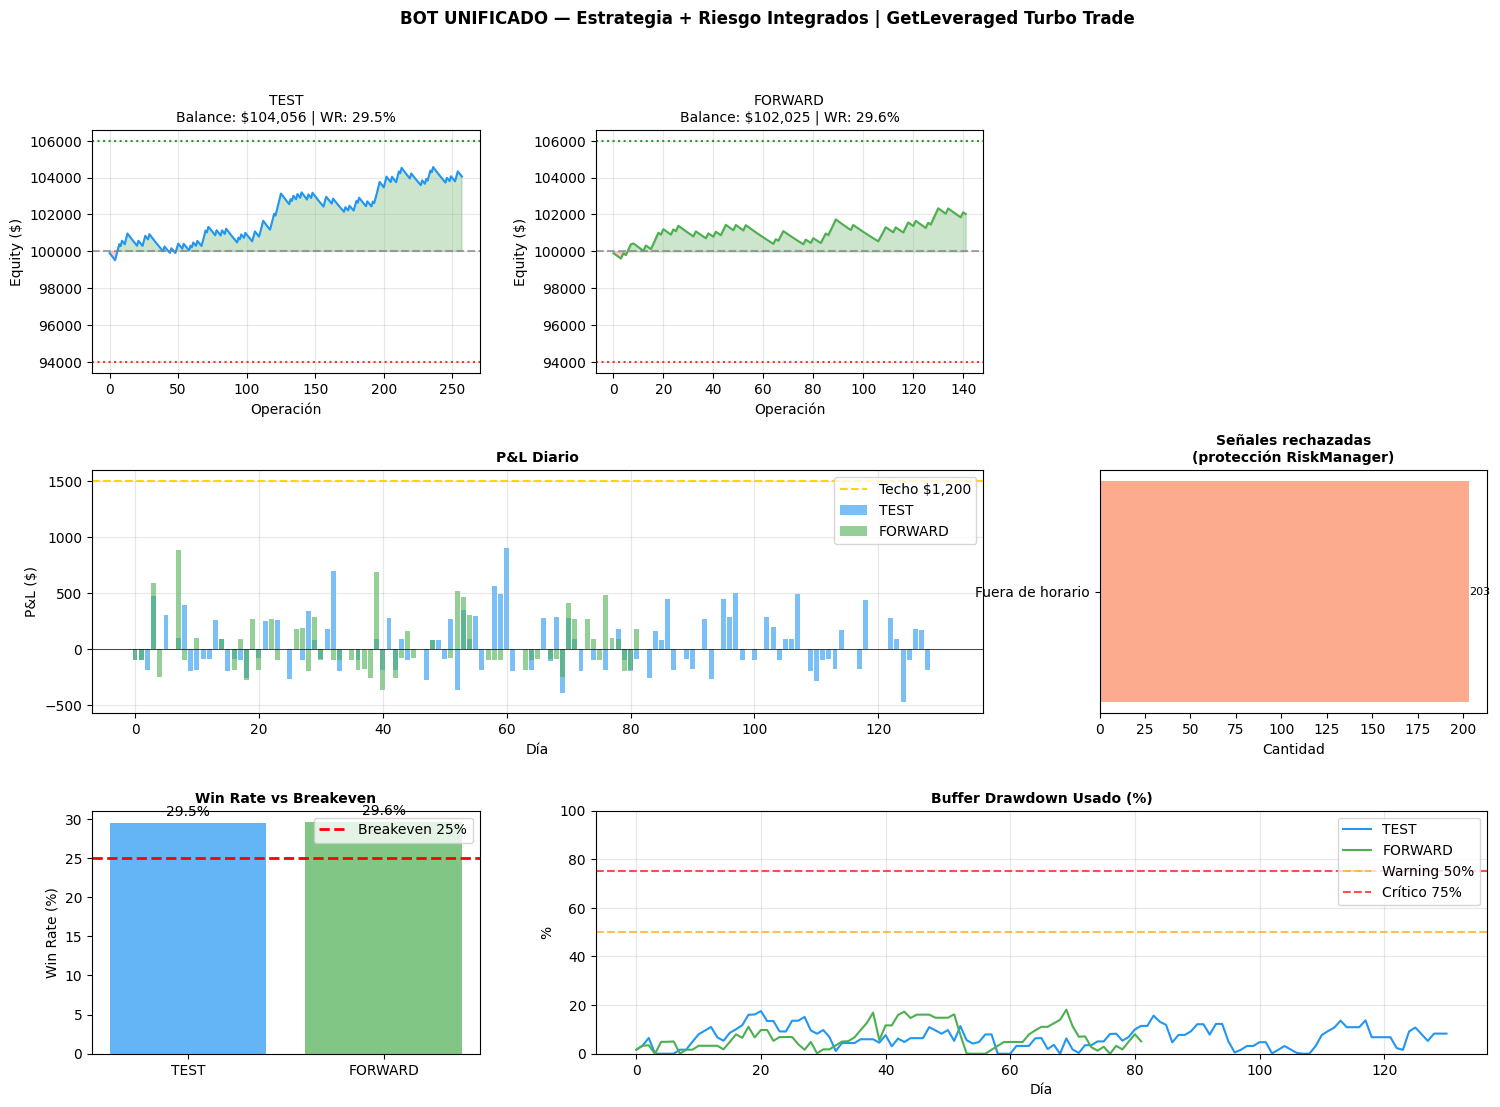


✅ Gráfico guardado: backtest_unificado.png

   BACKTEST COMPLETADO


In [ ]:
# ============================================================
# BOT UNIFICADO — BACKTEST COMPLETO EN COLAB
# GetLeveraged Turbo Trade | CFD US500 M15
# ============================================================
# Ejecutar en Google Colab con datos_US500.csv
# ============================================================

!pip install statsmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from datetime import datetime, timedelta
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from statsmodels.stats.proportion import proportion_confint
import scipy.stats as stats

warnings.filterwarnings('ignore')

# ============================================================
# 1. CONFIGURACIÓN UNIFICADA
# ============================================================

CONFIG = {
    # ── Cuenta GetLeveraged Turbo Trade ──
    "initial_balance": 100_000,
    "daily_loss_limit_pct": 0.03,           # 3%
    "trailing_drawdown_pct": 0.06,          # 6%
    "profit_target_pct": 0.06,              # 6%
    "consistency_rule_pct": 0.20,           # 20%
    "min_trade_duration_minutes": 2,
    "max_leverage": 30,

    # ── Límites internos conservadores ──
    "internal_daily_risk_max": 1500,
    "daily_profit_ceiling": 1500,
    "daily_profit_ceiling_enabled": True,
    "max_trades_per_day": 8,
    "max_trades_per_day_enabled": True,

    # ── Riesgo por operación ──
    "max_risk_per_trade": 200,
    "min_risk_per_trade": 40,
    "min_signal_score": 45,

    # ── Horarios (Madrid) ──
    "trading_start_hour": 8,
    "trading_end_hour": 22,
    "us_open_start": 15.50,
    "us_open_end": 15.75,
    "filter_us_open": False,

    # ── Anti-sobreoperar ──
    "min_bars_between_entries": 2,
    "anti_consecutive_enabled": True,
    "max_positions": 1,

    # ── Estrategia Donchian + CCI + ML ──
    "donchian_period": 30,
    "sma_period": 200,
    "cci_period": 14,
    "cci_threshold": 100,
    "atr_period": 14,
    "sl_multiplier": 0.5,
    "tp_multiplier": 1.5,
    "ml_threshold": 0.45,
    "lookforward_bars": 30,
    "max_bars_in_trade": 32,            # 8 horas en M15

    # ── CFD US500 ──
    "point_value_per_lot": 1,
    "symbol": "US500",
    "timeframe": "M15",

    # ── Alertas ──
    "alert_threshold_warning": 0.50,
    "alert_threshold_critical": 0.75,

    # ── División temporal ──
    # ── División temporal ──
    "train_end_date": "2025-06-30",    # Entrenamiento: ~15 meses
    "test_end_date": "2025-12-31",     # Backtest: ~6 meses
    # Forward: enero 2026 - abril 2026 (~4 meses)


    # ── Modo ──
    "account_mode": "EVALUACION"
}

# Breakeven matemático
WR_BREAKEVEN = CONFIG["sl_multiplier"] / (CONFIG["sl_multiplier"] + CONFIG["tp_multiplier"]) * 100

print("=" * 65)
print("   BOT UNIFICADO — ESTRATEGIA + RIESGO INTEGRADOS")
print("=" * 65)
print(f"   Cuenta: ${CONFIG['initial_balance']:,} | DD: {CONFIG['trailing_drawdown_pct']*100:.0f}% | Objetivo: {CONFIG['profit_target_pct']*100:.0f}%")
print(f"   Estrategia: Donchian{CONFIG['donchian_period']} + SMA{CONFIG['sma_period']} + CCI>{CONFIG['cci_threshold']}")
print(f"   SL: {CONFIG['sl_multiplier']}xATR | TP: {CONFIG['tp_multiplier']}xATR | Ratio: {CONFIG['tp_multiplier']/CONFIG['sl_multiplier']:.0f}:1")
print(f"   Breakeven WR: {WR_BREAKEVEN:.1f}%")
print("=" * 65)


# ============================================================
# 2. CLASES DE RIESGO (del módulo original)
# ============================================================

class ConsistencyTracker:
    """Monitorea la regla del 20%: mejor día ≤ 20% del profit total."""

    def __init__(self, config: dict):
        self.threshold = config.get("consistency_rule_pct", 0.20)
        self.daily_profits = {}

    def update_day(self, fecha, pnl: float) -> None:
        if pnl > 0:
            self.daily_profits[fecha] = pnl

    def get_score(self) -> dict:
        if not self.daily_profits:
            return {"best_day_pnl": 0, "total_profit": 0, "consistency_pct": 0, "is_compliant": True}

        total = sum(self.daily_profits.values())
        if total <= 0:
            return {"best_day_pnl": 0, "total_profit": 0, "consistency_pct": 0, "is_compliant": True}

        best_date = max(self.daily_profits, key=self.daily_profits.get)
        best_pnl = self.daily_profits[best_date]
        pct = (best_pnl / total) * 100

        return {
            "best_day_pnl": round(best_pnl, 2),
            "best_day_date": best_date,
            "total_profit": round(total, 2),
            "consistency_pct": round(pct, 2),
            "is_compliant": pct <= (self.threshold * 100)
        }

    def get_summary(self) -> dict:
        score = self.get_score()
        return {
            "score_pct": score["consistency_pct"],
            "limite_pct": self.threshold * 100,
            "cumple": score["is_compliant"]
        }


class AntiConsecutiveTracker:
    """Evita entradas en velas consecutivas."""

    def __init__(self, config: dict):
        self.min_bars = config.get("min_bars_between_entries", 2)
        self.enabled = config.get("anti_consecutive_enabled", True)
        self.last_entry_bar_index = None

    def register_entry(self, bar_index: int) -> None:
        self.last_entry_bar_index = bar_index

    def can_enter(self, current_bar_index: int) -> Tuple[bool, str]:
        if not self.enabled:
            return True, "Filtro desactivado"
        if self.last_entry_bar_index is None:
            return True, "Primera entrada"

        bars_since = current_bar_index - self.last_entry_bar_index
        if bars_since < self.min_bars:
            return False, f"Anti-consecutivo: {bars_since} velas (mín: {self.min_bars})"
        return True, "OK"

    def reset_day(self) -> None:
        self.last_entry_bar_index = None


class RiskManager:
    """Gestor de riesgo completo para cuentas de fondeo."""

    def __init__(self, config: dict):
        self.config = config
        self.initial_balance = config["initial_balance"]
        self.balance = config["initial_balance"]
        self.equity = config["initial_balance"]
        self.max_equity = config["initial_balance"]

        self.current_day = None
        self.day_start_balance = config["initial_balance"]
        self.daily_pnl = 0
        self.daily_risk_used = 0
        self.daily_trades = []

        self.blocked_today = False
        self.blocked_total = False
        self.block_reason = ""
        self.ceiling_reached_today = False
        self.max_trades_reached_today = False
        self.profit_target_reached = False

        self.daily_log = []
        self.trade_log = []
        self.rejection_log = defaultdict(int)

        self.consistency = ConsistencyTracker(config)
        self.anti_consecutive = AntiConsecutiveTracker(config)

    def update_day(self, timestamp: datetime) -> None:
        day = timestamp.date()
        if self.current_day != day:
            if self.current_day is not None:
                self._close_day()

            self.current_day = day
            self.day_start_balance = self.balance
            self.daily_pnl = 0
            self.daily_risk_used = 0
            self.daily_trades = []
            self.blocked_today = False
            self.ceiling_reached_today = False
            self.max_trades_reached_today = False
            self.anti_consecutive.reset_day()

    def _close_day(self) -> None:
        summary = self._get_daily_summary_internal()
        self.daily_log.append(summary)
        if summary["pnl_dia"] > 0:
            self.consistency.update_day(summary["fecha"], summary["pnl_dia"])

    def _get_daily_summary_internal(self) -> dict:
        floor = self.get_drawdown_floor()
        total = len(self.daily_trades)
        wins = sum(1 for t in self.daily_trades if t["pnl"] > 0)
        return {
            "fecha": self.current_day,
            "balance_inicio": round(self.day_start_balance, 2),
            "balance": round(self.balance, 2),
            "equity": round(self.equity, 2),
            "equity_max": round(self.max_equity, 2),
            "limite_drawdown": round(floor, 2),
            "distancia_drawdown": round(self.equity - floor, 2),
            "buffer_usado_pct": round(self.get_buffer_used_pct(), 2),
            "pnl_dia": round(self.daily_pnl, 2),
            "rentabilidad_dia_pct": round((self.daily_pnl / self.day_start_balance) * 100, 4) if self.day_start_balance > 0 else 0,
            "total_operaciones": total,
            "operaciones_ganadoras": wins,
            "win_rate": round((wins / total * 100) if total > 0 else 0, 2),
            "modo": self.get_risk_mode(),
            "bloqueado_hoy": self.blocked_today,
            "techo_alcanzado": self.ceiling_reached_today,
            "limite_ops_alcanzado": self.max_trades_reached_today
        }

    def update_equity(self, equity: float) -> None:
        self.equity = equity
        if equity > self.max_equity:
            self.max_equity = equity
            self._check_profit_target()

    def _check_profit_target(self) -> None:
        target = self.initial_balance * (1 + self.config["profit_target_pct"])
        if self.max_equity >= target:
            self.profit_target_reached = True

    def get_drawdown_floor(self) -> float:
        if self.profit_target_reached:
            return self.initial_balance
        return self.max_equity * (1 - self.config["trailing_drawdown_pct"])

    def get_buffer_ratio(self) -> float:
        floor = self.get_drawdown_floor()
        total_buffer = self.max_equity - floor
        current_buffer = self.equity - floor
        if total_buffer <= 0:
            return 0
        return max(0, min(current_buffer / total_buffer, 1))

    def get_buffer_used_pct(self) -> float:
        return (1 - self.get_buffer_ratio()) * 100

    def get_risk_mode(self) -> str:
        buffer = self.get_buffer_ratio()
        if buffer > 0.70:
            return "NORMAL"
        elif buffer > 0.40:
            return "CONSERVADOR"
        elif buffer > 0.20:
            return "SUPERVIVENCIA"
        else:
            return "BLOQUEADO"

    def check_trailing_drawdown(self) -> Tuple[bool, str]:
        floor = self.get_drawdown_floor()
        if self.equity <= floor:
            self.blocked_total = True
            self.block_reason = "Drawdown trailing alcanzado"
            return False, self.block_reason
        return True, "OK"

    def check_daily_loss(self) -> Tuple[bool, str]:
        official_limit = self.day_start_balance * self.config["daily_loss_limit_pct"]
        internal_limit = self.config["internal_daily_risk_max"]

        if self.daily_pnl <= -official_limit:
            self.blocked_today = True
            return False, "Pérdida diaria 3% alcanzada"
        if self.daily_pnl <= -internal_limit:
            self.blocked_today = True
            return False, "Límite interno diario alcanzado"
        return True, "OK"

    def check_daily_ceiling(self) -> Tuple[bool, str]:
        if not self.config.get("daily_profit_ceiling_enabled", True):
            return True, "OK"
        ceiling = self.config.get("daily_profit_ceiling", 1200)
        if self.daily_pnl >= ceiling:
            self.ceiling_reached_today = True
            return False, f"Techo diario ${ceiling} alcanzado"
        return True, "OK"

    def check_max_trades_per_day(self) -> Tuple[bool, str]:
        if not self.config.get("max_trades_per_day_enabled", True):
            return True, "OK"
        max_trades = self.config.get("max_trades_per_day", 5)
        if len(self.daily_trades) >= max_trades:
            self.max_trades_reached_today = True
            return False, f"Límite {max_trades} ops/día alcanzado"
        return True, "OK"

    def check_trading_hours(self, timestamp: datetime) -> Tuple[bool, str]:
        hour = timestamp.hour
        minute = timestamp.minute
        hora_decimal = hour + minute / 60

        if hour < self.config["trading_start_hour"] or hour >= self.config["trading_end_hour"]:
            return False, "Fuera de horario"

        if self.config.get("filter_us_open", True):
            us_start = self.config.get("us_open_start", 15.50)
            us_end = self.config.get("us_open_end", 15.75)
            if us_start <= hora_decimal < us_end:
                return False, "Filtro apertura US"
        return True, "OK"

    def check_anti_consecutive(self, bar_index: int) -> Tuple[bool, str]:
        return self.anti_consecutive.can_enter(bar_index)

    def calculate_risk_smooth(self, signal_score: float) -> float:
        if signal_score < self.config["min_signal_score"]:
            return 0

        buffer = self.get_buffer_ratio()
        if buffer <= 0.20:
            return 0

        max_risk = self.config["max_risk_per_trade"]
        min_risk = self.config["min_risk_per_trade"]

        scale = (buffer - 0.20) / 0.80
        base_risk = min_risk + (max_risk - min_risk) * scale

        if signal_score >= 80:
            multiplier = 1.0
        elif signal_score >= 65:
            multiplier = 0.75
        else:
            multiplier = 0.50

        risk = base_risk * multiplier
        remaining = self._get_daily_budget() - self.daily_risk_used
        risk = min(risk, remaining)

        if risk < self.config["min_risk_per_trade"]:
            return 0
        return round(risk, 2)

    def _get_daily_budget(self) -> float:
        mode = self.get_risk_mode()
        budgets = {"NORMAL": 1000, "CONSERVADOR": 600, "SUPERVIVENCIA": 250, "BLOQUEADO": 0}
        budget = budgets.get(mode, 0)

        if self.config.get("daily_profit_ceiling_enabled", True):
            ceiling = self.config.get("daily_profit_ceiling", 1200)
            remaining = ceiling - self.daily_pnl
            if remaining < budget:
                budget = max(0, remaining * 0.5)
        return budget

    def calculate_lot_size(self, risk_usd: float, stop_loss_points: float) -> float:
        if stop_loss_points <= 0 or risk_usd <= 0:
            return 0
        return round(risk_usd / (stop_loss_points * self.config["point_value_per_lot"]), 4)

    def evaluate_trade(self, signal: dict, bar_index: int) -> dict:
        timestamp = signal["timestamp"]
        direction = signal["signal"]
        score = signal["signal_score"]
        entry_price = signal["entry_price"]
        sl_points = signal["stop_loss_points"]

        self.update_day(timestamp)

        base = {"allowed": False, "reason": "", "risk_usd": 0, "lot_size": 0, "mode": self.get_risk_mode()}

        if direction == 0:
            return {**base, "reason": "Sin señal"}

        if self.blocked_total:
            self.rejection_log["Cuenta bloqueada"] += 1
            return {**base, "reason": "Cuenta bloqueada"}

        if self.blocked_today:
            self.rejection_log["Bloqueado hoy"] += 1
            return {**base, "reason": "Bloqueado hoy"}

        if self.ceiling_reached_today:
            self.rejection_log["Techo diario"] += 1
            return {**base, "reason": "Techo diario alcanzado"}

        if self.max_trades_reached_today:
            self.rejection_log["Límite ops diarias"] += 1
            return {**base, "reason": "Límite ops diarias"}

        # Verificaciones en cadena
        checks = [
            ("Horario", self.check_trading_hours(timestamp)),
            ("Drawdown", self.check_trailing_drawdown()),
            ("Pérdida diaria", self.check_daily_loss()),
            ("Techo diario", self.check_daily_ceiling()),
            ("Límite ops", self.check_max_trades_per_day()),
            ("Anti-consecutivo", self.check_anti_consecutive(bar_index)),
        ]

        for name, (ok, reason) in checks:
            if not ok:
                self.rejection_log[reason] += 1
                return {**base, "reason": reason}

        risk_usd = self.calculate_risk_smooth(score)
        if risk_usd <= 0:
            self.rejection_log["Riesgo cero (score bajo)"] += 1
            return {**base, "reason": "Riesgo cero (score bajo)"}

        lot_size = self.calculate_lot_size(risk_usd, sl_points)
        if lot_size <= 0:
            self.rejection_log["Lote inválido"] += 1
            return {**base, "reason": "Lote inválido"}

        return {
            "allowed": True,
            "reason": "Autorizada",
            "risk_usd": risk_usd,
            "lot_size": lot_size,
            "mode": self.get_risk_mode()
        }

    def confirm_trade_open(self, risk_usd: float, bar_index: int) -> None:
        self.daily_risk_used += risk_usd
        self.anti_consecutive.register_entry(bar_index)

    def register_trade_result(self, open_time, close_time, pnl: float, details: dict) -> None:
        self.balance += pnl
        self.equity = self.balance
        if self.equity > self.max_equity:
            self.max_equity = self.equity
            self._check_profit_target()

        self.daily_pnl += pnl

        record = {
            "open_time": open_time,
            "close_time": close_time,
            "pnl": round(pnl, 2),
            "balance": round(self.balance, 2),
            "mode": self.get_risk_mode(),
            **details
        }
        self.trade_log.append(record)
        self.daily_trades.append(record)

        self.check_trailing_drawdown()
        self.check_daily_loss()
        self.check_daily_ceiling()

    def get_final_metrics(self) -> dict:
        if self.current_day is not None:
            self._close_day()

        total = len(self.trade_log)
        wins = sum(1 for t in self.trade_log if t["pnl"] > 0)
        total_pnl = sum(t["pnl"] for t in self.trade_log)

        gains = sum(t["pnl"] for t in self.trade_log if t["pnl"] > 0)
        losses = abs(sum(t["pnl"] for t in self.trade_log if t["pnl"] < 0))
        pf = gains / losses if losses > 0 else (float('inf') if gains > 0 else 0)

        return {
            "balance_inicial": self.initial_balance,
            "balance_final": round(self.balance, 2),
            "rentabilidad_pct": round(((self.balance / self.initial_balance) - 1) * 100, 2),
            "equity_maxima": round(self.max_equity, 2),
            "dd_floor_actual": round(self.get_drawdown_floor(), 2),
            "distancia_dd": round(self.balance - self.get_drawdown_floor(), 2),
            "estado": self.get_risk_mode(),
            "bloqueado": self.blocked_total,
            "objetivo_alcanzado": self.profit_target_reached,
            "total_operaciones": total,
            "operaciones_ganadoras": wins,
            "win_rate_global": round((wins / total * 100) if total > 0 else 0, 2),
            "profit_factor": round(pf, 3) if pf != float('inf') else "∞",
            "pnl_total": round(total_pnl, 2),
            "dias_operados": len(self.daily_log),
            "consistencia": self.consistency.get_summary(),
            "rechazos": dict(self.rejection_log)
        }


# ============================================================
# 3. GENERADOR DE SEÑALES (Estrategia)
# ============================================================

class SignalGenerator:
    """Estrategia Donchian + CCI + ML."""

    def __init__(self, config: dict):
        self.config = config
        self.model = None
        self.scaler = None
        self.features = ['cci', 'dist_upper', 'dist_lower', 'dist_sma', 'atr_rel']
        self.is_trained = False

    def calculate_indicators(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        # SMA
        df['sma_200'] = df['close'].rolling(self.config['sma_period']).mean()

        # Donchian
        don_p = self.config['donchian_period']
        df['donchian_upper'] = df['high'].rolling(don_p).max().shift(1)
        df['donchian_lower'] = df['low'].rolling(don_p).min().shift(1)

        # ATR
        hl = df['high'] - df['low']
        hc = (df['high'] - df['close'].shift(1)).abs()
        lc = (df['low'] - df['close'].shift(1)).abs()
        tr = pd.concat([hl, hc, lc], axis=1).max(axis=1)
        df['atr'] = tr.ewm(alpha=1/self.config['atr_period'], adjust=False).mean()

        # CCI
        cci_p = self.config['cci_period']
        tp = (df['high'] + df['low'] + df['close']) / 3
        sma_tp = tp.rolling(cci_p).mean()
        mean_dev = tp.rolling(cci_p).apply(lambda x: np.abs(x - x.mean()).mean(), raw=True)
        df['cci'] = (tp - sma_tp) / (0.015 * mean_dev)

        # Features ML
        df['dist_upper'] = (df['donchian_upper'] - df['close']) / df['close']
        df['dist_lower'] = (df['close'] - df['donchian_lower']) / df['close']
        df['dist_sma'] = (df['close'] - df['sma_200']) / df['sma_200']
        df['atr_rel'] = df['atr'] / df['close']

        # SL/TP en puntos
        df['stop_loss_points'] = df['atr'] * self.config['sl_multiplier']
        df['take_profit_points'] = df['atr'] * self.config['tp_multiplier']

        return df.dropna().reset_index(drop=True)

    def generate_labels(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        look = self.config['lookforward_bars']
        sl_mult = self.config['sl_multiplier']
        tp_mult = self.config['tp_multiplier']

        closes = df['close'].values
        highs = df['high'].values
        lows = df['low'].values
        opens = df['open'].values
        atrs = df['atr'].values
        n = len(df)

        labels = np.zeros(n, dtype=int)

        for i in range(n - look):
            entry = closes[i]
            atr = atrs[i]
            tp_level = entry + atr * tp_mult
            sl_level = entry - atr * sl_mult

            for j in range(i + 1, min(i + look + 1, n)):
                hit_tp = highs[j] >= tp_level
                hit_sl = lows[j] <= sl_level

                if hit_tp and not hit_sl:
                    labels[i] = 1
                    break
                elif hit_sl and not hit_tp:
                    break
                elif hit_tp and hit_sl:
                    labels[i] = 1 if abs(opens[j] - tp_level) < abs(opens[j] - sl_level) else 0
                    break

        df['label'] = labels
        return df

    def train_model(self, df_train: pd.DataFrame) -> float:
        self.scaler = StandardScaler()
        X = df_train[self.features].values
        y = df_train['label'].values

        self.scaler.fit(X)
        X_scaled = self.scaler.transform(X)

        self.model = LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced')
        self.model.fit(X_scaled, y)
        self.is_trained = True

        # AUC en training
        probs = self.model.predict_proba(X_scaled)[:, 1]
        return roc_auc_score(y, probs)

    def evaluate_bar(self, row: pd.Series) -> dict:
        result = {
            'signal': 0,
            'signal_score': 0,
            'entry_price': row['close'],
            'stop_loss_points': row['stop_loss_points'],
            'take_profit_points': row['take_profit_points'],
            'ml_probability': 0.0
        }

        # Condiciones técnicas (solo LONG)
        cond_donchian = row['close'] > row['donchian_upper']
        cond_trend = row['close'] > row['sma_200']
        cond_momentum = row['cci'] > self.config['cci_threshold']

        if not (cond_donchian and cond_trend and cond_momentum):
            return result

        if not self.is_trained:
            result['signal'] = 1
            result['signal_score'] = 60
            return result

        try:
            X = row[self.features].values.reshape(1, -1)
            X_scaled = self.scaler.transform(X)
            prob = self.model.predict_proba(X_scaled)[0][1]
        except Exception:
            return result

        result['ml_probability'] = prob
        result['signal'] = 1

        # Convertir prob (0.5-1.0) a score (50-100)
        if prob >= self.config['ml_threshold']:
            result['signal_score'] = int(50 + (prob - 0.5) * 100)
        else:
            result['signal_score'] = int(prob * 100)

        return result


# ============================================================
# 4. ORQUESTADOR
# ============================================================

class TradingOrchestrator:
    """Une estrategia + riesgo. El RiskManager siempre decide."""

    def __init__(self, config: dict, risk_manager: RiskManager, signal_generator: SignalGenerator):
        self.config = config
        self.rm = risk_manager
        self.sg = signal_generator
        self.position = None
        self.execution_log = []

    def process_bar(self, row: pd.Series, bar_index: int) -> dict:
        timestamp = row['time']
        self.rm.update_day(timestamp)

        # Gestionar posición abierta
        if self.position is not None:
            exit_result = self._check_exit(row, bar_index)
            if exit_result['closed']:
                return {'action': 'CLOSE', 'details': exit_result}

        # Evaluar nueva entrada
        if self.position is None:
            entry_result = self._evaluate_entry(row, bar_index)
            if entry_result['executed']:
                return {'action': 'OPEN', 'details': entry_result}

        return {'action': 'HOLD', 'details': {}}

    def _evaluate_entry(self, row: pd.Series, bar_index: int) -> dict:
        signal_data = self.sg.evaluate_bar(row)

        if signal_data['signal'] == 0:
            return {'executed': False, 'reason': 'Sin señal técnica'}

        trade_request = {
            'timestamp': row['time'],
            'signal': signal_data['signal'],
            'signal_score': signal_data['signal_score'],
            'entry_price': signal_data['entry_price'],
            'stop_loss_points': signal_data['stop_loss_points']
        }

        decision = self.rm.evaluate_trade(trade_request, bar_index)

        if not decision['allowed']:
            return {
                'executed': False,
                'reason': decision['reason'],
                'signal_score': signal_data['signal_score'],
                'ml_prob': signal_data['ml_probability']
            }

        # Abrir posición
        self.position = {
            'open_time': row['time'],
            'open_bar': bar_index,
            'signal': signal_data['signal'],
            'entry_price': signal_data['entry_price'],
            'lot_size': decision['lot_size'],
            'risk_usd': decision['risk_usd'],
            'stop_loss': signal_data['entry_price'] - signal_data['stop_loss_points'],
            'take_profit': signal_data['entry_price'] + signal_data['take_profit_points']
        }

        self.rm.confirm_trade_open(decision['risk_usd'], bar_index)

        return {
            'executed': True,
            'entry_price': signal_data['entry_price'],
            'lot_size': decision['lot_size'],
            'risk_usd': decision['risk_usd'],
            'mode': decision['mode'],
            'signal_score': signal_data['signal_score'],
            'ml_prob': signal_data['ml_probability']
        }

    def _check_exit(self, row: pd.Series, bar_index: int) -> dict:
        if self.position is None:
            return {'closed': False}

        pos = self.position
        entry = pos['entry_price']
        tp = pos['take_profit']
        sl = pos['stop_loss']
        lot = pos['lot_size']
        pv = self.config['point_value_per_lot']

        exit_price = None
        exit_reason = None

        # Check TP
        if row['high'] >= tp:
            exit_price = tp
            exit_reason = 'TP'

        # Check SL
        if exit_price is None and row['low'] <= sl:
            exit_price = sl
            exit_reason = 'SL'

        # Check tiempo máximo
        bars_in_trade = bar_index - pos['open_bar']
        if exit_price is None and bars_in_trade >= self.config.get('max_bars_in_trade', 32):
            exit_price = row['close']
            exit_reason = 'TIEMPO'

        if exit_price is None:
            return {'closed': False}

        pnl = (exit_price - entry) * lot * pv

        self.rm.register_trade_result(
            pos['open_time'], row['time'], pnl,
            {'entry_price': entry, 'exit_price': exit_price, 'exit_reason': exit_reason, 'lot_size': lot}
        )

        self.execution_log.append({
            'open_time': pos['open_time'],
            'close_time': row['time'],
            'entry_price': entry,
            'exit_price': exit_price,
            'exit_reason': exit_reason,
            'pnl': pnl,
            'lot_size': lot,
            'bars_in_trade': bars_in_trade
        })

        self.position = None

        return {
            'closed': True,
            'exit_reason': exit_reason,
            'exit_price': exit_price,
            'pnl': pnl,
            'balance': self.rm.balance
        }


# ============================================================
# 5. BACKTEST COMPLETO
# ============================================================

def run_backtest(df: pd.DataFrame, config: dict, period_name: str) -> dict:
    """Ejecuta backtest sobre un período."""
    rm = RiskManager(config)
    sg = SignalGenerator(config)
    sg.model = global_model
    sg.scaler = global_scaler
    sg.is_trained = True

    orchestrator = TradingOrchestrator(config, rm, sg)

    for bar_idx, (_, row) in enumerate(df.iterrows()):
        orchestrator.process_bar(row, bar_idx)
        if rm.blocked_total:
            break

    return {
        'metrics': rm.get_final_metrics(),
        'daily': pd.DataFrame(rm.daily_log),
        'trades': pd.DataFrame(rm.trade_log),
        'executions': orchestrator.execution_log
    }


# ============================================================
# 6. EJECUCIÓN PRINCIPAL
# ============================================================

print("\n[1/6] Cargando datos...")
df = pd.read_csv('datos_US500.csv')
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)
print(f"   Cargadas {len(df):,} velas | {df['time'].min().date()} a {df['time'].max().date()}")

print("\n[2/6] Calculando indicadores...")
sg = SignalGenerator(CONFIG)
df = sg.calculate_indicators(df)
df = sg.generate_labels(df)
print(f"   Dataset procesado: {len(df):,} velas")

print("\n[3/6] Dividiendo datos...")
train_end = CONFIG['train_end_date']
test_end = CONFIG['test_end_date']

df_train = df[df['time'] <= train_end].copy()
df_test = df[(df['time'] > train_end) & (df['time'] <= test_end)].copy()
df_forward = df[df['time'] > test_end].copy()

print(f"   Entrenamiento: {len(df_train):,} velas hasta {train_end}")
print(f"   Test: {len(df_test):,} velas")
print(f"   Forward: {len(df_forward):,} velas")

print("\n[4/6] Entrenando modelo ML...")
auc_train = sg.train_model(df_train)
global_model = sg.model
global_scaler = sg.scaler
print(f"   AUC entrenamiento: {auc_train:.4f}")

print("\n[5/6] Ejecutando backtests...")

results = {}

if len(df_test) > 0:
    print("\n   → TEST...")
    results['TEST'] = run_backtest(df_test.reset_index(drop=True), CONFIG, 'TEST')
    m = results['TEST']['metrics']
    print(f"      Balance: ${m['balance_final']:,.2f} | Rentab: {m['rentabilidad_pct']:+.2f}%")
    print(f"      Ops: {m['total_operaciones']} | WR: {m['win_rate_global']:.1f}% | PF: {m['profit_factor']}")

if len(df_forward) > 0:
    print("\n   → FORWARD...")
    results['FORWARD'] = run_backtest(df_forward.reset_index(drop=True), CONFIG, 'FORWARD')
    m = results['FORWARD']['metrics']
    print(f"      Balance: ${m['balance_final']:,.2f} | Rentab: {m['rentabilidad_pct']:+.2f}%")
    print(f"      Ops: {m['total_operaciones']} | WR: {m['win_rate_global']:.1f}% | PF: {m['profit_factor']}")


# ============================================================
# 7. INFORME FINAL
# ============================================================

print("\n\n" + "=" * 65)
print("   INFORME FINAL — BOT UNIFICADO")
print("=" * 65)

for period, data in results.items():
    m = data['metrics']
    c = m['consistencia']

    print(f"\n{'─'*65}")
    print(f"  {period}")
    print(f"{'─'*65}")

    print(f"\n  RENDIMIENTO")
    print(f"  {'Balance inicial':<30}: ${m['balance_inicial']:,.2f}")
    print(f"  {'Balance final':<30}: ${m['balance_final']:,.2f}")
    print(f"  {'Rentabilidad':<30}: {m['rentabilidad_pct']:+.2f}%")
    print(f"  {'Objetivo alcanzado':<30}: {'✅' if m['objetivo_alcanzado'] else '❌'}")

    print(f"\n  OPERACIONES")
    print(f"  {'Total':<30}: {m['total_operaciones']}")
    print(f"  {'Ganadoras':<30}: {m['operaciones_ganadoras']}")
    print(f"  {'Win rate':<30}: {m['win_rate_global']:.1f}% (breakeven: {WR_BREAKEVEN:.1f}%)")
    print(f"  {'Profit factor':<30}: {m['profit_factor']}")

    print(f"\n  RIESGO")
    print(f"  {'Equity máxima':<30}: ${m['equity_maxima']:,.2f}")
    print(f"  {'Floor drawdown':<30}: ${m['dd_floor_actual']:,.2f}")
    print(f"  {'Distancia al floor':<30}: ${m['distancia_dd']:,.2f}")
    print(f"  {'Bloqueado':<30}: {'⛔' if m['bloqueado'] else '✅'}")

    print(f"\n  CONSISTENCIA (regla 20%)")
    print(f"  {'Score':<30}: {c['score_pct']:.1f}% (máx {c['limite_pct']:.0f}%)")
    print(f"  {'Cumple':<30}: {'✅' if c['cumple'] else '⚠️'}")

    print(f"\n  RECHAZOS (protección del RiskManager)")
    for reason, count in m['rechazos'].items():
        print(f"  {'  ' + reason:<30}: {count}")


# ============================================================
# 8. VISUALIZACIONES
# ============================================================

print("\n\n[6/6] Generando gráficos...")

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)

# Curvas de equity
for idx, (period, data) in enumerate(results.items()):
    ax = fig.add_subplot(gs[0, idx])
    df_trades = data['trades']
    if not df_trades.empty:
        equity = CONFIG['initial_balance'] + df_trades['pnl'].cumsum()
        ax.plot(equity.values, linewidth=1.5, color='#2196F3' if period == 'TEST' else '#4CAF50')
        ax.axhline(CONFIG['initial_balance'], color='gray', linestyle='--', alpha=0.7)
        ax.axhline(CONFIG['initial_balance'] * 1.06, color='green', linestyle=':', alpha=0.8)
        ax.axhline(CONFIG['initial_balance'] * 0.94, color='red', linestyle=':', alpha=0.8)
        ax.fill_between(range(len(equity)), CONFIG['initial_balance'], equity.values,
                        where=equity.values >= CONFIG['initial_balance'], alpha=0.2, color='green')
        ax.fill_between(range(len(equity)), CONFIG['initial_balance'], equity.values,
                        where=equity.values < CONFIG['initial_balance'], alpha=0.2, color='red')
    m = data['metrics']
    ax.set_title(f"{period}\nBalance: ${m['balance_final']:,.0f} | WR: {m['win_rate_global']:.1f}%", fontsize=10)
    ax.set_xlabel('Operación')
    ax.set_ylabel('Equity ($)')
    ax.grid(True, alpha=0.3)

# P&L diario
ax_daily = fig.add_subplot(gs[1, :2])
for period, data in results.items():
    df_daily = data['daily']
    if not df_daily.empty:
        color = '#2196F3' if period == 'TEST' else '#4CAF50'
        ax_daily.bar(range(len(df_daily)), df_daily['pnl_dia'],
                     alpha=0.6, label=period, color=color)
ax_daily.axhline(0, color='black', linewidth=0.5)
ax_daily.axhline(CONFIG['daily_profit_ceiling'], color='gold', linestyle='--', label='Techo $1,200')
ax_daily.set_title('P&L Diario', fontsize=10, fontweight='bold')
ax_daily.set_xlabel('Día')
ax_daily.set_ylabel('P&L ($)')
ax_daily.legend()
ax_daily.grid(True, alpha=0.3)

# Rechazos
ax_rej = fig.add_subplot(gs[1, 2])
all_rejections = defaultdict(int)
for data in results.values():
    for reason, count in data['metrics']['rechazos'].items():
        all_rejections[reason] += count

if all_rejections:
    reasons = list(all_rejections.keys())
    counts = list(all_rejections.values())
    colors = plt.cm.Reds(np.linspace(0.3, 0.8, len(reasons)))
    bars = ax_rej.barh(reasons, counts, color=colors)
    for bar, count in zip(bars, counts):
        ax_rej.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                    str(count), va='center', fontsize=8)
ax_rej.set_title('Señales rechazadas\n(protección RiskManager)', fontsize=10, fontweight='bold')
ax_rej.set_xlabel('Cantidad')

# Comparativa WR vs Breakeven
ax_wr = fig.add_subplot(gs[2, 0])
periods = list(results.keys())
wrs = [results[p]['metrics']['win_rate_global'] for p in periods]
colors = ['#2196F3', '#4CAF50'][:len(periods)]
ax_wr.bar(periods, wrs, color=colors, alpha=0.7)
ax_wr.axhline(WR_BREAKEVEN, color='red', linestyle='--', linewidth=2, label=f'Breakeven {WR_BREAKEVEN:.0f}%')
ax_wr.set_ylabel('Win Rate (%)')
ax_wr.set_title('Win Rate vs Breakeven', fontsize=10, fontweight='bold')
ax_wr.legend()
for i, wr in enumerate(wrs):
    ax_wr.text(i, wr + 1, f'{wr:.1f}%', ha='center', fontsize=10)

# Buffer usado por día
ax_buf = fig.add_subplot(gs[2, 1:])
for period, data in results.items():
    df_daily = data['daily']
    if not df_daily.empty:
        color = '#2196F3' if period == 'TEST' else '#4CAF50'
        ax_buf.plot(df_daily['buffer_usado_pct'].values, label=period, color=color, linewidth=1.5)
ax_buf.axhline(50, color='orange', linestyle='--', alpha=0.7, label='Warning 50%')
ax_buf.axhline(75, color='red', linestyle='--', alpha=0.7, label='Crítico 75%')
ax_buf.set_ylim(0, 100)
ax_buf.set_title('Buffer Drawdown Usado (%)', fontsize=10, fontweight='bold')
ax_buf.set_xlabel('Día')
ax_buf.set_ylabel('%')
ax_buf.legend()
ax_buf.grid(True, alpha=0.3)

plt.suptitle('BOT UNIFICADO — Estrategia + Riesgo Integrados | GetLeveraged Turbo Trade',
             fontsize=12, fontweight='bold')
plt.savefig('backtest_unificado.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Gráfico guardado: backtest_unificado.png")
print("\n" + "=" * 65)
print("   BACKTEST COMPLETADO")
print("=" * 65)
